## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from rapidfuzz import process

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from scipy.ndimage import uniform_filter1d

In [2]:
#fig counter
def create_fig_counter():
    counter = 0
    def increment():
        nonlocal counter
        counter += 1
        return counter
    return increment
    
fig_counter = create_fig_counter()

## 1. Data Loading

- First, we upload the Excel file with 3 sheets
- Second, we extract the sheets into separate dataframes:
  - `df_species` corresponds to the ESPECES sheet
  - `df_gps` corresponds to the GPS-MILIEU sheet
  - `df_obs` corresponds to the NOM Français sheet, which contains the observations (hence the name df_obs)

In [3]:
file_path = "../data/raw/Observations 2012-2025.xlsx"
#retrieve the number of sheets
print("number of sheets:", pd.ExcelFile(file_path).sheet_names)

df_species = pd.read_excel(file_path, sheet_name='ESPECES', header=None, usecols=[2, 3, 4])
df_species.columns = ['french_name', 'scientific_name', 'status']
# df_species.isna().sum()
# status has a missing value
df_species.head()

df_gps = pd.read_excel(file_path, sheet_name='GPS-MILIEU', header=1, usecols=[2, 3, 4, 5, 6, 7])
df_gps.columns = ['transect', 'X', 'Y', 'habitat', 'transect_id', 'point_id']
# df_gps.isna().sum()
# 0 missing values
df_gps.head()

df_obs = pd.read_excel(file_path, sheet_name='NOM FRANÇAIS', skiprows=[0, 1], header=0)
df_obs.columns = [
        'observer',              # Observer name
        'dept_code',             # Department code  
        'transect',              # Transect name
        'date',                  # Date
        'visit_number',          # 1st, 2nd or 3rd visit
        'clouds',                # Cloud cover
        'rain',                  # Rain intensity
        'wind',                  # Wind strength
        'visibility',            # Visibility
        'point',                 # Point number
        'start_time',            # Start time
        'species',               # Species name
        
        # Contact distances
        'auditory_0_25m',       
        'visual_0_25m',        
        'auditory_25_50m',       
        'visual_25_50m',   
        'auditory_50_100m', 
        'visual_50_100m',     
        'auditory_100m_plus', 
        'visual_100m_plus',   
        
        # Flight
        'flight',
        
        # Totals (4 columns)
        'auditory_total',   
        'visual__no_flight_total',         
        'auditory_visual_no_flight_total',
        'auditory_visual_with_flight_total',
        
        #Notes
        'Notes'
]
df_obs['date'] = pd.to_datetime(df_obs['date'])
df_obs.head()

number of sheets: ['ESPECES', 'GPS-MILIEU', 'NOM FRANÇAIS']


,observer,dept_code,transect,date,visit_number,clouds,rain,wind,visibility,point,...,auditory_50_100m,visual_50_100m,auditory_100m_plus,visual_100m_plus,flight,auditory_total,visual__no_flight_total,auditory_visual_no_flight_total,auditory_visual_with_flight_total,Notes
0,BELFAN David,972.0,Fond l'Etang,2014-04-12,1,2,1.0,1.0,1.0,1,...,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1,1.0,NaN
1,BELFAN David,972.0,Fond l'Etang,2014-04-12,1,2,1.0,1.0,1.0,1,...,NaN,NaN,NaN,NaN,NaN,0.0,1.0,1,1.0,NaN
2,BELFAN David,972.0,Fond l'Etang,2014-04-12,1,2,1.0,1.0,1.0,1,...,NaN,NaN,NaN,NaN,NaN,0.0,2.0,2,2.0,NaN
3,BELFAN David,972.0,Fond l'Etang,2014-04-12,1,2,1.0,1.0,1.0,1,...,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1,1.0,NaN
4,BELFAN David,972.0,Fond l'Etang,2014-04-12,1,2,1.0,1.0,1.0,1,...,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1,1.0,NaN


## 2. Data coherence   

In [4]:
def spelling_correction(df_source, df_reference, column_name, similarity_threshold=90):
    """
    Corrects spelling variations in a column by matching against a reference dataframe.
    
    Parameters:
    -----------
    df_source : pd.DataFrame
        The dataframe containing values that need correction
    df_reference : pd.DataFrame
        The dataframe containing the reference/correct values
    column_name : str
        The name of the column to correct in both dataframes
    similarity_threshold : int, optional (default=90)
        Minimum similarity score (0-100) to consider a match. 
        100 = exact match, 90+ = probable match
    
    Returns:
    --------
    dict
        Mapping of original values to corrected values
    """
    df_source[column_name] = df_source[column_name].str.strip().str.lower()
    df_reference[column_name] = df_reference[column_name].str.strip().str.lower()
    
    source_values = df_source[column_name].unique()
    reference_values = df_reference[column_name].unique()

    mapping = {}
    for source_val in source_values:
        match, score, _ = process.extractOne(source_val, reference_values) #Based on levenshtein's distance
        if similarity_threshold <= score < 100:
            mapping[source_val] = match
            print(f"Correction: '{source_val}' -> '{match}' (score={score})")

    # Apply corrections
    df_source[column_name] = df_source[column_name].replace(mapping)
    return mapping


def check_coherence(df_species, df_gps, df_obs): 
    obs_transects = set(df_obs['transect'].str.strip().str.lower().unique())
    gps_transects = set(df_gps['transect'].str.strip().str.lower().unique())
    
    missing_transects = obs_transects - gps_transects
    
    if missing_transects:
        print("Transects in observations but not in GPS data:")
        for transect in sorted(missing_transects):
            print(f"  - {transect}")
        # Correction of the spelling errors
        transect_mapping = spelling_correction(df_obs, df_gps, 'transect', similarity_threshold=90)
    else:
        print("All observation transects have corresponding GPS data")
    
    
#df_species_cp = df_species.copy() 
#df_gps_cp = df_gps.copy() 
#df_obs_cp = df_obs.copy()
check_coherence(df_species, df_gps, df_obs)
check_coherence(df_species, df_gps, df_obs)

Transects in observations but not in GPS data:
  - desmarinière
Correction: 'desmarinière' -> 'desmarinières' (score=96.0)
All observation transects have corresponding GPS data


In [5]:
df_obs_merged = df_obs.merge(
        df_species, 
        left_on='species', 
        right_on='french_name', 
        how='left',
        suffixes=('', '_species')
    )
df_gps['point_id'] = df_gps['point_id'].replace('SIPI', 'S1P1')

df_gps['point'] = df_gps['point_id'].str.extract(r'P(\d+)')[0].astype(int)
df_obs['point'] = df_obs['point'].astype(int)

df_full = df_obs_merged.merge(
    df_gps[['transect', 'point', 'X', 'Y', 'habitat']],
    on=['transect', 'point'],
    how='left'
)

## DATA CLEANUP

In [6]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115304 entries, 0 to 115303
Data columns (total 32 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   observer                           115304 non-null  object        
 1   dept_code                          115302 non-null  float64       
 2   transect                           115304 non-null  object        
 3   date                               115304 non-null  datetime64[ns]
 4   visit_number                       115304 non-null  int64         
 5   clouds                             115303 non-null  object        
 6   rain                               115303 non-null  float64       
 7   wind                               115287 non-null  float64       
 8   visibility                         115303 non-null  float64       
 9   point                              115304 non-null  int64         
 10  start_time          

#### Species Names
We remove rows where the species is unknown, as species identification is what we aim to predict. Therefore, we cannot replace these missing values—doing so would defeat the purpose of building our predictive model.

#### Species Status
We notice that the bird species 'Astrild à joues orange' is missing its status. Since this study was conducted in Martinique and Guadeloupe (department codes 971 and 972), and knowing that this specific bird is African by origin, we can directly deduce that it is "Exogène introduit par l'homme" in our dataset.

In [7]:
#Drop si on ne sait pas ce qui a été observé
df_full = df_full.dropna(subset=['french_name', 'scientific_name'], how='all')

# Set a status for 'Astrild à joues orange'
df_full.loc[df_full['french_name'] == "Astrild à joues orange", 'status'] = 'Exogène introduit par l\'homme'

#### Replace NaN Departments

Replace all NaN department values with the department number of their corresponding transect, since each transect is located in only one department (IN OUR DATASET, thanks to the assertion below).

In [8]:
for transect in df_full[df_full['dept_code'].isna()]['transect']:
    # Get the unique non null dept_code for this transect
    unique_dept = df_full[df_full['transect'] == transect]['dept_code'].dropna().unique()
    
    # Assert there's exactly one unique dept_code per transect
    assert len(unique_dept) == 1, f"Expected 1 unique dept_code for transect '{transect}', but found {len(unique_dept)}: {unique_dept}"
    
    # Fill NaN values with this dept_code
    df_full.loc[df_full['transect'] == transect, 'dept_code'] = df_full.loc[df_full['transect'] == transect, 'dept_code'].fillna(unique_dept[0])

In [9]:
# Remplacer les valeurs manquantes dans clouds, rain, wind, visibility (itératif avec RandomForest)

cols_to_impute = ['clouds', 'rain', 'wind', 'visibility']

for c in cols_to_impute:
    df_full[c] = pd.to_numeric(df_full[c], errors='coerce')


# Si TOUTES les variables météo sont manquantes pour une ligne → on met tout à 0
mask_all_nan = df_full[cols_to_impute].isna().all(axis=1)
df_full.loc[mask_all_nan, cols_to_impute] = 0

# Sinon, on peut faire une imputation plus fine pour les lignes partiellement manquantes
imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=100, random_state=42),
    max_iter=10,
    random_state=42
)

df_full.loc[~mask_all_nan, cols_to_impute] = imputer.fit_transform(
    df_full.loc[~mask_all_nan, cols_to_impute]
)

print(df_full[cols_to_impute].isna().sum())

df_full

clouds        0
rain          0
wind          0
visibility    0
dtype: int64


,observer,dept_code,transect,date,visit_number,clouds,rain,wind,visibility,point,...,visual__no_flight_total,auditory_visual_no_flight_total,auditory_visual_with_flight_total,Notes,french_name,scientific_name,status,X,Y,habitat
0,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,0.0,1,1.0,NaN,Sucrier à ventre jaune,Coereba flaveola martinicana,Autochtone,706274,1624126,Forêt humide
1,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,1.0,1,1.0,NaN,Sporophile cici,Melanospiza bicolor ou Tiaris bicolor,Autochtone,706274,1624126,Forêt humide
2,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,2.0,2,2.0,NaN,Colibri falle-vert,Eulampis h. holosericeus,Endémique des Petites Antilles,706274,1624126,Forêt humide
3,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,0.0,1,1.0,NaN,Elénie siffleuse,Elaenia m. martinica,Autochtone,706274,1624126,Forêt humide
4,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,0.0,1,1.0,NaN,Coulicou manioc,Coccyzus minor,Autochtone,706274,1624126,Forêt humide
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115299,MAUGEE Lévy,972.0,post-colon,2025-05-01,1,2.0,1.0,1.0,1.0,10,...,0.0,2,2.0,NaN,Sporophile rougegorge,Loxigilla n. noctis,Endémique des Petites Antilles,708778,1621356,Périurbain
115300,MAUGEE Lévy,972.0,post-colon,2025-05-01,1,2.0,1.0,1.0,1.0,10,...,0.0,1,1.0,NaN,Saltator gros-bec,Saltator a. albicollis,Autochtone,708778,1621356,Périurbain
115301,MAUGEE Lévy,972.0,post-colon,2025-05-01,1,2.0,1.0,1.0,1.0,10,...,0.0,2,2.0,NaN,Sucrier à ventre jaune,Coereba flaveola martinicana,Autochtone,708778,1621356,Périurbain
115302,MAUGEE Lévy,972.0,post-colon,2025-05-01,1,2.0,1.0,1.0,1.0,10,...,0.0,3,3.0,NaN,Viréo à moustaches,Vireo altiloquus barbadensis,Autochtone,708778,1621356,Périurbain


In [10]:
# remplacer les valeurs manquantes dans les colonnes de comptage par 0 + recalcul des totaux

auditory_cols = ['auditory_0_25m', 'auditory_25_50m', 'auditory_50_100m', 'auditory_100m_plus']
visual_cols = ['visual_0_25m', 'visual_25_50m', 'visual_50_100m', 'visual_100m_plus']
flight = ['flight']
for c in auditory_cols + visual_cols + flight:
    df_full[c] = pd.to_numeric(df_full[c], errors='coerce')
    
df_full[ auditory_cols + visual_cols + flight] = df_full[ auditory_cols + visual_cols + flight].fillna(0)

df_full.head()

totals = ['auditory_total', 'visual__no_flight_total', 'auditory_visual_no_flight_total', 'auditory_visual_with_flight_total']
for c in totals:
    df_full[c] = pd.to_numeric(df_full[c], errors='coerce')
    
df_full['auditory_total'] = df_full[auditory_cols].sum(axis=1)
df_full['visual__no_flight_total'] = df_full[visual_cols].sum(axis=1)
df_full['auditory_visual_no_flight_total'] = df_full[auditory_cols + visual_cols].sum(axis=1)
df_full['auditory_visual_with_flight_total'] = df_full[auditory_cols + visual_cols + ['flight']].sum(axis=1)

In [11]:
nan_cols = df_full.columns[df_full.isna().any()]
print(df_full[nan_cols].isna().sum())

Notes    103212
dtype: int64


In [12]:
nan_cols = df_full.columns[df_full.isna().any()]
print(df_full[nan_cols].isna().sum())
df_full['Notes'].unique()

Notes    103212
dtype: int64


array([nan, 'en formation  SOPHIE Stéphane/ ELY-MARIUS Séverine',
       'Compagnonnage par Beatriz Conde  ', 'Banane 100% coupé',
       "Beaucoup d'ordure et carcasse de voiture",
       'Camping de plusiers personnes sur ce site',
       'Végetation très secs', 'COMPAGNONNAGE PAR BEATRIZ CONDE',
       'CARCASSE DE VOITURE',
       'Les PRODOM ont trouvé un nouveau site de nidification la toiture du lycée',
       'Canne 100% coupé', 'Canne 70% coupé', "Aménagement d'un parking",
       'DORTOIRE', 'Canne à sucre  100% coupé', 'Canne à sucre 50% coupé',
       'FAIT PAR BEATRIZ CONDE', "Accompagner par Caroll-Ann' Portel",
       'AU NID',
       'Oiseau dans la peripherie du camps de canne- Canne a sucre basse',
       'Canne basse', 'Sans canne 50% et canne à sucre basse 50%',
       'Pas de canne', 'Bassin de traitement',
       'COMPAGNONAGE AVEC B.CONDE', "SUR L'ILET BOISSEAU",
       "Presence d'iguane", 'Compagnonnage par Beatriz CONDE',
       'COMPAGNONNAGE PAR BEATRIZ COND

## Cartes

# Tentatives plus esthétiques (pas au point)

In [13]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Sélection des top observateurs/transects
top_observers = df_full['observer'].value_counts().nlargest(10).index
top_transects = df_full['transect'].value_counts().nlargest(10).index

df_small = df_full[df_full['observer'].isin(top_observers) & 
            df_full['transect'].isin(top_transects)].copy()

# Créer total_detections et year
df_small['total_detections'] = df_small['auditory_total'].fillna(0) + df_small['visual__no_flight_total'].fillna(0)
df_small['year'] = df_small['date'].dt.year

# Fit GLM
model = smf.glm("total_detections ~ observer + transect + year",
                data=df_small,
                family=sm.families.Poisson()).fit()

print(model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:       total_detections   No. Observations:                16904
Model:                            GLM   Df Residuals:                    16891
Model Family:                 Poisson   Df Model:                           12
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -31509.
Date:                Thu, 06 Nov 2025   Deviance:                       20532.
Time:                        21:48:33   Pearson chi2:                 2.98e+04
No. Iterations:                     5   Pseudo R-squ. (CS):            0.01923
Covariance Type:            nonrobust                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [14]:
df_full.head()

,observer,dept_code,transect,date,visit_number,clouds,rain,wind,visibility,point,...,visual__no_flight_total,auditory_visual_no_flight_total,auditory_visual_with_flight_total,Notes,french_name,scientific_name,status,X,Y,habitat
0,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,0.0,1.0,1.0,NaN,Sucrier à ventre jaune,Coereba flaveola martinicana,Autochtone,706274,1624126,Forêt humide
1,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,1.0,1.0,1.0,NaN,Sporophile cici,Melanospiza bicolor ou Tiaris bicolor,Autochtone,706274,1624126,Forêt humide
2,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,2.0,2.0,2.0,NaN,Colibri falle-vert,Eulampis h. holosericeus,Endémique des Petites Antilles,706274,1624126,Forêt humide
3,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,0.0,1.0,1.0,NaN,Elénie siffleuse,Elaenia m. martinica,Autochtone,706274,1624126,Forêt humide
4,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,0.0,1.0,1.0,NaN,Coulicou manioc,Coccyzus minor,Autochtone,706274,1624126,Forêt humide


------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Answering the questions

# 1.Descreptive analysis

## 1.1 Overview on Dataset's Structure

In the sections below, we present:

- Dataset dimensions and temporal coverage.
- Unique identifiers.
- Correlation matrix, in order to see the key columns.

Results: 
- We can clearly see that most numerical columns are independent, which makes them all important for our statistical modeling.
- We observe high correlation between total values and distance-specific measurements (auditory_0_25m, etc.), which is expected since the former are the sum of the latter.
- We also notice correlation between visibility and cloud cover, which is logical and confirms the internal coherence of the dataset.

STRUCTURE DU DATASET
Dimensions : 114,088 observations × 34 colonnes
Période : 2014-03-29 to 2025-07-03
Années : 2014 - 2025 (12 années)

Identifiants uniques :
  - Transects : 65
  - Points d'écoute : 10
  - Observateurs : 49
  - Espèces : 81
  - Habitats : 7
  - Départements : 41




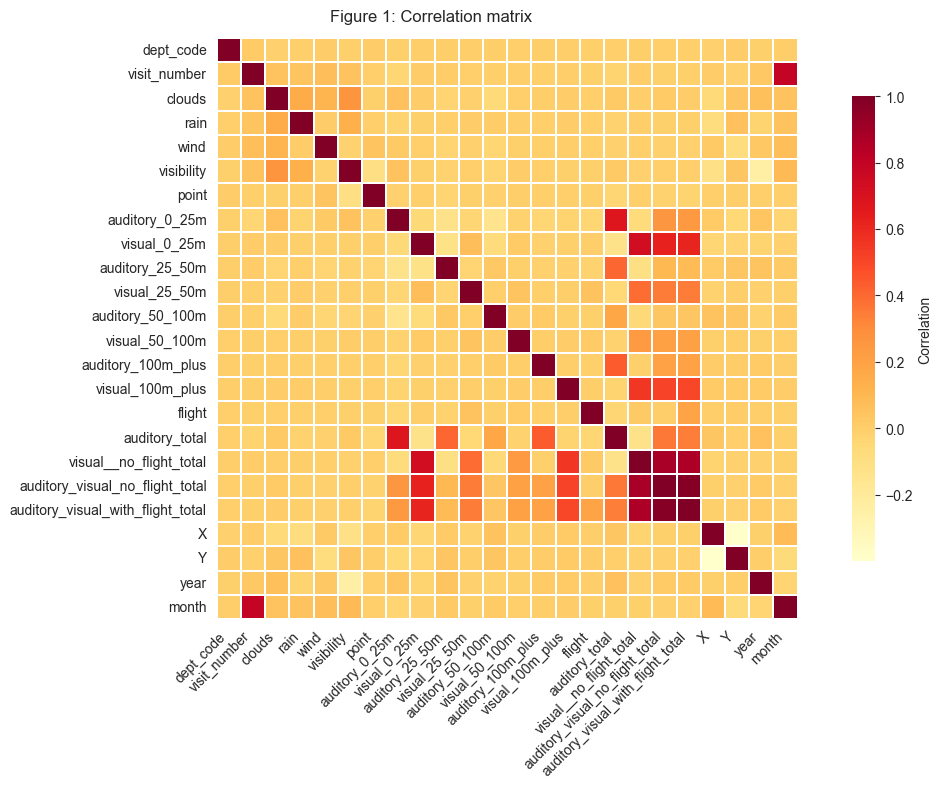

In [15]:
# Configuration graphiques
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Convertir date en datetime si nécessaire
df_full['date'] = pd.to_datetime(df_full['date'])
df_full['year'] = df_full['date'].dt.year
df_full['month'] = df_full['date'].dt.month

# Vue d'ensemble
print("="*60)
print("STRUCTURE DU DATASET")
print("="*60)
print(f"Dimensions : {df_full.shape[0]:,} observations × {df_full.shape[1]} colonnes")
print(f"Période : {df_full['date'].min().date()} to {df_full['date'].max().date()}")
print(f"Années : {df_full['year'].min()} - {df_full['year'].max()} ({df_full['year'].nunique()} années)")
print(f"\nIdentifiants uniques :")
print(f"  - Transects : {df_full['transect'].nunique()}")
print(f"  - Points d'écoute : {df_full['point'].nunique()}")
print(f"  - Observateurs : {df_full['observer'].nunique()}")
print(f"  - Espèces : {df_full['scientific_name'].nunique()}")
print(f"  - Habitats : {df_full['habitat'].nunique()}")
print(f"  - Départements : {df_full['dept_code'].nunique()}")
print("\n")

#=============== Correlation matrix to retrieve key columns ===============
# Select numerical columns
numerical_cols = df_full.select_dtypes(include=[np.number]).columns

# Calculate covariance matrix
corr_m = df_full[numerical_cols].corr()
# Visualize with diagonal highlighted
fig = plt.figure(figsize=(12, 8))
fig.suptitle(f"Figure {fig_counter()}: Correlation matrix")
sns.heatmap(corr_m, 
            annot=False,  # Remove numbers
            cmap='YlOrRd',
            square=True,
            linewidths=0.2,
            cbar_kws={"label": "Correlation", "shrink": 0.8})
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

## 1.2 Descriptive statics over relevant variables

### 1.2.1 Counts
In section below we are showing
- Distribution of key categorical variables (transects, habitats, species status)
- Coefficient of Variation (CV) analysis to assess information content across numerical columns

transect
morne babet                  2902
habitation petite rivière    2839
moulin à vent                2825
là-haut                      2380
hôtel des plaisirs           2372
autre bord                   2336
borelie                      2283
fond rousseau                2232
jeannot                      2211
o'mullane                    2208
Name: count, dtype: int64

habitat
Forêt sèche     26960
Agricole        26817
Périurbain      24718
Forêt humide    20433
Plage            5750
Mangrove         5481
Urbain           3929
Name: count, dtype: int64

status
Autochtone                        77261
Endémique des Petites Antilles    19958
Exogène colonisateur naturel      10426
Exogène introduit par l'homme      4533
Migrateur                           999
Marin                               478
Endémique de la Martinique          433
Name: count, dtype: int64

COEFFICIENT OF VARIATION - INFORMATION CONTENT ANALYSIS
                           Column         Mean          Std      

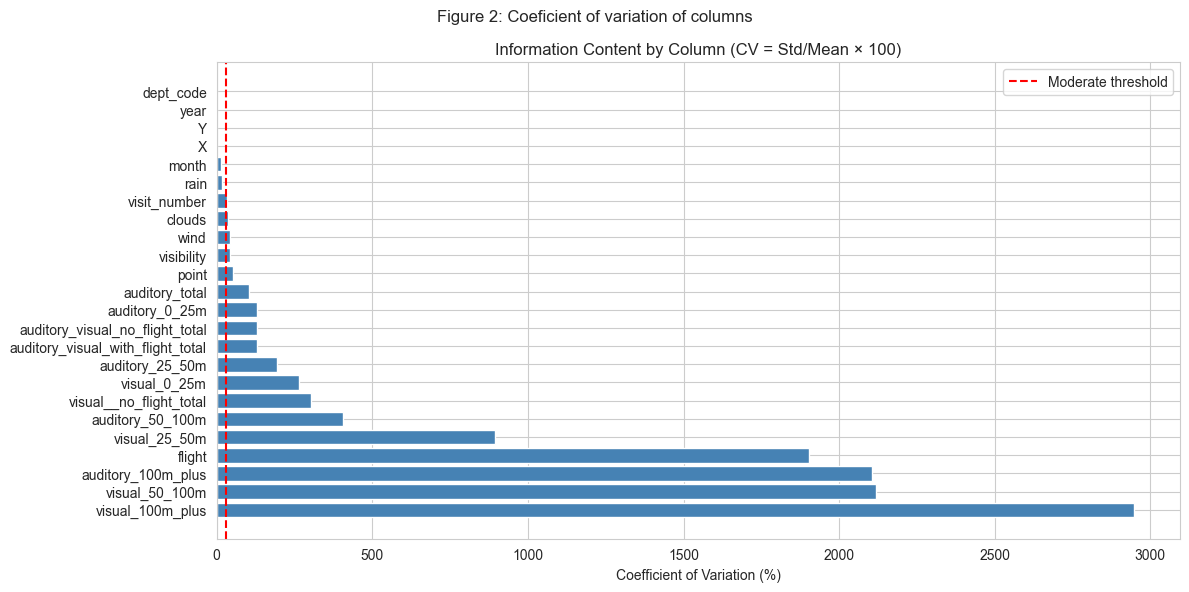

In [16]:
# Liste des éléments
print(df_full['transect'].value_counts().head(10), end="\n\n")
print(df_full['habitat'].value_counts(), end="\n\n")
print(df_full['status'].value_counts(), end="\n\n")



# Select numerical columns from your dataset
numerical_cols = df_full.select_dtypes(include=[np.number]).columns.tolist()

# Calculate Coefficient of Variation for each column
cv_results = []

for col in numerical_cols:
    data = df_full[col].dropna()  # Remove missing values
    
    if len(data) == 0:
        cv_results.append({
            'Column': col,
            'Mean': np.nan,
            'Std': np.nan,
            'CV': np.nan,
            'Non-missing': 0,
            'Info_Content': 'No data'
        })
        continue
    
    mean_val = data.mean()
    std_val = data.std()
    
    # Coefficient of Variation (handle division by zero)
    if mean_val != 0:
        cv = (std_val / abs(mean_val)) * 100  # As percentage
    else:
        cv = np.inf if std_val > 0 else 0
    
    # Categorize information content
    if cv == 0:
        info = 'No variation (constant)'
    elif cv < 10:
        info = 'Low variation'
    elif cv < 30:
        info = 'Moderate variation'
    elif cv < 100:
        info = 'High variation'
    else:
        info = 'Very high variation'
    
    cv_results.append({
        'Column': col,
        'Mean': mean_val,
        'Std': std_val,
        'CV (%)': cv,
        'Non-missing': len(data),
        'Info_Content': info
    })

# Create DataFrame
cv_df = pd.DataFrame(cv_results).sort_values('CV (%)', ascending=False)

print("=" * 80)
print("COEFFICIENT OF VARIATION - INFORMATION CONTENT ANALYSIS")
print("=" * 80)
print(cv_df.to_string(index=False))
print("\n")

# Visualize
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
fig.suptitle(f"Figure {fig_counter()}: Coeficient of variation of columns")
# CV by column
cv_df_clean = cv_df[cv_df['CV (%)'].notna() & np.isfinite(cv_df['CV (%)'])]
ax.barh(cv_df_clean['Column'], cv_df_clean['CV (%)'], color='steelblue')
ax.set_xlabel('Coefficient of Variation (%)')
ax.set_title('Information Content by Column (CV = Std/Mean × 100)')
ax.axvline(30, color='red', linestyle='--', label='Moderate threshold')
ax.legend()

plt.tight_layout()
plt.show()

#### Evolution of Bird Species Over Time

In the analysis below, we are plotting 2D curves for the evolution of each species of birds throughout time. The plots are ordered by the abundance of the species in question.

#### Results
The analysis shows that:
- Some species are keeping increasing
- Others are on the way to extinction
- Some are having non-regular evolution pace

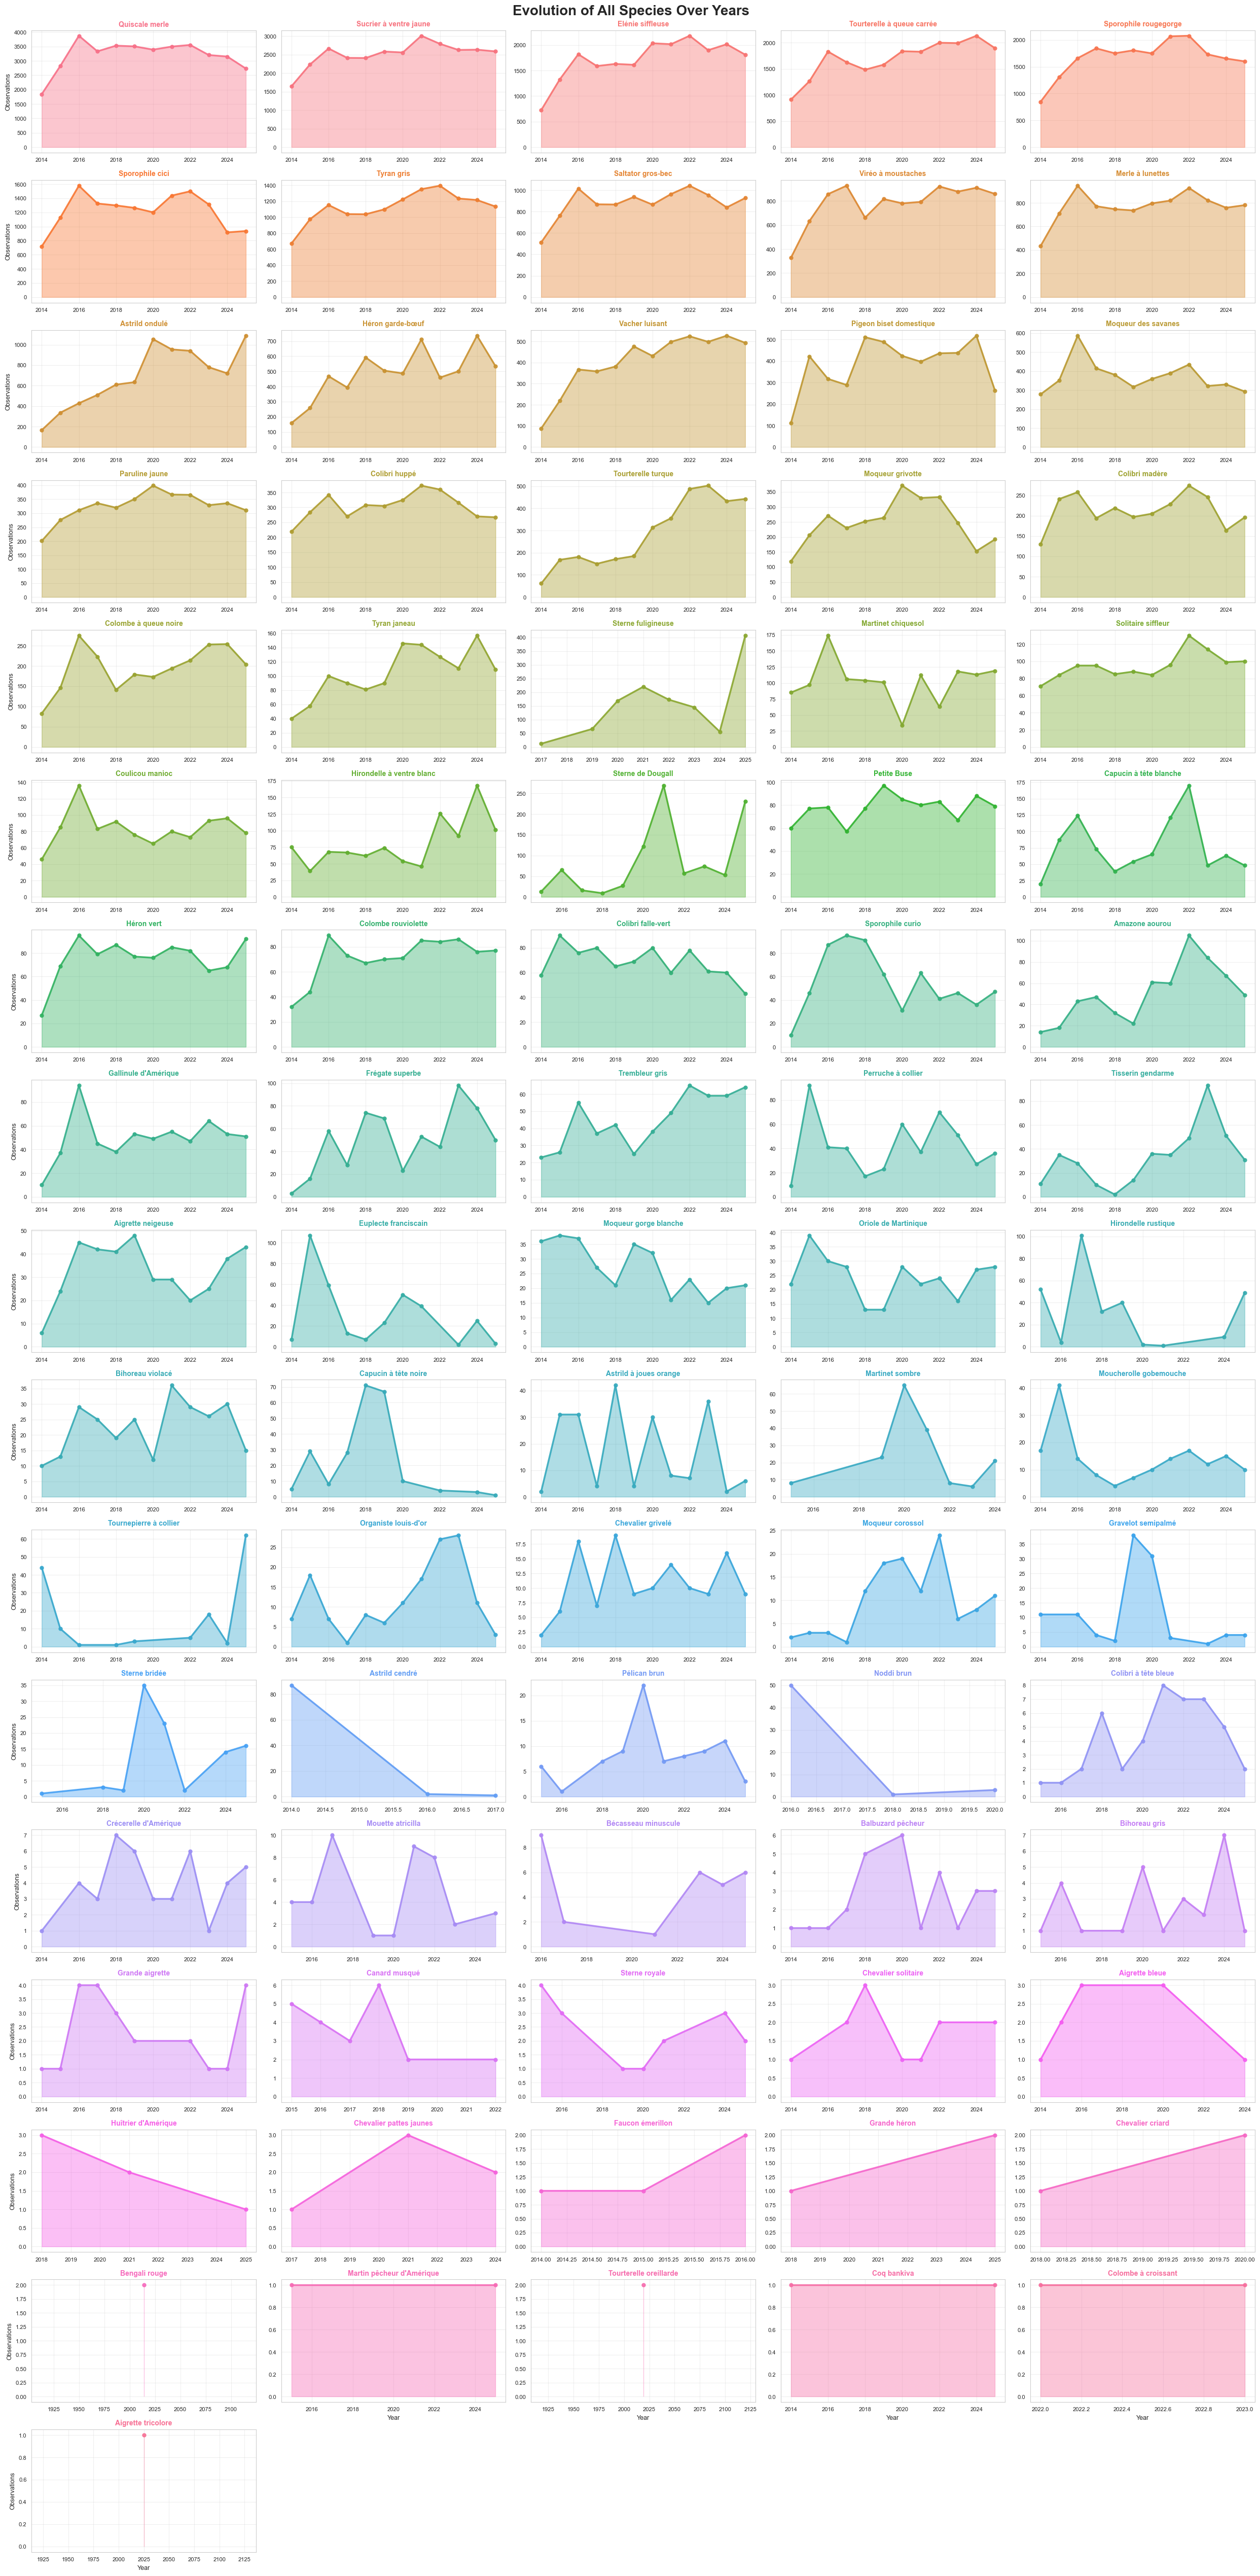

SUMMARY STATISTICS
Total Observations: 253,889
Unique Species: 81
Years Covered: 2014 - 2025
Total Transects: 65
Total Observation Points: 10

TOP 10 SPECIES
 1. Quiscale merle                               38,434 observations
 2. Sucrier à ventre jaune                       30,138 observations
 3. Elénie siffleuse                             20,655 observations
 4. Tourterelle à queue carrée                   20,387 observations
 5. Sporophile rougegorge                        20,103 observations
 6. Sporophile cici                              14,618 observations
 7. Tyran gris                                   13,523 observations
 8. Saltator gros-bec                            10,551 observations
 9. Viréo à moustaches                            9,372 observations
10. Merle à lunettes                              9,252 observations


In [17]:
# Convert date column to datetime if not already
df_full['date'] = pd.to_datetime(df_full['date'])
df_full['year'] = df_full['date'].dt.year

# Calculate total observations per species and sort
species_totals = df_full.groupby('species')['auditory_visual_with_flight_total'].sum().sort_values(ascending=False)
all_species_sorted = species_totals.index.tolist()
n_species = len(all_species_sorted)

# Create color palette
colors_dict = dict(zip(all_species_sorted, sns.color_palette("husl", n_colors=n_species)))

# Get all years
years = sorted(df_full['year'].unique())

# Calculate grid dimensions for subplots (try to make it roughly square)
n_cols = 5
n_rows = int(np.ceil(n_species / n_cols))

# Create figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, n_rows * 3))
axes = axes.flatten()

# Plot each species in its own subplot
for idx, species in enumerate(all_species_sorted):
    ax = axes[idx]
    species_data = df_full[df_full['species'] == species].groupby('year')['auditory_visual_with_flight_total'].sum()
    
    # Prepare data for this species
    x_vals = species_data.index.values
    y_vals = species_data.values
    
    # Plot the line
    ax.plot(x_vals, y_vals, color=colors_dict[species], linewidth=2.5, marker='o', markersize=5, alpha=0.9)
    
    # Fill under the curve
    ax.fill_between(x_vals, 0, y_vals, color=colors_dict[species], alpha=0.4)
    
    # Set title as species name
    ax.set_title(species, fontsize=10, fontweight='bold', color=colors_dict[species])
    
    # Add grid
    ax.grid(True, alpha=0.3)
    
    # Set labels for bottom row and left column only
    if idx >= n_species - n_cols:
        ax.set_xlabel('Year', fontsize=9)
    if idx % n_cols == 0:
        ax.set_ylabel('Observations', fontsize=9)
    
    # Adjust tick label size
    ax.tick_params(axis='both', labelsize=8)

# Hide empty subplots
for idx in range(n_species, len(axes)):
    axes[idx].axis('off')

# Add main title
fig.suptitle('Evolution of All Species Over Years', fontsize=20, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

# Print summary statistics
print("=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
print(f"Total Observations: {df_full['auditory_visual_with_flight_total'].sum():,.0f}")
print(f"Unique Species: {df_full['species'].nunique()}")
print(f"Years Covered: {df_full['year'].min()} - {df_full['year'].max()}")
print(f"Total Transects: {df_full['transect'].nunique()}")
print(f"Total Observation Points: {df_full['point'].nunique()}")

print("\n" + "=" * 60)
print("TOP 10 SPECIES")
print("=" * 60)
top_species = species_totals.nlargest(10)
for idx, (species, count) in enumerate(top_species.items(), 1):
    print(f"{idx:2d}. {species:40s} {count:>10,.0f} observations")

#### Species Distribution Across Habitats

We have constructed an **indicator of adaptability**, the more a species' distribution is uniform across habitats, the more adaptable it is. Therefore, we used the Chi-squared test's p-value as an indicator of adaptability.

Note that birds like **Bengal Rouge** are identified as having a uniform distribution, although all those birds live only in **agricultural** habitat. This can be explained by the fact that there are only two birds, therefore the distribution (2, 0, ..., 0) is uniform if we compare it to (2.0/7.0, ..., 2.0/7.0) where 7 is the count of habitats.

Additionally, we calculate the mode for each species, which shows the primary habitat (main home) of that particular species

#### **Results:** 
Assume that the distributions are unbiased.
- There are some species more adaptable than others, for example **Héron Garde-Boeuf** struggels to live outside the agricol habitats, contrarly to **Sucier à ventre jaune** which can live in multiple habitats.
- Urban habitats contain the least number of birds, therefore, showing the weakest biodiversity indicator(s), contrarly to humid forests and agricol habitats which show the highest biodiversity indicators, forming adequat habitats for birds.
- Although **urban** habitats show the weakest biodiversity indicators, some species such as the **pigeon biset domestique** prefer these environments due to abundant nesting sites and food availability that urban areas provide.

C:\Users\AMINE\AppData\Local\Temp\ipykernel_7476\226383939.py:78: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handles = [plt.Rectangle((0,0),1,1, color=colors_habitat[h], alpha=0.8, edgecolor='black', linewidth=0.5)


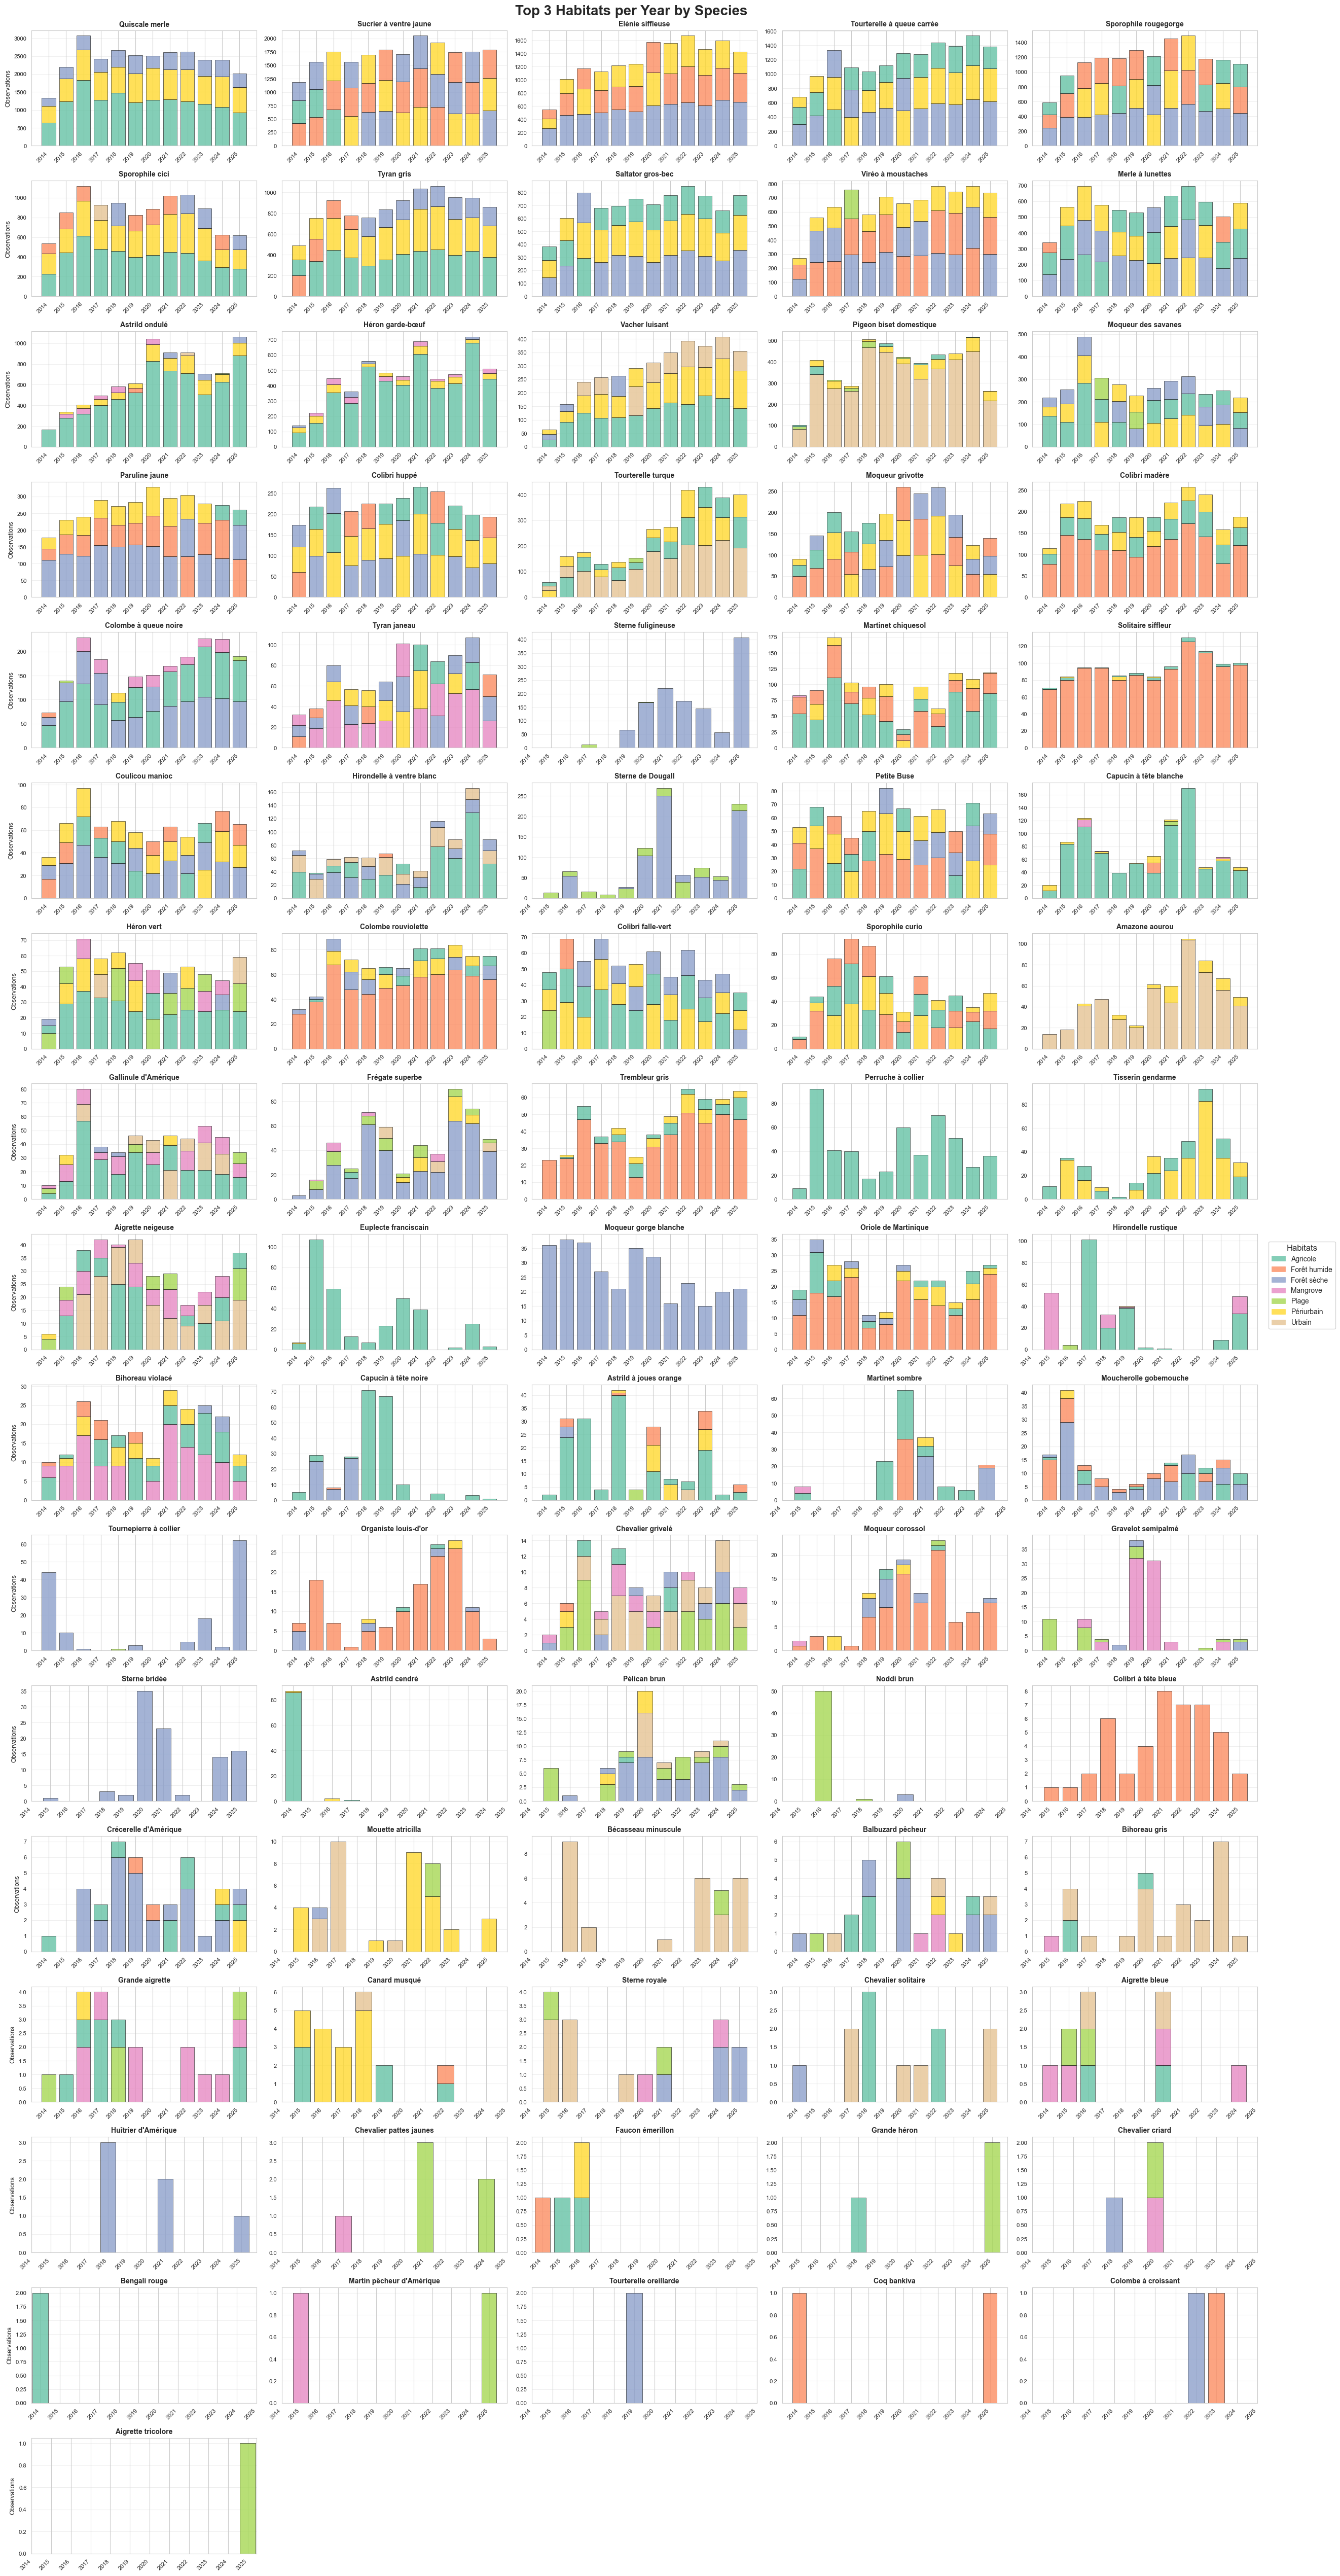

In [18]:
# Convert date column to datetime if not already
df_full['date'] = pd.to_datetime(df_full['date'])
df_full['year'] = df_full['date'].dt.year

# Calculate total observations per species and sort
species_totals = df_full.groupby('species')['auditory_visual_with_flight_total'].sum().sort_values(ascending=False)
all_species_sorted = species_totals.index.tolist()
n_species = len(all_species_sorted)

# Get unique habitats and years
habitats = sorted(df_full['habitat'].unique())
years = sorted(df_full['year'].unique())
n_habitats = len(habitats)

# Create color palette for habitats
colors_habitat = dict(zip(habitats, sns.color_palette("Set2", n_colors=n_habitats)))

# Calculate grid dimensions for subplots
n_cols = 5
n_rows = int(np.ceil(n_species / n_cols))

# Create figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, n_rows * 3))
axes = axes.flatten()

# Plot each species in its own subplot
for idx, species in enumerate(all_species_sorted):
    ax = axes[idx]
    
    # Get data for this species
    species_data = df_full[df_full['species'] == species]
    
    # Group by year and habitat
    year_habitat_data = species_data.groupby(['year', 'habitat'])['auditory_visual_with_flight_total'].sum().reset_index()
    
    # For each year, get top 3 habitats
    bottom = np.zeros(len(years))
    
    for year in years:
        year_data = year_habitat_data[year_habitat_data['year'] == year]
        # Get top 3 habitats for this year
        top_3 = year_data.nlargest(3, 'auditory_visual_with_flight_total')
        
        year_idx = years.index(year)
        
        for _, row in top_3.iterrows():
            habitat = row['habitat']
            value = row['auditory_visual_with_flight_total']
            
            ax.bar(year_idx, value, bottom=bottom[year_idx], 
                   color=colors_habitat[habitat], alpha=0.8, 
                   edgecolor='black', linewidth=0.5, width=0.8)
            
            bottom[year_idx] += value
    
    # Set title as species name
    ax.set_title(species, fontsize=10, fontweight='bold')
    
    # Add grid
    ax.grid(True, alpha=0.3, axis='y')
    
    # Set x-axis labels
    ax.set_xticks(range(len(years)))
    ax.set_xticklabels(years, rotation=45, ha='right', fontsize=7)
    
    # Set labels for left column only
    if idx % n_cols == 0:
        ax.set_ylabel('Observations', fontsize=9)
    
    # Adjust tick label size
    ax.tick_params(axis='both', labelsize=8)

# Hide empty subplots
for idx in range(n_species, len(axes)):
    axes[idx].axis('off')

# Create legend
handles = [plt.Rectangle((0,0),1,1, color=colors_habitat[h], alpha=0.8, edgecolor='black', linewidth=0.5) 
           for h in habitats]
fig.legend(handles, habitats, loc='center left', bbox_to_anchor=(1, 0.5), 
           fontsize=10, title='Habitats', title_fontsize=12)

# Add main title
fig.suptitle('Top 3 Habitats per Year by Species', fontsize=20, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

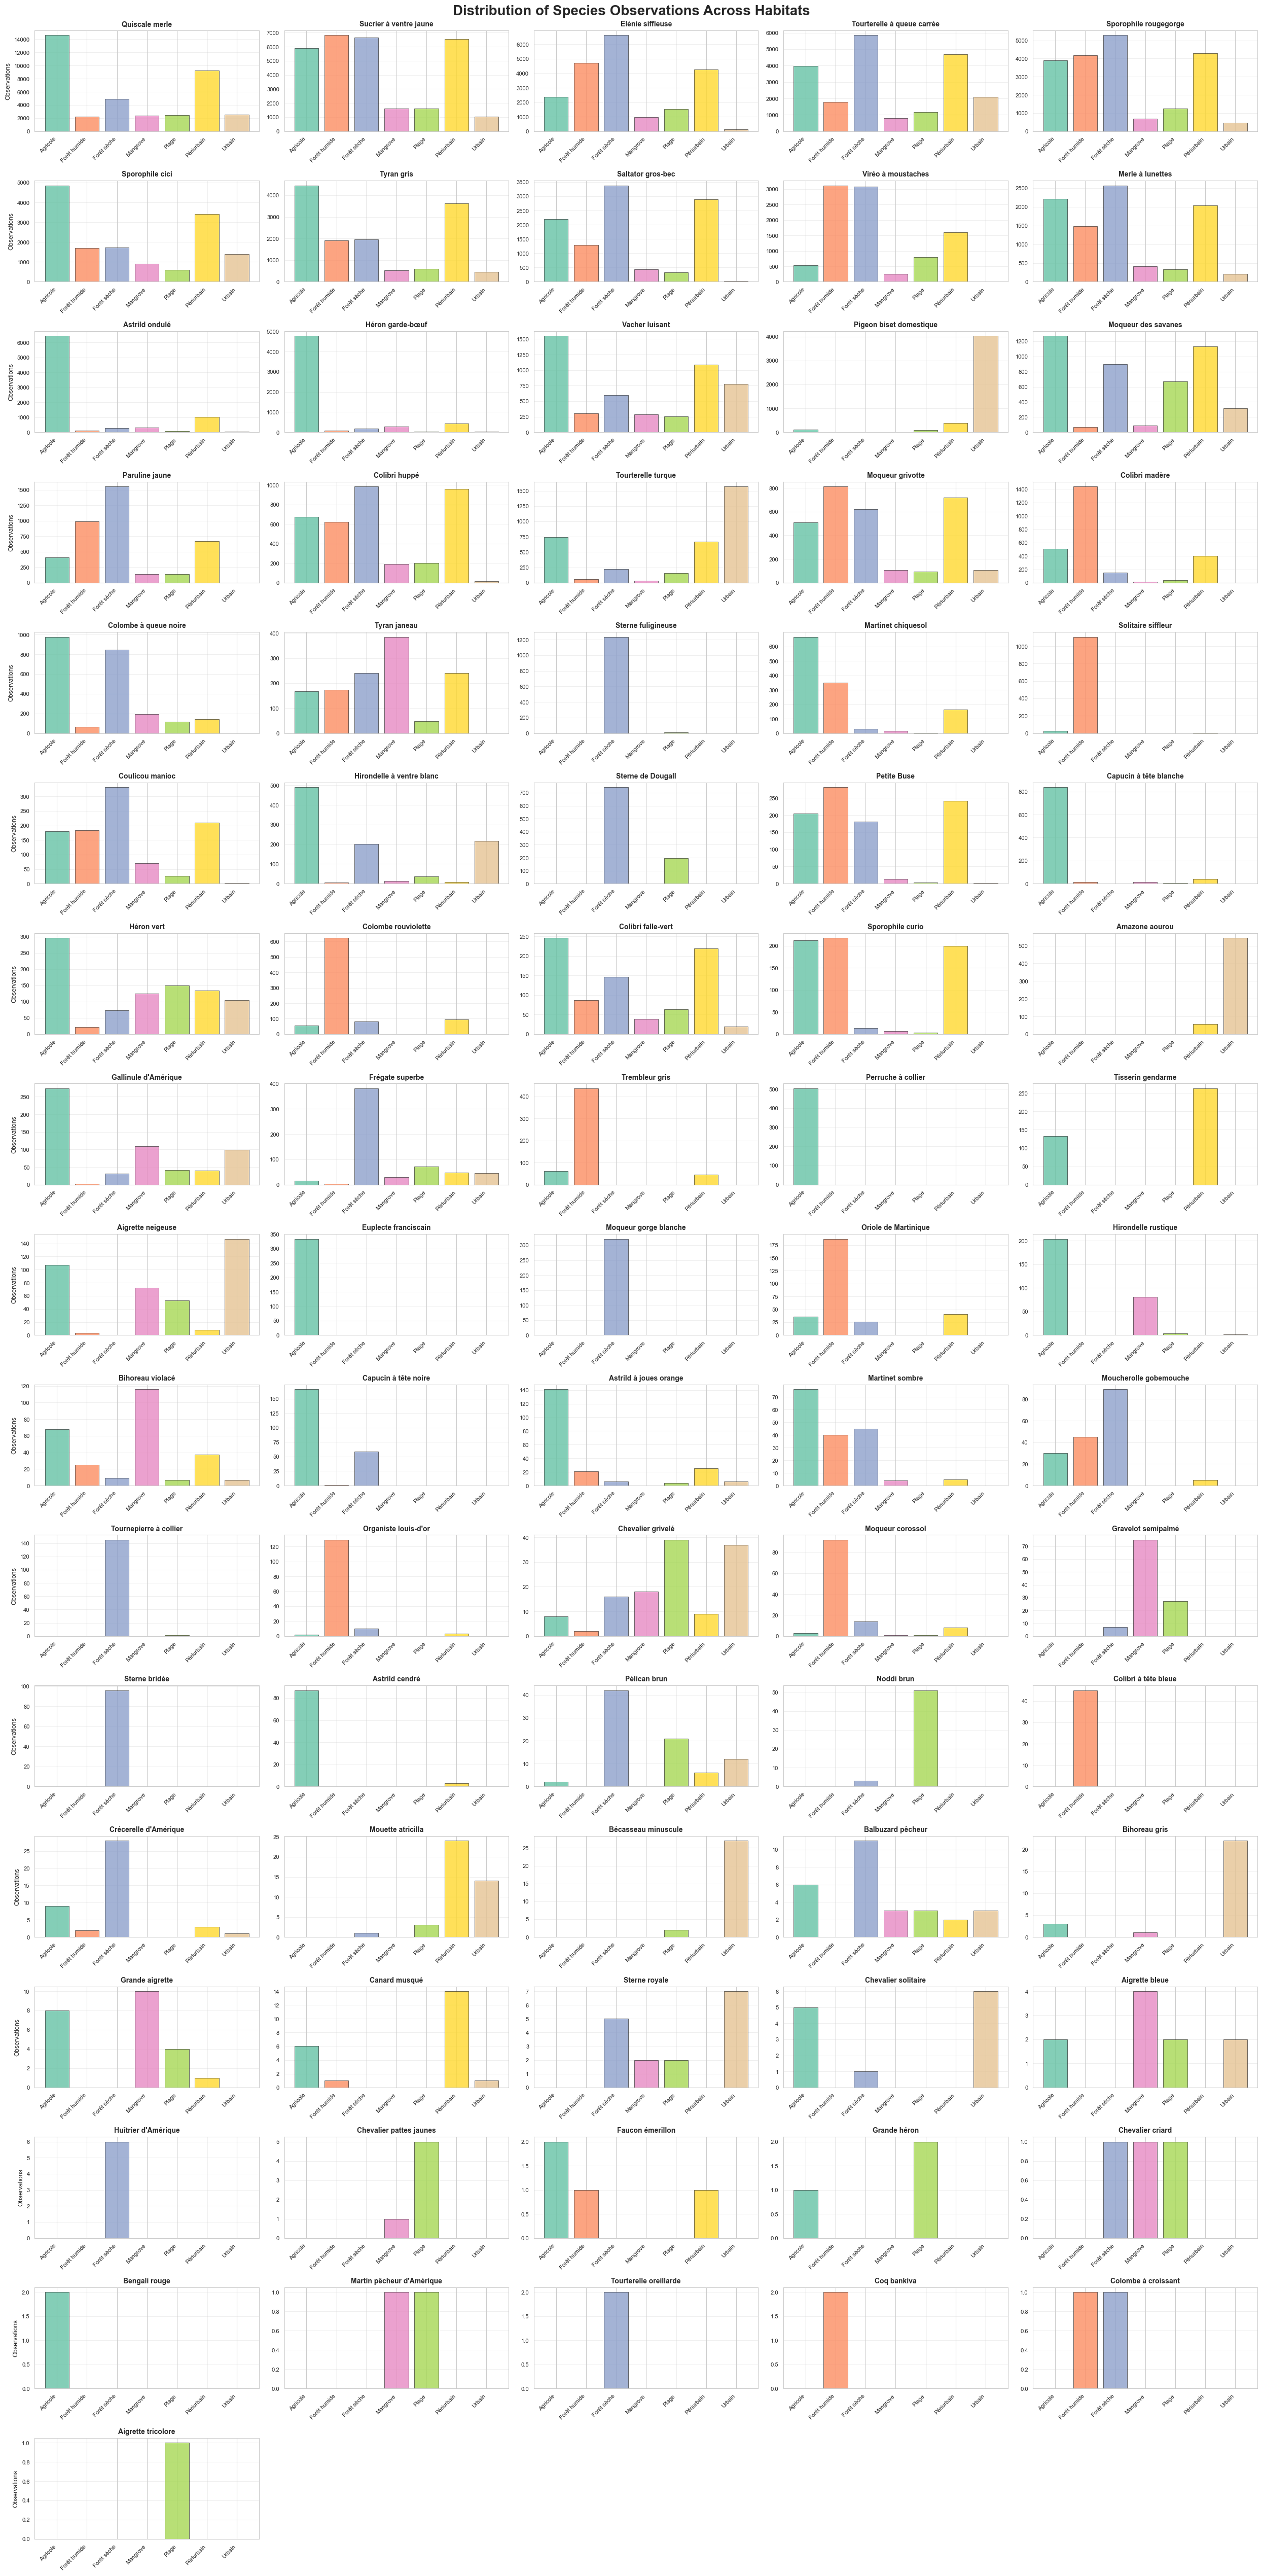

NameError: name 'habitat_year' is not defined

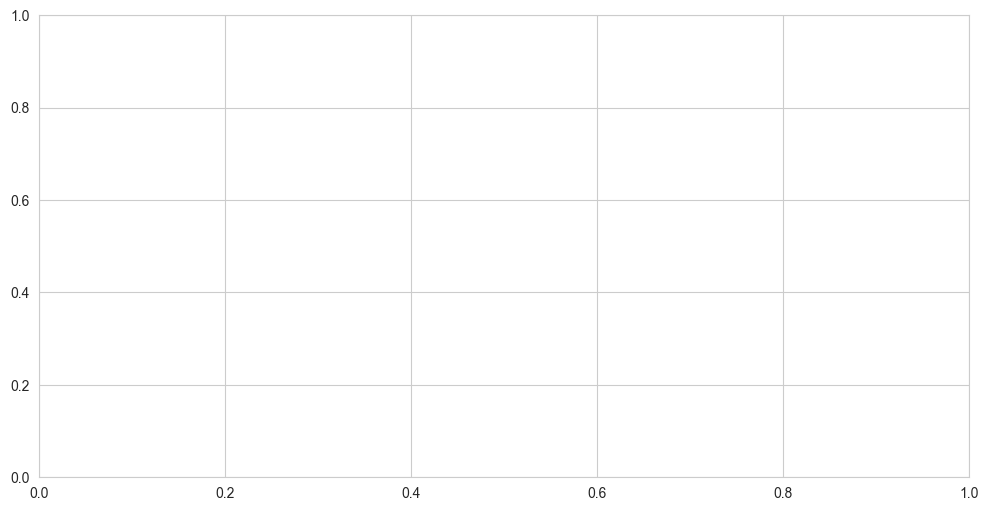

In [19]:
# Convert date column to datetime if not already
df_full['date'] = pd.to_datetime(df_full['date'])
df_full['year'] = df_full['date'].dt.year

# Calculate total observations per species and sort
species_totals = df_full.groupby('species')['auditory_visual_with_flight_total'].sum().sort_values(ascending=False)
all_species_sorted = species_totals.index.tolist()
n_species = len(all_species_sorted)

# Get unique habitats
habitats = sorted(df_full['habitat'].unique())
n_habitats = len(habitats)

# Create color palette for habitats
colors_habitat = dict(zip(habitats, sns.color_palette("Set2", n_colors=n_habitats)))

# Calculate grid dimensions for subplots
n_cols = 5
n_rows = int(np.ceil(n_species / n_cols))

# Create figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, n_rows * 3))
axes = axes.flatten()

# Plot each species in its own subplot
for idx, species in enumerate(all_species_sorted):
    ax = axes[idx]
    
    # Get data for this species grouped by habitat
    species_habitat_data = df_full[df_full['species'] == species].groupby('habitat')['auditory_visual_with_flight_total'].sum()
    
    # Prepare data for bar plot
    x_positions = range(len(habitats))
    y_values = [species_habitat_data.get(habitat, 0) for habitat in habitats]
    bar_colors = [colors_habitat[habitat] for habitat in habitats]
    
    # Create bar plot
    ax.bar(x_positions, y_values, color=bar_colors, alpha=0.8, edgecolor='black', linewidth=0.5)
    
    # Set title as species name
    ax.set_title(species, fontsize=10, fontweight='bold')
    
    # Add grid
    ax.grid(True, alpha=0.3, axis='y')
    
    # Set x-axis labels
    ax.set_xticks(x_positions)
    ax.set_xticklabels(habitats, rotation=45, ha='right', fontsize=7)
    
    # Set labels for left column only
    if idx % n_cols == 0:
        ax.set_ylabel('Observations', fontsize=9)
    
    # Adjust tick label size
    ax.tick_params(axis='both', labelsize=8)

# Hide empty subplots
for idx in range(n_species, len(axes)):
    axes[idx].axis('off')

# Add main title
fig.suptitle('Distribution of Species Observations Across Habitats', fontsize=20, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


# Stracked nb of observations per habitat
fig, ax = plt.subplots(figsize=(12, 6))

# Stacked area chart
pivot_habitat = habitat_year.pivot(index='year', columns='habitat', values='auditory_visual_with_flight_total').fillna(0)
ax.stackplot(pivot_habitat.index, 
             *[pivot_habitat[col] for col in pivot_habitat.columns],
             labels=pivot_habitat.columns,
             colors=[colors_habitat[h] for h in pivot_habitat.columns],
             alpha=0.8)

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Abundance', fontsize=12, fontweight='bold')
ax.set_title('Cumulative Abundance by Habitat', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============= UNIFORMITY TEST =============
print("\n" + "=" * 120)
print("UNIFORMITY TEST OF HABITAT DISTRIBUTION BY SPECIES")
print("=" * 120)

from scipy.stats import chisquare

stats_data = []

for species in all_species_sorted:
    # Get observations by habitat for this species
    species_habitat_data = df_full[df_full['species'] == species].groupby('habitat')['auditory_visual_with_flight_total'].sum()
    
    # Get raw habitat values
    observed = np.array([species_habitat_data.get(habitat, 0) for habitat in habitats])
    total_obs = observed.sum()
    
    # Chi-square test: compare with uniform expected distribution
    expected_counts = np.full(len(habitats), total_obs / len(habitats))
    
    # Perform chi-square test
    chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected_counts)
    
    # Find mode (habitat with maximum observations)
    mode_habitat = habitats[np.argmax(observed)]
    mode_percentage = (np.max(observed) / total_obs) * 100 if total_obs > 0 else 0
    
    # Determine if distribution is uniform (p > 0.05)
    is_uniform = "Yes" if p_value > 0.05 else "No"

    # Store results
    stats_data.append({
        'Species': species,
        'Total_Obs': int(total_obs),
        'Chi2_Stat': chi2_stat,
        'p_value': p_value,
        'Uniform': is_uniform,
        'Mode_Habitat': mode_habitat,
        'Mode_%': mode_percentage
    })

# Convert to DataFrame
stats_df = pd.DataFrame(stats_data)
stats_df = stats_df.sort_values('p_value', ascending=True)  # Sort by p-value (most non-uniform first)

# Format output
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_columns', None)

print("\n" + "-" * 120)
print(f"{'Species':<35} {'Total_Obs':>10} {'Chi2_Stat':>12} {'p_value':>12} {'Uniform':>8} {'Mode_Habitat':<15} {'Mode_%':>10}")
print("-" * 120)

for _, row in stats_df.iterrows():
    print(f"{row['Species']:<35} {row['Total_Obs']:>10} {row['Chi2_Stat']:>12.4f} {row['p_value']:>12.4f} {row['Uniform']:>8} {row['Mode_Habitat']:<15} {row['Mode_%']:>10.2f}")

print("-" * 120)
print(f"\nTotal species analyzed: {len(stats_df)}")
print(f"Species with uniform distribution (p > 0.05): {(stats_df['p_value'] > 0.05).sum()}")
print(f"Species with non-uniform distribution (p ≤ 0.05): {(stats_df['p_value'] <= 0.05).sum()}")
print("=" * 120)

#### Species detection across habitats.
The plot below shows the evolution of birds of all species across different habitats over time, in addition to the method of recognition and its relation to the abundance of birds.

#### Results
The analysis reveals:


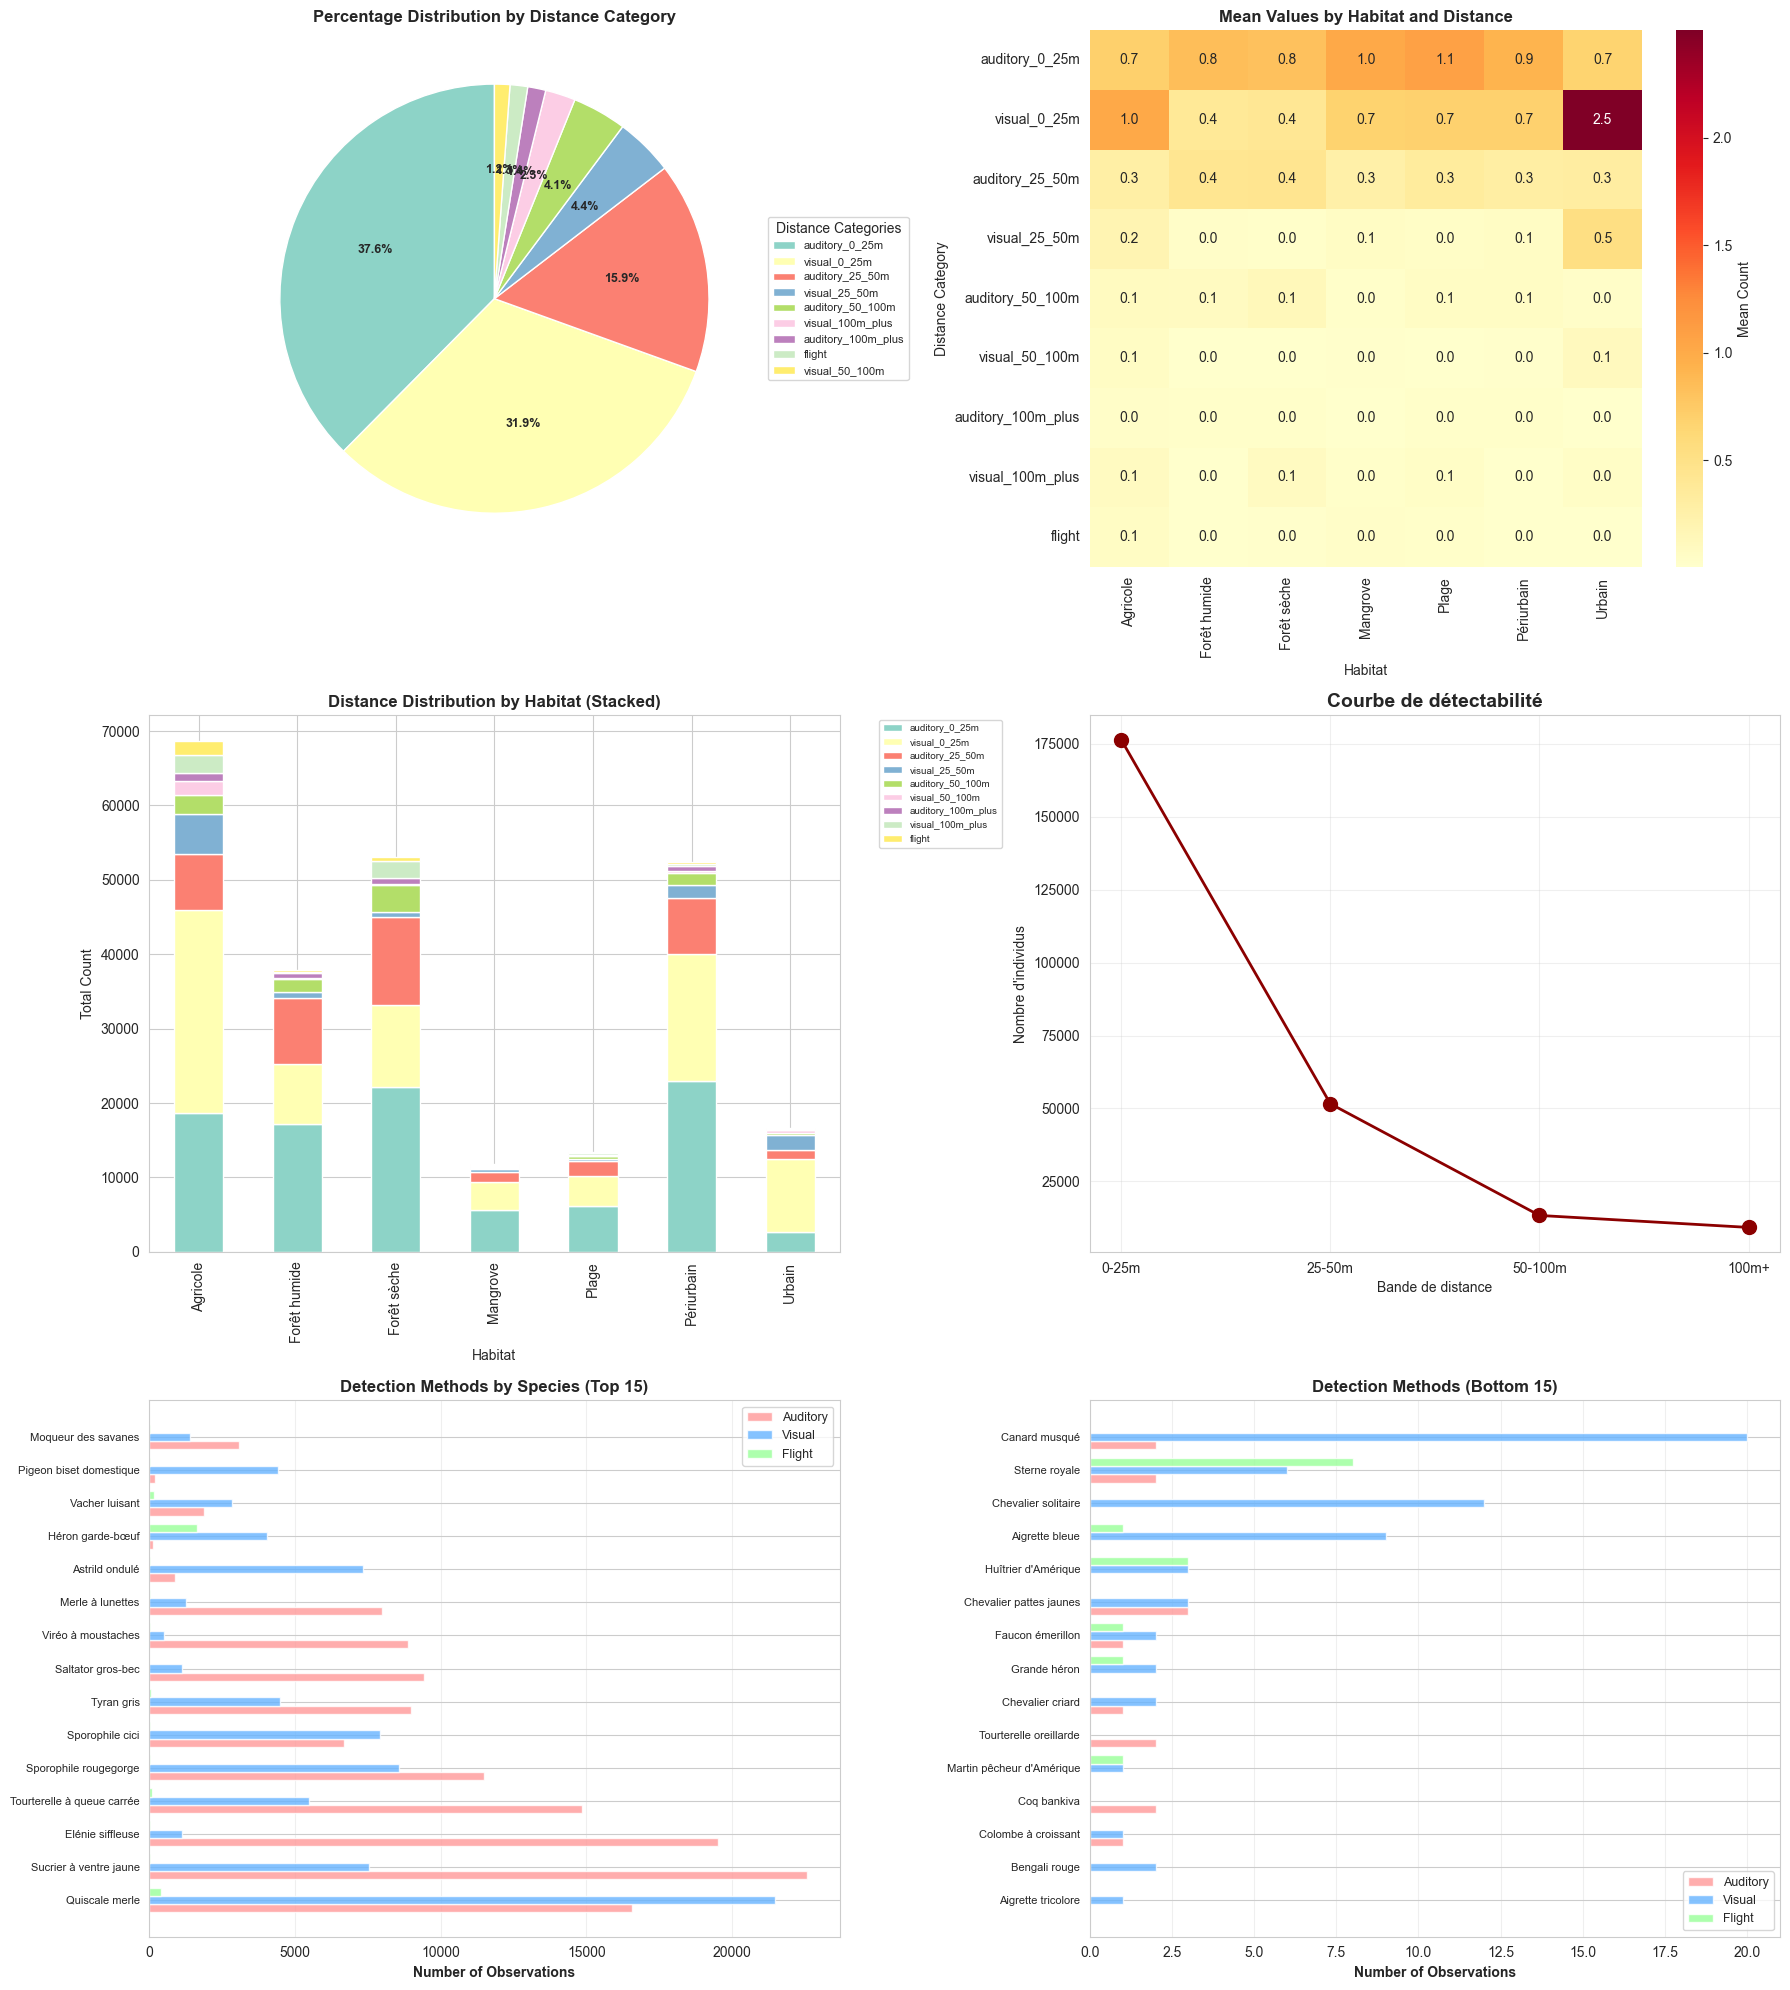

In [ ]:
# Set style
sns.set_style("whitegrid")

# List of distance detection categories
distance_vars = [
    'auditory_0_25m',       
    'visual_0_25m',        
    'auditory_25_50m',       
    'visual_25_50m',   
    'auditory_50_100m', 
    'visual_50_100m',     
    'auditory_100m_plus', 
    'visual_100m_plus',  
    'flight'
]

# Check which variables exist
available_distance_vars = [var for var in distance_vars if var in df_full.columns]

# Get total counts for later use
total_counts = df_full[available_distance_vars].sum().sort_values(ascending=False)

# Convert date column to datetime if not already
df_full['date'] = pd.to_datetime(df_full['date'])
df_full['year'] = df_full['date'].dt.year

# Calculate observations by habitat and year
habitat_year = df_full.groupby(['habitat', 'year'])['auditory_visual_with_flight_total'].sum().reset_index()

# Get unique habitats
habitats = sorted(df_full['habitat'].unique())
n_habitats = len(habitats)

# Create color palette for habitats
colors_habitat = dict(zip(habitats, sns.color_palette("Set2", n_colors=n_habitats)))

# Create combined figure with 4x2 layout
fig, axes = plt.subplots(3, 2, figsize=(18, 20))

# === ROW 1: Distance analysis ===
# Plot [0,0]: Percentage distribution - Pie chart
total_obs = total_counts.sum()
percentages = (total_counts / total_obs * 100)
colors = plt.cm.Set3(np.linspace(0, 1, len(percentages)))
wedges, texts, autotexts = axes[0, 0].pie(
    percentages.values, 
    autopct='%1.1f%%', 
    startangle=90,
    colors=colors,
    textprops={'fontsize': 9, 'weight': 'bold'}
)
axes[0, 0].legend(
    wedges, 
    percentages.index,
    title="Distance Categories",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=8
)
axes[0, 0].set_title('Percentage Distribution by Distance Category', fontsize=12, fontweight='bold')

# Plot [0,1]: Heatmap of means by habitat
habitat_means = df_full.groupby('habitat')[available_distance_vars].mean()
sns.heatmap(habitat_means.T, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0, 1], 
            cbar_kws={'label': 'Mean Count'})
axes[0, 1].set_title('Mean Values by Habitat and Distance', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Distance Category')
axes[0, 1].set_xlabel('Habitat')

# === ROW 2: Habitat evolution ===
# Plot [1,0]: Stacked bar chart - counts by habitat
habitat_sums = df_full.groupby('habitat')[available_distance_vars].sum()
habitat_sums.plot(kind='bar', stacked=True, ax=axes[1, 0], color=colors)
axes[1, 0].set_ylabel('Total Count')
axes[1, 0].set_title('Distance Distribution by Habitat (Stacked)', fontsize=12, fontweight='bold')
axes[1, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
axes[1, 0].set_xlabel('Habitat')

# ============= DÉTECTABILITÉ PAR DISTANCE =============
distance_bands = {
    '0-25m': df_full['auditory_0_25m'].sum() + df_full['visual_0_25m'].sum(),
    '25-50m': df_full['auditory_25_50m'].sum() + df_full['visual_25_50m'].sum(),
    '50-100m': df_full['auditory_50_100m'].sum() + df_full['visual_50_100m'].sum(),
    '100m+': df_full['auditory_100m_plus'].sum() + df_full['visual_100m_plus'].sum()
}

distance_df = pd.DataFrame(list(distance_bands.items()), columns=['Distance', 'Count'])
distance_df['Percentage'] = (distance_df['Count'] / distance_df['Count'].sum() * 100).round(2)
axes[1, 1].plot(range(len(distance_df)), distance_df['Count'], marker='o', linewidth=2, markersize=10, color='darkred')
axes[1, 1].set_title('Courbe de détectabilité', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Bande de distance')
axes[1, 1].set_ylabel('Nombre d\'individus')
axes[1, 1].set_xticks(range(len(distance_df)))
axes[1, 1].set_xticklabels(distance_df['Distance'])
axes[1, 1].grid(alpha=0.3)

# Plot [2,1]: Top 15 species detection methods
detection_by_species = df_full.groupby('species').agg({
    'auditory_total': 'sum',
    'visual__no_flight_total': 'sum',
    'flight': 'sum'
}).fillna(0)
top_species = df_full.groupby('species')['auditory_visual_with_flight_total'].sum().nlargest(15).index
detection_top = detection_by_species.loc[top_species]
x = np.arange(len(detection_top))
width = 0.25
axes[2, 0].barh(x - width, detection_top['auditory_total'], width, label='Auditory', color='#ff9999', alpha=0.8)
axes[2, 0].barh(x, detection_top['visual__no_flight_total'], width, label='Visual', color='#66b3ff', alpha=0.8)
axes[2, 0].barh(x + width, detection_top['flight'], width, label='Flight', color='#99ff99', alpha=0.8)
axes[2, 0].set_yticks(x)
axes[2, 0].set_yticklabels(detection_top.index, fontsize=8)
axes[2, 0].set_xlabel('Number of Observations', fontsize=10, fontweight='bold')
axes[2, 0].set_title('Detection Methods by Species (Top 15)', fontsize=12, fontweight='bold')
axes[2, 0].legend(fontsize=9)
axes[2, 0].grid(True, alpha=0.3, axis='x')

# === ROW 4 ===
# Plot [3,0]: Bottom 15 species detection methods
bottom_species = df_full.groupby('species')['auditory_visual_with_flight_total'].sum().nsmallest(15).index
detection_bottom = detection_by_species.loc[bottom_species]
x = np.arange(len(detection_bottom))
axes[2, 1].barh(x - width, detection_bottom['auditory_total'], width, label='Auditory', color='#ff9999', alpha=0.8)
axes[2, 1].barh(x, detection_bottom['visual__no_flight_total'], width, label='Visual', color='#66b3ff', alpha=0.8)
axes[2, 1].barh(x + width, detection_bottom['flight'], width, label='Flight', color='#99ff99', alpha=0.8)
axes[2, 1].set_yticks(x)
axes[2, 1].set_yticklabels(detection_bottom.index, fontsize=8)
axes[2, 1].set_xlabel('Number of Observations', fontsize=10, fontweight='bold')
axes[2, 1].set_title('Detection Methods (Bottom 15)', fontsize=12, fontweight='bold')
axes[2, 1].legend(fontsize=9)
axes[2, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('combined_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

### 1.2.2 Observer efforts

- Transects are ordered in lexicographic order of their X, Y coordinates, by this, we will be able to see how the observations are distributed geographically.

**Results:** 
- There is a huge bias in observations across habitats due to geographical and human factor (people collect data in the geographically easy habitats what creates an unequal ditribution of observers across habitats what leads to bias in distribution of birds across habitats).
- Graphic [1,1] shows that the number of observers dropped sharply in late 2020 due to the **COVID-19 pandemic**, but the number of treated transects remained constant, therefore, a decrease in number of observations per transect, in consequence, a high variability due to lack of data and high bias due to lack of observators.
- The transect **Bois patheau** had almost no observations between **2014** and **2016**, contrarywise to the **Habitation petite rivière** transect had many observations throughout the years.
- Graphic [2,0] shows high variance in the ```observers/observations``` ratio across transects, indicating that observer numbers vary significantly between locations. This non-homogeneous sampling effort may introduce bias into the study.

NameError: name 'effort_annual' is not defined

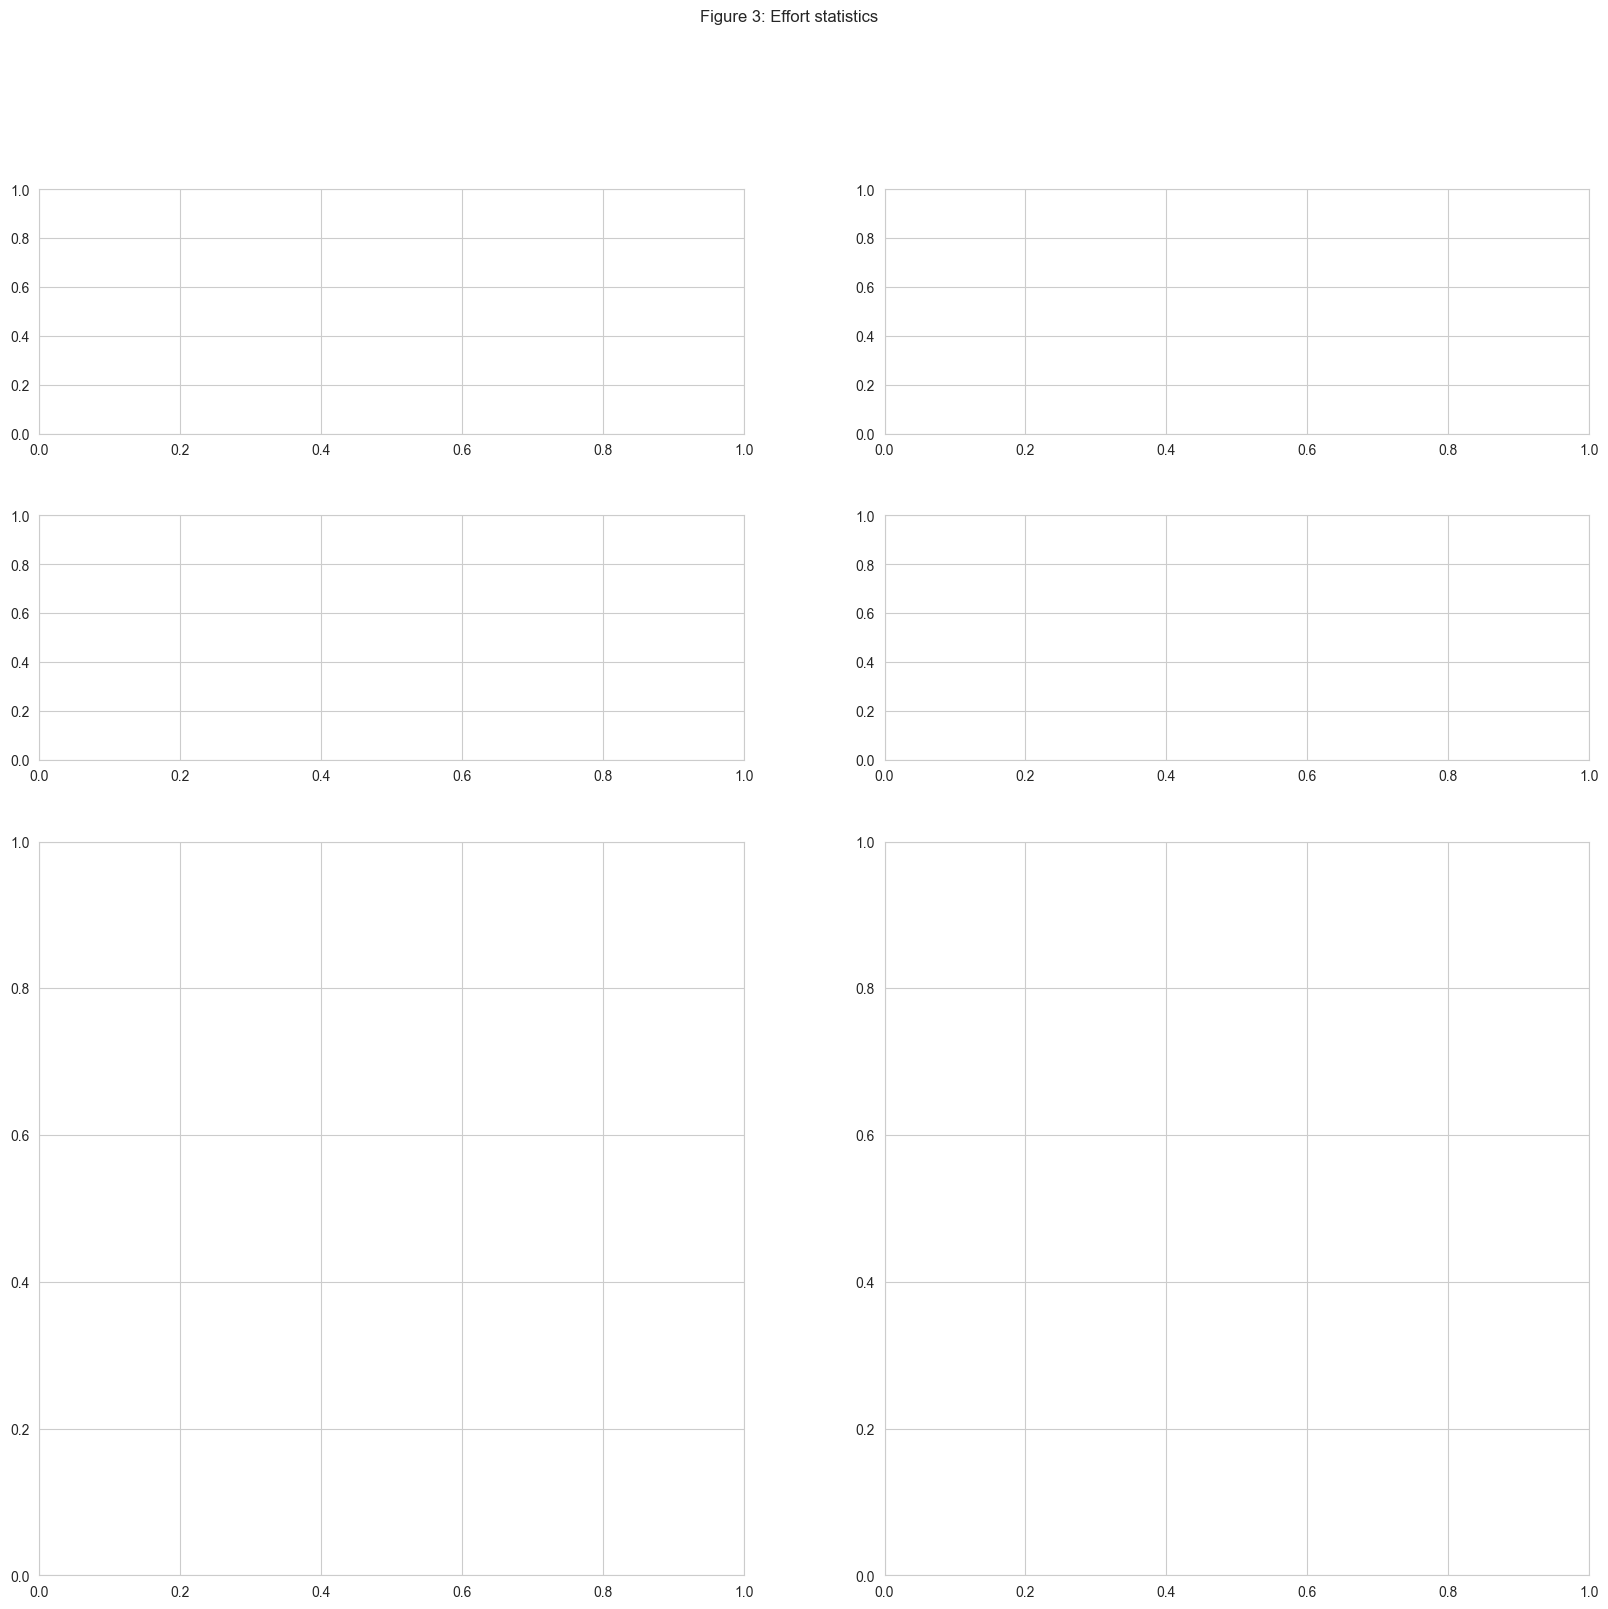

In [ ]:
# ============= SAISONNALITÉ =============
effort_monthly = df_full.groupby(['year', 'month']).size().reset_index(name='nb_obs')

# ============= VISUALISATIONS EFFORT =============
fig = plt.figure(figsize=(20, 18))

counter1 = fig_counter()
fig.suptitle(f"Figure {counter1}: Effort statistics")

gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 3])  # Ligne 3 deux fois plus grande

ax00 = fig.add_subplot(gs[0, 0])
ax01 = fig.add_subplot(gs[0, 1])
ax10 = fig.add_subplot(gs[1, 0])
ax11 = fig.add_subplot(gs[1, 1])
ax20 = fig.add_subplot(gs[2, 0])
ax21 = fig.add_subplot(gs[2, 1])

# Évolution annuelle
effort_annual['points_visits'].plot(kind='bar', ax=ax00, color='steelblue')
ax00.set_title('Effort de monitoring (points-visites) par année', fontsize=14, fontweight='bold')
ax00.set_xlabel('Année')
ax00.set_ylabel('Nombre de points-visites')
ax00.grid(axis='y', alpha=0.3)

# Heatmap transects X années
transect_coords = df_full.groupby('transect').agg({
    'X': 'first',
    'Y': 'first'
}).reset_index()
transect_coords = transect_coords.sort_values(['X', 'Y'])
transect_order = transect_coords['transect'].tolist()

pivot_transect = df_full.groupby(['transect', 'year']).size().reset_index(name='count')
pivot_transect = pivot_transect.pivot(index='transect', columns='year', values='count').fillna(0)
pivot_transect = pivot_transect.reindex(transect_order)

sns.heatmap(pivot_transect, cmap='YlOrRd', ax=ax21, cbar_kws={'label': 'Nb observations'})
ax21.set_yticks(range(len(pivot_transect)))
ax21.set_yticklabels(pivot_transect.index, rotation=0, fontsize=8)
ax21.set_xticklabels(ax21.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax21.set_title('Effort par transect et année', fontsize=14, fontweight='bold')

# Saisonnalité
monthly_avg = effort_monthly.groupby('month')['nb_obs'].mean()
ax10.bar(monthly_avg.index, monthly_avg.values, color='coral')
ax10.set_title('Saisonnalité des relevés (moyenne mensuelle)', fontsize=14, fontweight='bold')
ax10.set_xlabel('Mois')
ax10.set_ylabel('Nombre moyen d\'observations')
ax10.set_xticks(range(1, 13))
ax10.grid(axis='y', alpha=0.3)

# Évolution nb observateurs et transects
effort_annual['nb_observers'].plot(ax=ax11, marker='o', label='Observateurs', color='green')
ax11.set_ylabel('Nb observateurs', color='green')
ax11.tick_params(axis='y', labelcolor='green')

ax11_twin = ax11.twinx()
effort_annual['nb_transects'].plot(ax=ax11_twin, marker='s', label='Transects', color='purple')
ax11_twin.set_ylabel('Nb transects', color='purple')
ax11_twin.tick_params(axis='y', labelcolor='purple')

ax11.set_title('Évolution observateurs et transects', fontsize=14, fontweight='bold')
ax11.set_xlabel('Année')

# Effort par transect
effort_sorted = effort_transect.sort_values('nb_obs', ascending=True)
x = np.arange(len(effort_sorted))
width = 0.2

ax20.barh(x - 0.5*width, effort_sorted['nb_observers']/effort_sorted['nb_obs'] * 200, width, label='Observateurs / Observations * (200)', color='steelblue')
#ax20.barh(x + 0.5*width, effort_sorted['nb_observers'], width, label='Observateurs', color='mediumpurple')

ax20.set_yticks(x)
ax20.set_yticklabels(effort_sorted.index, fontsize=8)
ax20.set_xlabel('Nombre', fontsize=12, fontweight='bold')
ax20.set_ylabel('Transect', fontsize=12, fontweight='bold')
ax20.set_title('Effort d\'échantillonnage par transect', fontsize=14, fontweight='bold')
ax20.legend(loc='lower right', fontsize=10)
ax20.grid(axis='x', alpha=0.3)

# Heatmap habitat X années
pivot_habitat = df_full.groupby(['habitat', 'year']).size().reset_index(name='count')
pivot_habitat = pivot_habitat.pivot(index='habitat', columns='year', values='count').fillna(0)

sns.heatmap(pivot_habitat, cmap='YlOrRd', ax=ax01, cbar_kws={'label': 'Nb observations'}, annot=True, fmt='g')
ax01.set_title('Effort par habitat et année', fontsize=14, fontweight='bold')
ax01.set_xlabel('Année', fontsize=12)
ax01.set_ylabel('Habitat', fontsize=12)

plt.tight_layout()
plt.show()

print("\n" + "=" * 120)
print(f"SAMPLING EFFORT STATISTICS")
print("=" * 120)

# 1. Annual effort
print("\n--- ANNUAL EFFORT ---")
print(effort_annual.to_string(index=True, float_format=lambda x: f'{x:.0f}'))

# 2. Effort by transect
print("\n" + "-" * 120)
print("--- EFFORT BY TRANSECT (sorted by number of observations) ---")
effort_sorted = effort_transect.sort_values('nb_obs', ascending=False)
effort_sorted['obs_per_observer'] = effort_sorted['nb_obs'] / effort_sorted['nb_observers']
print(effort_sorted.to_string(float_format=lambda x: f'{x:.2f}'))

# 3. Seasonality (monthly average)
print("\n" + "-" * 120)
print("--- SEASONALITY OF SURVEYS (monthly average) ---")
monthly_avg = effort_monthly.groupby('month')['nb_obs'].agg(['mean', 'std', 'min', 'max', 'sum'])
monthly_avg.index.name = 'Month'
print(monthly_avg.to_string(float_format=lambda x: f'{x:.2f}'))

# 4. Effort by transect and year (pivot table)
print("\n" + "-" * 120)
print("--- EFFORT BY TRANSECT AND YEAR ---")
transect_coords = df_full.groupby('transect').agg({
    'X': 'first',
    'Y': 'first'
}).reset_index()
transect_coords = transect_coords.sort_values(['X', 'Y'])
transect_order = transect_coords['transect'].tolist()

pivot_transect = df_full.groupby(['transect', 'year']).size().reset_index(name='count')
pivot_transect = pivot_transect.pivot(index='transect', columns='year', values='count').fillna(0)
pivot_transect = pivot_transect.reindex(transect_order)
pivot_transect['Total'] = pivot_transect.sum(axis=1)
print(pivot_transect.to_string(float_format=lambda x: f'{x:.0f}'))

# 5. Effort by habitat and year (pivot table)
print("\n" + "-" * 120)
print("--- EFFORT BY HABITAT AND YEAR ---")
pivot_habitat = df_full.groupby(['habitat', 'year']).size().reset_index(name='count')
pivot_habitat = pivot_habitat.pivot(index='habitat', columns='year', values='count').fillna(0)
pivot_habitat['Total'] = pivot_habitat.sum(axis=1)
print(pivot_habitat.to_string(float_format=lambda x: f'{x:.0f}'))

# 7. Observers/observations ratio by transect
print("\n" + "-" * 120)
print("--- OBSERVERS/OBSERVATIONS RATIO BY TRANSECT ---")
ratio_transect = effort_transect.copy()
ratio_transect['observers/observations_ratio'] = ratio_transect['nb_observers'] / ratio_transect['nb_obs']
ratio_transect = ratio_transect.sort_values('observers/observations_ratio', ascending=False)
print(ratio_transect[['nb_obs', 'nb_observers', 'observers/observations_ratio']].to_string(float_format=lambda x: f'{x:.4f}'))

print("\n" + "=" * 120)

## 1.2.3 Environmental descriptors (weather)

#### Results
- In urban places, weather indicators have high variability.
- The standard diviation of rain indicator shrinked bruscally at 2020, due to COVID-19 influnce on global climate.
- **Mangrove**, **dry forest**, and **urban** habitats tend to experience harsher weather than others; species in these areas are therefore more resilient to weather and visibility conditions.
- Sudden change in visibility by year **2017**, but remained stabble at **urbain** and **forets sèches** habitats, but this sudden change didn't affect any specie behaviour.

NameError: name 'weather_vars' is not defined

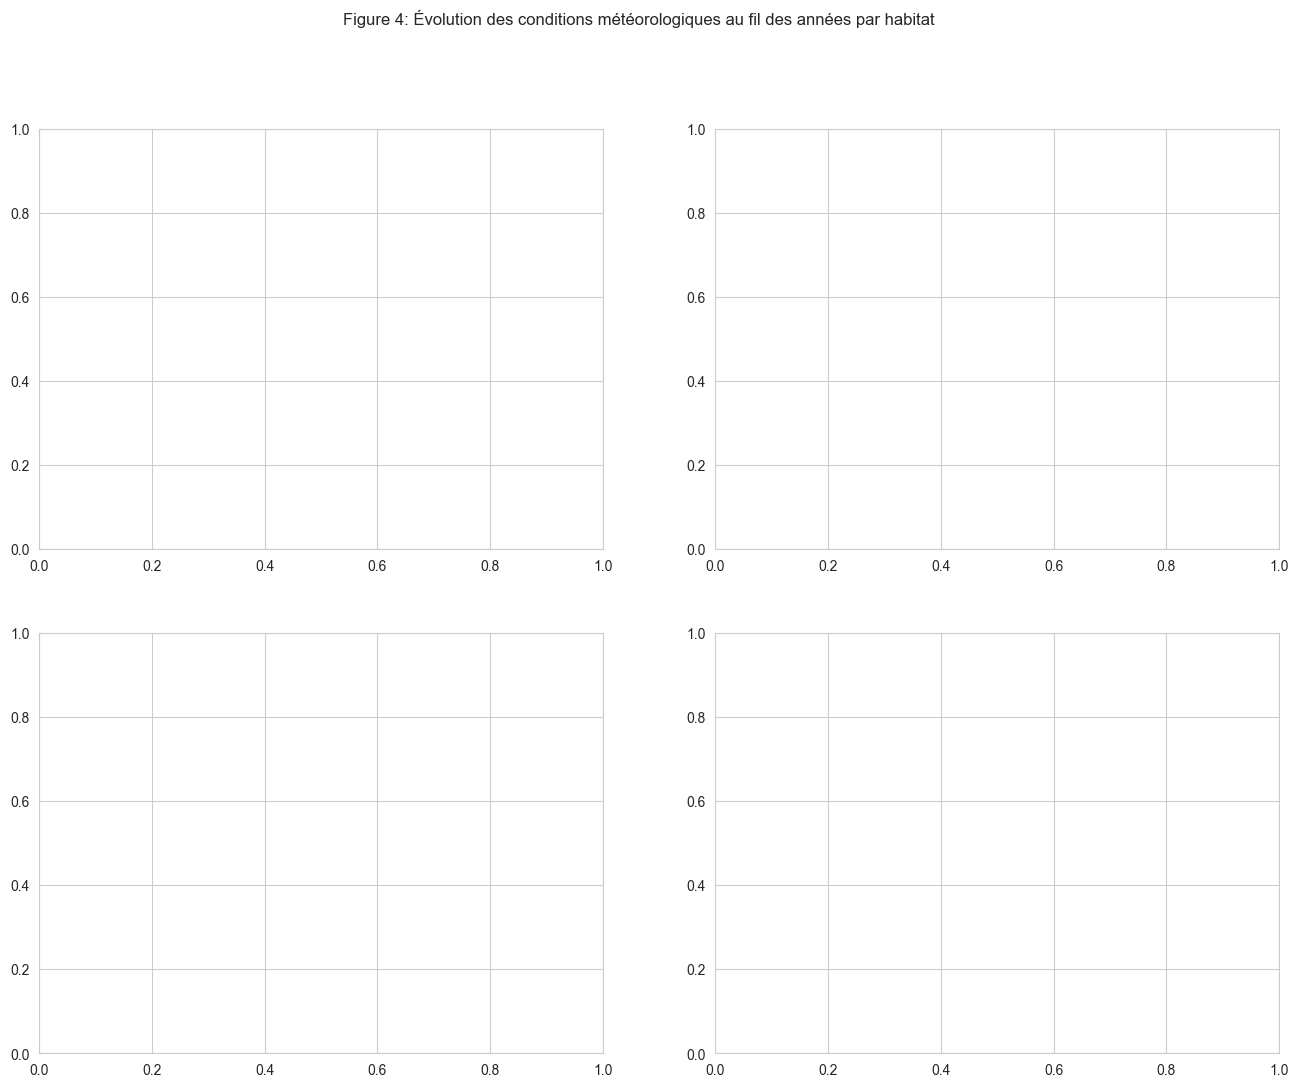

In [ ]:
# ============= VISUALISATIONS MÉTÉO - ÉVOLUTION TEMPORELLE PAR HABITAT =============
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f"Figure {fig_counter()}: Évolution des conditions météorologiques au fil des années par habitat")

# Définir une palette de couleurs pour les habitats
habitats = df_full['habitat'].unique()
colors = plt.cm.Set2(np.linspace(0, 1, len(habitats)))
habitat_colors = dict(zip(habitats, colors))

for idx, var in enumerate(weather_vars):
    ax = axes[idx//2, idx%2]
    
    # Tracer d'abord la courbe globale (toutes données confondues) en gras avec std
    yearly_global = df_full.groupby('year')[var].agg(['mean', 'std']).reset_index()
    
    # Bande d'écart-type pour la courbe globale
    ax.fill_between(yearly_global['year'], 
                     yearly_global['mean'] - yearly_global['std'], 
                     yearly_global['mean'] + yearly_global['std'], 
                     alpha=0.2, color='black', label='± 1 écart-type (global)')
    
    # Courbe globale en gras
    ax.plot(yearly_global['year'], yearly_global['mean'], 
            marker='o', linewidth=4, label='Global (global habitats)', 
            color='black', markersize=10, zorder=10, alpha=0.7)
    
    # Pour chaque habitat, tracer la moyenne
    for habitat in habitats:
        df_habitat = df_full[df_full['habitat'] == habitat]
        
        # Calculer la moyenne annuelle par habitat
        yearly_mean = df_habitat.groupby('year')[var].mean().reset_index()
        
        # Tracer uniquement la moyenne
        ax.plot(yearly_mean['year'], yearly_mean[var], 
                marker='o', linewidth=2, label=habitat, 
                color=habitat_colors[habitat], markersize=6, alpha=0.8)
    
    ax.set_title(f'{var}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Année', fontsize=11)
    ax.set_ylabel(var, fontsize=11)
    ax.legend(loc='best', fontsize=9, framealpha=0.9, title='Habitat')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 120)
print(f"STATISTIQUES MÉTÉOROLOGIQUES - ÉVOLUTION TEMPORELLE PAR HABITAT")
print("=" * 120)

for var in weather_vars:
    print("\n" + "-" * 120)
    print(f"VARIABLE: {var}")
    print("-" * 120)
    
    # Global statistics by year
    print("\n--- STATISTIQUES GLOBALES PAR ANNÉE ---")
    yearly_global = df_full.groupby('year')[var].agg(['count', 'mean', 'std', 'min', 'max']).reset_index()
    print(yearly_global.to_string(index=False, float_format=lambda x: f'{x:.2f}'))
    
    # Statistics by habitat and year
    print("\n--- MOYENNES PAR HABITAT ET ANNÉE ---")
    yearly_habitat = df_full.pivot_table(values=var, index='habitat', columns='year', aggfunc='mean')
    print(yearly_habitat.to_string(float_format=lambda x: f'{x:.2f}'))
    
    # Statistics by habitat (overall)
    print("\n--- STATISTIQUES PAR HABITAT (TOUTES ANNÉES) ---")
    habitat_stats = df_full.groupby('habitat')[var].agg(['count', 'mean', 'std', 'min', 'max'])
    print(habitat_stats.to_string(float_format=lambda x: f'{x:.2f}'))
    
    # Overall statistics
    print("\n--- STATISTIQUES GLOBALES (TOUTES DONNÉES) ---")
    print(f"Count:  {df_full[var].count():.0f}")
    print(f"Mean:   {df_full[var].mean():.2f}")
    print(f"Std:    {df_full[var].std():.2f}")
    print(f"Min:    {df_full[var].min():.2f}")
    print(f"Max:    {df_full[var].max():.2f}")
    print(f"Median: {df_full[var].median():.2f}")

print("\n" + "=" * 120)

In [ ]:
df_full.columns

Index(['observer', 'dept_code', 'transect', 'date', 'visit_number', 'clouds',
       'rain', 'wind', 'visibility', 'point', 'start_time', 'species',
       'auditory_0_25m', 'visual_0_25m', 'auditory_25_50m', 'visual_25_50m',
       'auditory_50_100m', 'visual_50_100m', 'auditory_100m_plus',
       'visual_100m_plus', 'flight', 'auditory_total',
       'visual__no_flight_total', 'auditory_visual_no_flight_total',
       'auditory_visual_with_flight_total', 'Notes', 'french_name',
       'scientific_name', 'status', 'X', 'Y', 'habitat', 'year', 'month'],
      dtype='object')

In [ ]:
from IPython.display import Markdown, display

fig_num = 5
habitat = "Agricultural"

display(Markdown(f"""
## 1.3 Notable Data Quality Considerations

#### Missing Data
- ```dept_code```: Two missing values were filled using department codes from corresponding transects.
- **Weather columns** (```clouds```, ```rain```, ```wind```, ```visibility```): Multiple imputation methods were considered; we chose ... because ...
- **Distance columns**: Missing values represented zeros and were filled accordingly.

#### Data Limitations
- **Textual notes**: The 'Notes' column contains valuable observational remarks that we plan to convert into numerical indicators for biodiversity analysis. **TODO**
- **Temporal coverage**: All observations occur between March and June, limiting our ability to predict biodiversity indicators outside this seasonal window.
- **Observer participation**: The number of observers dropped sharply in late 2020 due to the COVID-19 pandemic, but the number of treated transects remained constant, therefore, a decrease in number of observations per transect, in consequence, a high variability due to lack of data and high bias due to lack of observators.
- **Non-homogeneous observations**: Spatial analysis reveals significant sampling bias across multiple dimensions:
  - Figure {counter1}[2, 1]: Transects ordered by coordinates show highly uneven observation density, with some zones heavily sampled while others have minimal coverage, likely due to accessibility constraints or geographic barriers.
  - Figure {counter1}[1, 1]: Observation counts vary dramatically across habitat types, reflecting both accessibility issues and unequal habitat availability in the study area.
  - Figure {counter1}[0, 1]: High variability in the observer to observation ratio per transect some transects have many observations from few observers, while others show the opposite pattern introducing potential observer bias.
  
  These spatial and sampling imbalances may significantly affect model predictions and biodiversity assessments.
"""))


## 1.3 Notable Data Quality Considerations

#### Missing Data
- ```dept_code```: Two missing values were filled using department codes from corresponding transects.
- **Weather columns** (```clouds```, ```rain```, ```wind```, ```visibility```): Multiple imputation methods were considered; we chose ... because ...
- **Distance columns**: Missing values represented zeros and were filled accordingly.

#### Data Limitations
- **Textual notes**: The 'Notes' column contains valuable observational remarks that we plan to convert into numerical indicators for biodiversity analysis. **TODO**
- **Temporal coverage**: All observations occur between March and June, limiting our ability to predict biodiversity indicators outside this seasonal window.
- **Observer participation**: The number of observers dropped sharply in late 2020 due to the COVID-19 pandemic, but the number of treated transects remained constant, therefore, a decrease in number of observations per transect, in consequence, a high variability due to lack of data and high bias due to lack of observators.
- **Non-homogeneous observations**: Spatial analysis reveals significant sampling bias across multiple dimensions:
  - Figure 3[2, 1]: Transects ordered by coordinates show highly uneven observation density, with some zones heavily sampled while others have minimal coverage, likely due to accessibility constraints or geographic barriers.
  - Figure 3[1, 1]: Observation counts vary dramatically across habitat types, reflecting both accessibility issues and unequal habitat availability in the study area.
  - Figure 3[0, 1]: High variability in the observer to observation ratio per transect some transects have many observations from few observers, while others show the opposite pattern introducing potential observer bias.

  These spatial and sampling imbalances may significantly affect model predictions and biodiversity assessments.


## 1.3 Notable Data Quality Considerations

#### Missing Data
- ```dept_code```: Two missing values were filled using department codes from corresponding transects.
- **Weather columns** (```clouds```, ```rain```, ```wind```, ```visibility```): Multiple imputation methods were considered; we chose ... because ...
- **Distance columns**: Missing values represented zeros and were filled accordingly.

#### Data Limitations
- **Textual notes**: The 'Notes' column contains valuable observational remarks that we plan to convert into numerical indicators for biodiversity analysis. **TODO**
- **Temporal coverage**: All observations occur between March and June, limiting our ability to predict biodiversity indicators outside this seasonal window.
- **Observer participation**: The number of observers dropped sharply in late 2020 due to the COVID-19 pandemic, but the number of treated transects remained constant, therefore, a decrease in number of observations per transect, in consequence, a high variability due to lack of data and high bias due to lack of observators.
- **Non-homogeneous observations**: Spatial analysis reveals significant sampling bias across multiple dimensions:
  - Figure {counter1}[2, 1]: Transects ordered by coordinates show highly uneven observation density, with some zones heavily sampled while others have minimal coverage, likely due to accessibility constraints or geographic barriers.
  - Figure {counter1}[1, 1]: Observation counts vary dramatically across habitat types, reflecting both accessibility issues and unequal habitat availability in the study area.
  - Figure {counter1}[0, 1]: High variability in the observer to observation ratio per transect some transects have many observations from few observers, while others show the opposite pattern introducing potential observer bias.
  
  These spatial and sampling imbalances may significantly affect model predictions and biodiversity assessments.

-----------------------------------------------------------------------------------------------------------------------------------------------------

# 2. Multi-year indicators trends

L'effort d'échantillognage n'est pas égal pour tous les transects => effort non égal pour l'observation des espèces => l'abondance ne peut être fiable 

Nous avons calculé des indices de rareté spatiale basés sur la prévalence des espèces dans les sites d'échantillonnage. Une espèce est considérée comme rare si elle occupe une faible proportion des points de relevé, reflétant une distribution géographique restreinte à l'échelle de l'étude.

## 2.1 Selection of top-3 informative biodiversity indicators

In [ ]:
def normalize_safe(x):
        if x.max() == x.min():
                return pd.Series(0.5, index=x.index)
        return (x - x.min()) / (x.max() - x.min())

In [ ]:
# Sélectionner les colonnes pertinentes
cols_bio = ['transect', 'point', 'year', 'species']
df_bio = df_full[cols_bio].copy()

# Ajouter le comptage et filtrer les observations valides
df_bio['count'] = df_full['auditory_visual_with_flight_total'].fillna(0)
df_bio = df_bio[df_bio['count'] > 0]

### Types of Biological Diversity

- **Specific diversity** species richness and relative abundance (equitability).
- **Taxonomic diversity** Reflecting how taxonomically distant species are.
- **Phylogenetic diversity** represents the evolutionary history shared by species in a community.
- **Functional diversity** measures variation in functional traits (e.g., size, diet, color) that affect ecosystem functioning.
- **Spatial diversity** includes:  
    - **Alpha (α):**  number of species within a habitat.  
    - **Beta (β):** species turnover between habitats or along gradients.  
    - **Gamma (γ):** total regional diversity, integrating multiple habitats.


For more details check: https://fr.wikipedia.org/wiki/Indicateur_de_biodiversit%C3%A9

### 2.1.1 Hill Numbers
A family of diversity indices (```q=0``` is richness, ```q=1``` is Shannon entropy, ```q=2``` is Simpson). The parameter ```q``` controls sensitivity to rare vs. common species.

**Justification of choice:**
- Taking into account both species richness and evenness 
- When ```q``` is small, rare species have more importance.  
- When ```q``` is large, common species have more importance.
  
General formula:

$$D(q) = \left[ \sum_{i=1}^{S} p_i^q \right]^{\frac{1}{1-q}}$$

where:
- $D(q)$: Hill number of order $q$
- $S$: total number of species
- $p_i$: relative abundance of species $i$
- $q$: order of diversity (controls sensitivity to species abundances)

### 2.1.2 Species Richness (Hill number for q=0)
**Justification of choice:**
- Number of species.
- Completely ignores abundances. A rare or endangered species counts the same as a very common one


### 2.1.3 Detection of Local Extinctions (evlution of Alpha indicator over time)
**Justification of choice:**
- Identifies potentially extinct species  
- Directly actionable (which species to prioritize for protection)  
- Sensitive to observations bias
- Does not distinguish actual extinction from zero detectability

### 2.1.4 Rarity-Weighted Richness
- Rare species contribute more than abundant ones  
- Takes both rarity and richness into account  
- Captures biodiversity quality in addition to species quantity



### 2.1.5 Prevalence
- Direct measure of spatial distribution  
- Provides species-specific local information  
- Not a global measure of diversity

## 2.2 Computation of diffrent measures for each indicator form 2014 to 2025

### 2.2.0 Prévalence


In [ ]:
# === 1. RARETÉ PAR ANNÉE (avec espèces absentes = prévalence 0) ===
rarete_annuelle = []

all_species = df_bio['species'].unique()

for year in df_bio['year'].unique():
    df_year = df_bio[df_bio['year'] == year]
    
    n_points_year = df_year['point'].nunique()
    
    prev_year = df_year.groupby('species')['point'].nunique() / n_points_year
    
    for species in all_species:
        if species in prev_year.index:
            prevalence = prev_year[species]
        else:
            prevalence = 0.0  # Espèce absente cette année
        
        rarete_annuelle.append({
            'year': year,
            'species': species,
            'prevalence': prevalence
        })

In [ ]:
df_rarete = pd.DataFrame(rarete_annuelle)

# Calculer les poids APRÈS (en excluant les prévalences = 0 pour éviter division par zéro)
df_rarete_actives = df_rarete[df_rarete['prevalence'] > 0].copy()

k = 1.0
for year in df_rarete_actives['year'].unique():
    mask = df_rarete_actives['year'] == year
    weights = 1 / (df_rarete_actives.loc[mask, 'prevalence'] ** k + 1e-6)
    df_rarete_actives.loc[mask, 'weight'] = weights / weights.sum()

# Ajouter weight = 0 pour les espèces absentes
df_rarete = df_rarete.merge(
    df_rarete_actives[['year', 'species', 'weight']], 
    on=['year', 'species'], 
    how='left'
)
df_rarete['weight'] = df_rarete['weight'].fillna(0)

### 2.2.1 Richesse spécifique 

In [ ]:
# Compter le nombre d'espèces UNIQUES par transect et par année
richesse = (
    df_bio.groupby(['transect', 'year'])['species']
    .nunique()
    .reset_index()
    .rename(columns={'species': 'nb_especes'})
)
n_species = df_bio.groupby('year')['species'].nunique()


print(richesse)
print(n_species)

           transect  year  nb_especes
0    anse couleuvre  2014          19
1    anse couleuvre  2015          18
2    anse couleuvre  2016          23
3    anse couleuvre  2017          17
4    anse couleuvre  2018          16
..              ...   ...         ...
718         verrier  2021          20
719         verrier  2022          24
720         verrier  2023          18
721         verrier  2024          24
722         verrier  2025          21

[723 rows x 3 columns]
year
2014    60
2015    65
2016    67
2017    64
2018    65
2019    65
2020    66
2021    65
2022    63
2023    62
2024    66
2025    70
Name: species, dtype: int64


### 2.2.2 Détection des extinctions locales

In [ ]:
# Première et dernière année d'observation par espèce
first_seen = df_bio.groupby('species')['year'].min()
last_seen = df_bio.groupby('species')['year'].max()
max_year = df_bio['year'].max()

# Espèces potentiellement éteintes (pas vues depuis 3+ ans)
seuil_extinction = 3
extinctions = last_seen[last_seen < (max_year - seuil_extinction)]

df_extinctions = pd.DataFrame({
    'species': extinctions.index,
    'first_year': first_seen[extinctions.index].values,
    'last_year': extinctions.values,
    'years_absent': max_year - extinctions.values
}).sort_values('last_year')

### 2.2.3 Nombres de Hill

In [ ]:
from scipy.stats import entropy

def hill_number(counts, q):
    """Calcul des nombres de Hill"""
    counts = np.array(counts)
    counts = counts[counts > 0]  # Enlever les zéros
    p = counts / counts.sum()
    
    if q == 1:
        return np.exp(entropy(p))  # Shannon
    elif q == 0:
        return len(counts)  # Richesse
    else:
        return (np.sum(p ** q)) ** (1 / (1 - q))  # Hill général

# Calculer pour chaque année
hill_results = []
for year in df_bio['year'].unique():
    df_year = df_bio[df_bio['year'] == year]
    species_counts = df_year.groupby('species')['count'].sum()
    
    hill_results.append({
        'year': year,
        'richness_q0': hill_number(species_counts, q=0),
        'shannon_q1': hill_number(species_counts, q=1),
        'simpson_q2': hill_number(species_counts, q=2)
    })

df_hill = pd.DataFrame(hill_results).sort_values('year')

### 2.2.4.a Classic RWR 


In [ ]:
def calculate_rwr_with_k(df_bio, k_value):
    """Calcule le RWR avec un k donné"""
    all_species = df_bio['species'].unique()
    
    # 1. Calculer les prévalences annuelles
    rarete = []
    for year in df_bio['year'].unique():
        df_year = df_bio[df_bio['year'] == year]
        n_points = df_year['point'].nunique()
        prev = df_year.groupby('species')['point'].nunique() / n_points
        
        for species in all_species:
            rarete.append({
                'year': year,
                'species': species,
                'prevalence': prev.get(species, 0.0)
            })
    
    df_rarete = pd.DataFrame(rarete)
    
    # 2. Calculer les poids (avec k variable)
    df_active = df_rarete[df_rarete['prevalence'] > 0].copy()
    
    for year in df_active['year'].unique():
        mask = df_active['year'] == year
        df_active.loc[mask, 'weight'] = 1 / (df_active.loc[mask, 'prevalence'] ** k_value + 1e-6)
    
    #2bis. Normaliser les poids par année
    df_active['weight'] = 1 / (df_active['prevalence'] ** k_value + 1e-6)
    df_active['weight'] = df_active['weight'] / df_active['weight'].sum()

    # 3. Calculer RWR par année (UNE FOIS PAR ESPÈCE)
    rwr = (
        df_active.groupby('year')['weight']
        .sum()
        .reset_index()
        .rename(columns={'weight': 'RWR'})
    )

    
    return rwr

# Tester plusieurs valeurs
k_tests = [0.5, 1.0, 1.5, 2.0]
rwr_comparison = pd.DataFrame({'year': df_bio['year'].unique()})

for k in k_tests:
    rwr = calculate_rwr_with_k(df_bio, k)
    rwr_comparison = rwr_comparison.merge(
        rwr.rename(columns={'RWR': f'RWR_k{k}'}),
        on='year',
        how='left'
    )

print(rwr_comparison)

    year  RWR_k0.5  RWR_k1.0  RWR_k1.5  RWR_k2.0
0   2014  0.083769  0.091670  0.098271  0.102529
1   2015  0.085736  0.087643  0.088705  0.089070
2   2016  0.087530  0.088444  0.088082  0.086767
3   2017  0.083259  0.083495  0.082257  0.080055
4   2018  0.081560  0.079184  0.077512  0.076873
5   2019  0.083541  0.082972  0.082037  0.081142
6   2020  0.080048  0.074381  0.070295  0.068429
7   2021  0.082806  0.084123  0.087107  0.090322
8   2022  0.076049  0.070375  0.065797  0.062975
9   2023  0.075792  0.072995  0.072396  0.073300
10  2024  0.084886  0.084494  0.083608  0.082569
11  2025  0.095025  0.100224  0.103935  0.105969


### 2.2.4.b RWR avec bootstrap et normalisé par le nombre d'espèces 
Les années présentant un effort d’échantillonnage plus important détectent mécaniquement davantage d’espèces, y compris les plus rares, ce qui peut conduire à une surestimation du RWR.
- L’application d’un bootstrap permet de pallier en partie ce biais : l’indicateur est recalculé à partir de sous-échantillons de taille égale (nombre de points identique par année), répétés de nombreuses fois. Cette procédure homogénéise l’effort d’échantillonnage et fournit une estimation moyenne du RWR accompagnée de son incertitude.
- La normalisation par le nombre d’espèces observées permet ensuite de comparer les valeurs entre années ou régions, indépendamment des différences de richesse spécifique.
Ainsi, un RWR normalisé élevé traduit une communauté composée d’espèces plus rares ou à répartition plus restreinte, tandis qu’un RWR normalisé faible indique une dominance d’espèces plus communes ou plus largement réparties.


Pourquoi le bootstrap et pas une autre méthode ?

- Bien que le dataset ne soit pas petit, les statistiques ont des formules inconnues et nous voulons éviter de faire des hypothèses sur la forme de la distribution (Pas de méthodes asymptotiques)
- Pas de Jacknife car on se respecte
- On veut des intervalles de confiance 
- Manque de temps pour debattre le choix des priors (Bayésien à éviter)

In [ ]:
def calculate_rwr_multiple_k_bootstrap(df_bio, k_values=[0.5, 1.0, 1.5, 2.0], 
                                    n_boot=200, sample_fraction=0.8, random_state=42):
    """
    Calcule le RWR pour plusieurs k avec bootstrap.
    
    sample_fraction: proportion de points à échantillonner (ex: 0.8 = 80%)
    """
    rng = np.random.default_rng(random_state)
    all_years = sorted(df_bio['year'].unique())
    all_species = df_bio['species'].unique()
    
    boot_results = []

    for b in range(n_boot):
        year_results = {k: [] for k in k_values}
        
        for year in all_years:
            df_year = df_bio[df_bio['year'] == year]
            all_points = df_year['point'].unique()
            
            # Échantillonner une fraction des points
            n_sample = max(1, int(len(all_points) * sample_fraction))
            sampled_points = rng.choice(all_points, n_sample, replace=False)
            df_sample = df_year[df_year['point'].isin(sampled_points)]
            
            n_points = df_sample['point'].nunique()
            prev = df_sample.groupby('species')['point'].nunique() / n_points
            
            df_r = pd.DataFrame({
                'species': all_species,
                'prevalence': [prev.get(sp, 0.0) for sp in all_species]
            })
            df_r = df_r[df_r['prevalence'] > 0]
            
            for k in k_values:
                df_r['weight'] = 1 / (df_r['prevalence'] ** k + 1e-6)
                rwr_value = df_r['weight'].sum() / len(df_r)
                year_results[k].append({'year': year, 'RWR': rwr_value, 'k': k})
        
        for k in k_values:
            boot_results.extend(year_results[k])

    df_boot_all = pd.DataFrame(boot_results)
    
    rwr_summary = (
        df_boot_all.groupby(['year', 'k'])['RWR']
        .agg(
            RWR_mean='mean',
            RWR_sd='std',
            RWR_q2_5=lambda x: np.percentile(x, 2.5),
            RWR_q97_5=lambda x: np.percentile(x, 97.5)
        )
        .reset_index()
    )
    
    return rwr_summary

In [ ]:
k_tests = [0.5, 1.0, 1.5, 2.0]
rwr_boot_comparison = pd.DataFrame({'year': sorted(df_bio['year'].unique())})

# Calculer UNE SEULE FOIS pour tous les k
rwr_summary = calculate_rwr_multiple_k_bootstrap(df_bio, k_values=k_tests, n_boot=500)

# Pivoter pour avoir une colonne par k
for k in k_tests:
    k_data = rwr_summary[rwr_summary['k'] == k][['year', 'RWR_mean', 'RWR_sd', 'RWR_q2_5', 'RWR_q97_5']]
    k_data = k_data.rename(columns={
        'RWR_mean': f'RWR_k{k}',
        'RWR_sd': f'RWR_k{k}_sd',
        'RWR_q2_5': f'RWR_k{k}_q2_5',
        'RWR_q97_5': f'RWR_k{k}_q97_5'
    })
    rwr_boot_comparison = rwr_boot_comparison.merge(k_data, on='year', how='left')

print(rwr_boot_comparison)

    year  RWR_k0.5  RWR_k0.5_sd  RWR_k0.5_q2_5  RWR_k0.5_q97_5  RWR_k1.0  \
0   2014  1.499543     0.054889       1.356120        1.577690  2.730949   
1   2015  1.435566     0.036843       1.365133        1.493690  2.477601   
2   2016  1.437371     0.032894       1.382872        1.504011  2.506567   
3   2017  1.434599     0.045389       1.341764        1.509289  2.497798   
4   2018  1.369364     0.033055       1.318509        1.446608  2.234934   
5   2019  1.409851     0.034736       1.331860        1.467505  2.388388   
6   2020  1.330458     0.033314       1.265550        1.401533  2.087308   
7   2021  1.371078     0.049388       1.272776        1.454158  2.295541   
8   2022  1.331905     0.027886       1.278079        1.382399  2.112200   
9   2023  1.326522     0.029589       1.233007        1.385217  2.119423   
10  2024  1.410863     0.026801       1.364475        1.463227  2.399964   
11  2025  1.473774     0.028236       1.420876        1.519134  2.620438   

    RWR_k1.

### 2.2.5 Composite Biodiversity Index 

In [ ]:
def calculate_cbi_grid(df_bio, rwr_summary, lambda_value, n_boot=500):
    """Calcule le CBI pour un couple (k, λ) avec RWR bootstrapé et intervalles de confiance."""
    
    # 1. Calculer Shannon (Hill q=1)
    hill_results = []
    for year in df_bio['year'].unique():
        df_year = df_bio[df_bio['year'] == year]
        counts = df_year.groupby('species')['count'].sum()
        p = counts / counts.sum()
        shannon = np.exp(-np.sum(p * np.log(p + 1e-10)))
        hill_results.append({'year': year, 'shannon': shannon})
    df_shannon = pd.DataFrame(hill_results)

    # 2. Préparer RWR avec intervalles
    rwr = rwr_summary[['year', 'RWR_mean', 'RWR_q2_5', 'RWR_q97_5']].copy()
    rwr = rwr.rename(columns={'RWR_mean': 'RWR'})

    # 3. Fusion
    df_combined = df_shannon.merge(rwr, on='year', how='inner')

    # 4. Normalisation (min-max)
    shannon_norm = (df_combined['shannon'] - df_combined['shannon'].min()) / \
                    (df_combined['shannon'].max() - df_combined['shannon'].min() + 1e-10)

    rwr_norm = (df_combined['RWR'] - df_combined['RWR'].min()) / \
                (df_combined['RWR'].max() - df_combined['RWR'].min() + 1e-10)
    
    # Normaliser aussi les intervalles de confiance du RWR
    rwr_q2_5_norm = (df_combined['RWR_q2_5'] - df_combined['RWR'].min()) / \
                    (df_combined['RWR'].max() - df_combined['RWR'].min() + 1e-10)
    
    rwr_q97_5_norm = (df_combined['RWR_q97_5'] - df_combined['RWR'].min()) / \
                    (df_combined['RWR'].max() - df_combined['RWR'].min() + 1e-10)

    # 5. Calcul du CBI avec IC
    df_combined['CBI'] = lambda_value * shannon_norm + (1 - lambda_value) * rwr_norm
    df_combined['CBI_q2_5'] = lambda_value * shannon_norm + (1 - lambda_value) * rwr_q2_5_norm
    df_combined['CBI_q97_5'] = lambda_value * shannon_norm + (1 - lambda_value) * rwr_q97_5_norm

    return df_combined

## 2.3 Quantification and interpretation of temporal trends 

### Prévalence

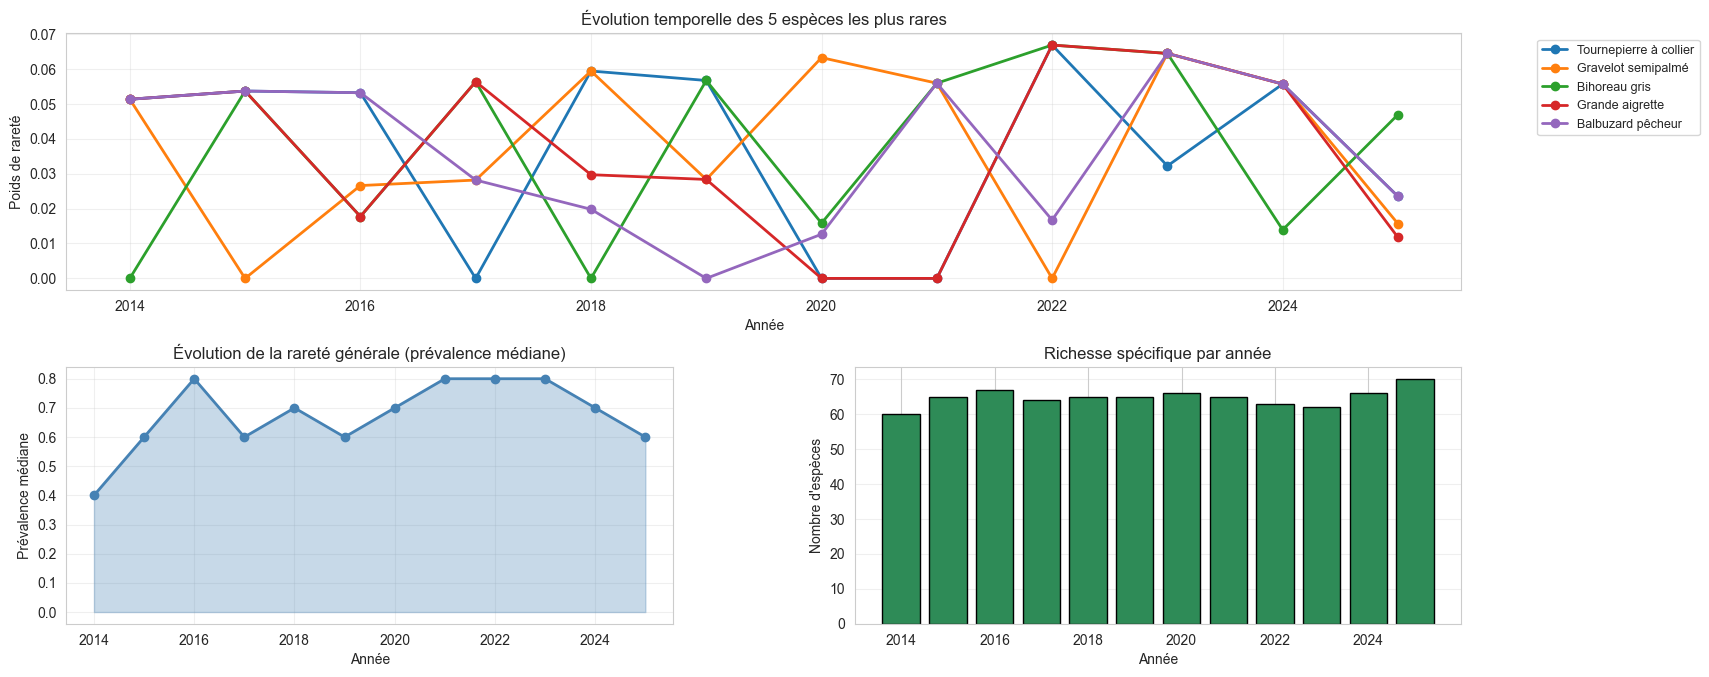

In [ ]:
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Top 5 espèces les plus rares par année
ax1 = fig.add_subplot(gs[0, :])
top_species = df_rarete.groupby('species')['weight'].mean().nlargest(5).index

for species in top_species:
    data = df_rarete[df_rarete['species'] == species].sort_values('year')
    ax1.plot(data['year'], data['weight'], marker='o', label=species[:25], linewidth=2)

ax1.set_xlabel('Année')
ax1.set_ylabel('Poids de rareté')
ax1.set_title('Évolution temporelle des 5 espèces les plus rares')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[1, 0])
prev_median = df_rarete.groupby('year')['prevalence'].median()
ax2.plot(prev_median.index, prev_median.values, marker='o', linewidth=2, color='steelblue')
ax2.fill_between(prev_median.index, prev_median.values, alpha=0.3, color='steelblue')
ax2.set_xlabel('Année')
ax2.set_ylabel('Prévalence médiane')
ax2.set_title('Évolution de la rareté générale (prévalence médiane)')
ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])
n_species = df_bio.groupby('year')['species'].nunique()
ax3.bar(n_species.index, n_species.values, color='seagreen', edgecolor='black')
ax3.set_xlabel('Année')
ax3.set_ylabel('Nombre d\'espèces')
ax3.set_title('Richesse spécifique par année')
ax3.grid(axis='y', alpha=0.3)

plt.show()

In [ ]:
print(f"\nSTATISTIQUES DE RARETÉ")
print(f"{'='*50}")
print(f"Nombre total d'espèces observées : {df_bio['species'].nunique()}")
print(f"Période : {df_bio['year'].min()} → {df_bio['year'].max()}")

print(f"\nPrévalence médiane par année :")
print(prev_median)

print(f"\nPOIDS DE RARETÉ MOYEN PAR ESPÈCE :")
top_species_weights = df_rarete.groupby('species')['weight'].mean().sort_values(ascending=False)
print(top_species_weights.head(10))



STATISTIQUES DE RARETÉ
Nombre total d'espèces observées : 81
Période : 2014 → 2025

Prévalence médiane par année :
year
2014    0.4
2015    0.6
2016    0.8
2017    0.6
2018    0.7
2019    0.6
2020    0.7
2021    0.8
2022    0.8
2023    0.8
2024    0.7
2025    0.6
Name: prevalence, dtype: float64

POIDS DE RARETÉ MOYEN PAR ESPÈCE :
species
Tournepierre à collier    0.037727
Gravelot semipalmé        0.037416
Bihoreau gris             0.037379
Grande aigrette           0.036336
Balbuzard pêcheur         0.036270
Sterne bridée             0.033931
Mouette atricilla         0.032793
Chevalier solitaire       0.026569
Sterne royale             0.025238
Colibri à tête bleue      0.024269
Name: weight, dtype: float64


# TODO Changez les chiffres avec partie 1

### En haut : Evolution temporelle des 5 espèces les plus rares.
-Les prévalences sont très faibles (< 0.07, soit < 7%)
-Il y a une forte variabilité interannuelle - les espèces semblent apparaître et disparaître de façon erratique
-Aucune tendance claire de croissance ou déclin constant
=>Cette variabilité pourrait refléter des fluctuations naturelles, des migrations irrégulières, ou simplement un faible effectif d'échantillonnage pour ces espèces rares

Si dues au faible nombre de détections combiné à l'effort d'échantillonnage variable une espèce est vue 30 fois en 2014 aura une prévalence = 30/800 = 3.75%
La même espèce vue 50 fois en 2025 => prévalence = 50/1400 = 3.57%
Même avec plus d'observations absolues, la prévalence peut stagner ou baisser !
Les "pics" pourraient refléter des années avec plus de passages migratoires ou meilleures conditions

### Graphique en bas à gauche : Rareté générale (prévalence médiane)
Montre l'évolution de la rareté globale dans l'écosystème :
-Augmentation de ~0.4 en 2014 à ~0.8 en 2020
-Puis stabilisation/légère baisse après 2020
=>Cela suggère qu'en médiane, les espèces sont devenues plus communes (moins rares) jusqu'en 2020

L'augmentation de 0.4 à 0.8 est impressionnante car elle se produit malgré l'augmentation de l'effort d'échantillonnage
Cela signifie que les espèces médianes sont réellement devenues plus communes
Ce n'est pas un artefact d'échantillonnage - au contraire, l'effet est sous-estimé si on ne corrige pas pour l'effort
Possibles explications : amélioration de l'habitat, mesures de conservation efficaces, ou changement dans la composition de la communauté

### Graphique en bas à droite : Richesse spécifique (Nombre d'espèces observées)

La stabilité autour de 60-70 espèces malgré 75% d'observations en plus (800 -> 1200) est surprenante
On s'attendrait normalement à détecter plus d'espèces rares avec plus d'effort
Cela suggère soit :

- Un plateau dans la courbe espèces-effort (toutes les espèces présentes sont déjà détectées) - Or on sait qu'il y'a au moins 81 espèces
- Une perte réelle de diversité qui compense l'augmentation d'effort
- Un protocole d'échantillonnage qui sature la détection



### Extinction

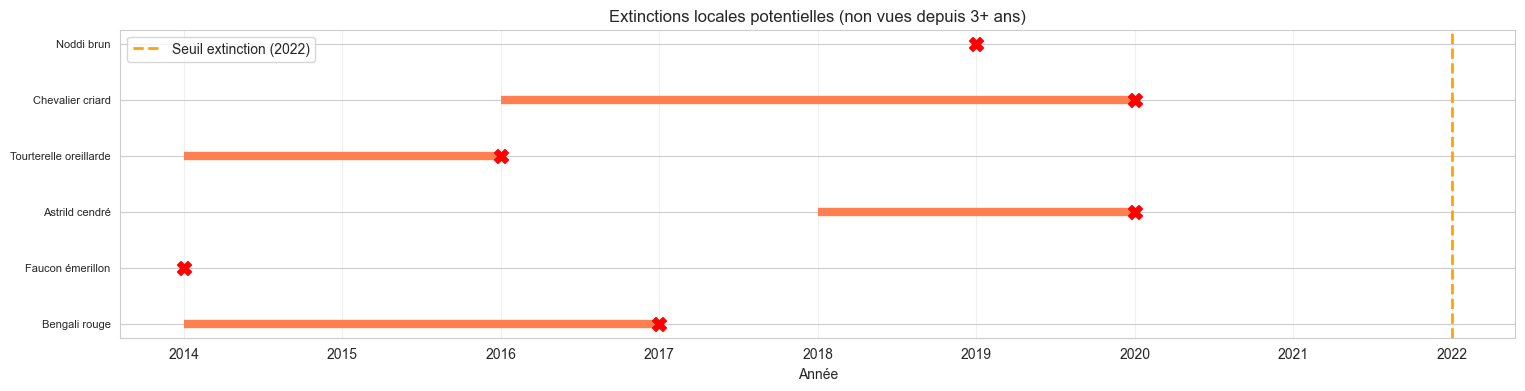

In [ ]:
fig, ax4 = plt.subplots(figsize=(18, 4))

if len(df_extinctions) > 0:
    top_extinctions = df_extinctions.nlargest(20, 'years_absent')
    for idx, row in top_extinctions.iterrows():
        ax4.plot([row['first_year'], row['last_year']], [idx, idx],
                linewidth=6, solid_capstyle='butt', color='coral')
        ax4.scatter(row['last_year'], idx, color='red', s=100, zorder=3, marker='X')
    ax4.set_yticks(range(len(top_extinctions)))
    ax4.set_yticklabels([sp[:30] for sp in top_extinctions['species']], fontsize=8)
    ax4.set_xlabel('Année')
    ax4.set_title(f'Extinctions locales potentielles (non vues depuis {seuil_extinction}+ ans)')
    ax4.axvline(max_year - seuil_extinction, color='orange', linestyle='--',
                label=f'Seuil extinction ({max_year - seuil_extinction})', linewidth=2)
    ax4.legend()
    ax4.grid(axis='x', alpha=0.3)
else:
    ax4.text(0.5, 0.5, 'Aucune extinction détectée', ha='center', va='center', fontsize=14)
    ax4.set_title('Extinctions locales')

plt.show()


In [ ]:
print(f"\nEXTINCTIONS POTENTIELLES")
print(f"{'='*50}")
print(f"Nombre d'espèces non vues depuis {seuil_extinction}+ ans : {len(df_extinctions)}")
if len(df_extinctions) > 0:
    print(f"\nTop 10 disparitions les plus anciennes :")
    print(df_extinctions.head(10).to_string(index=False))



EXTINCTIONS POTENTIELLES
Nombre d'espèces non vues depuis 3+ ans : 6

Top 10 disparitions les plus anciennes :
               species  first_year  last_year  years_absent
         Bengali rouge        2014       2014            11
      Faucon émerillon        2014       2016             9
        Astrild cendré        2014       2017             8
Tourterelle oreillarde        2019       2019             6
      Chevalier criard        2018       2020             5
            Noddi brun        2016       2020             5


Bien que l’argument par ignorance soit fallacieux en logique, en biologie la présomption d’extinction repose sur l’absence prolongée d’observations malgré des recherches ciblées.
Dans le cas du Bengali rouge, aucune observation n’a été rapportée depuis 11 ans. Cela peut indiquer une forte raréfaction de l’espèce, voire une extinction locale, mais cela ne constitue pas une preuve d’extinction sans données de terrain supplémentaires.

### HILL

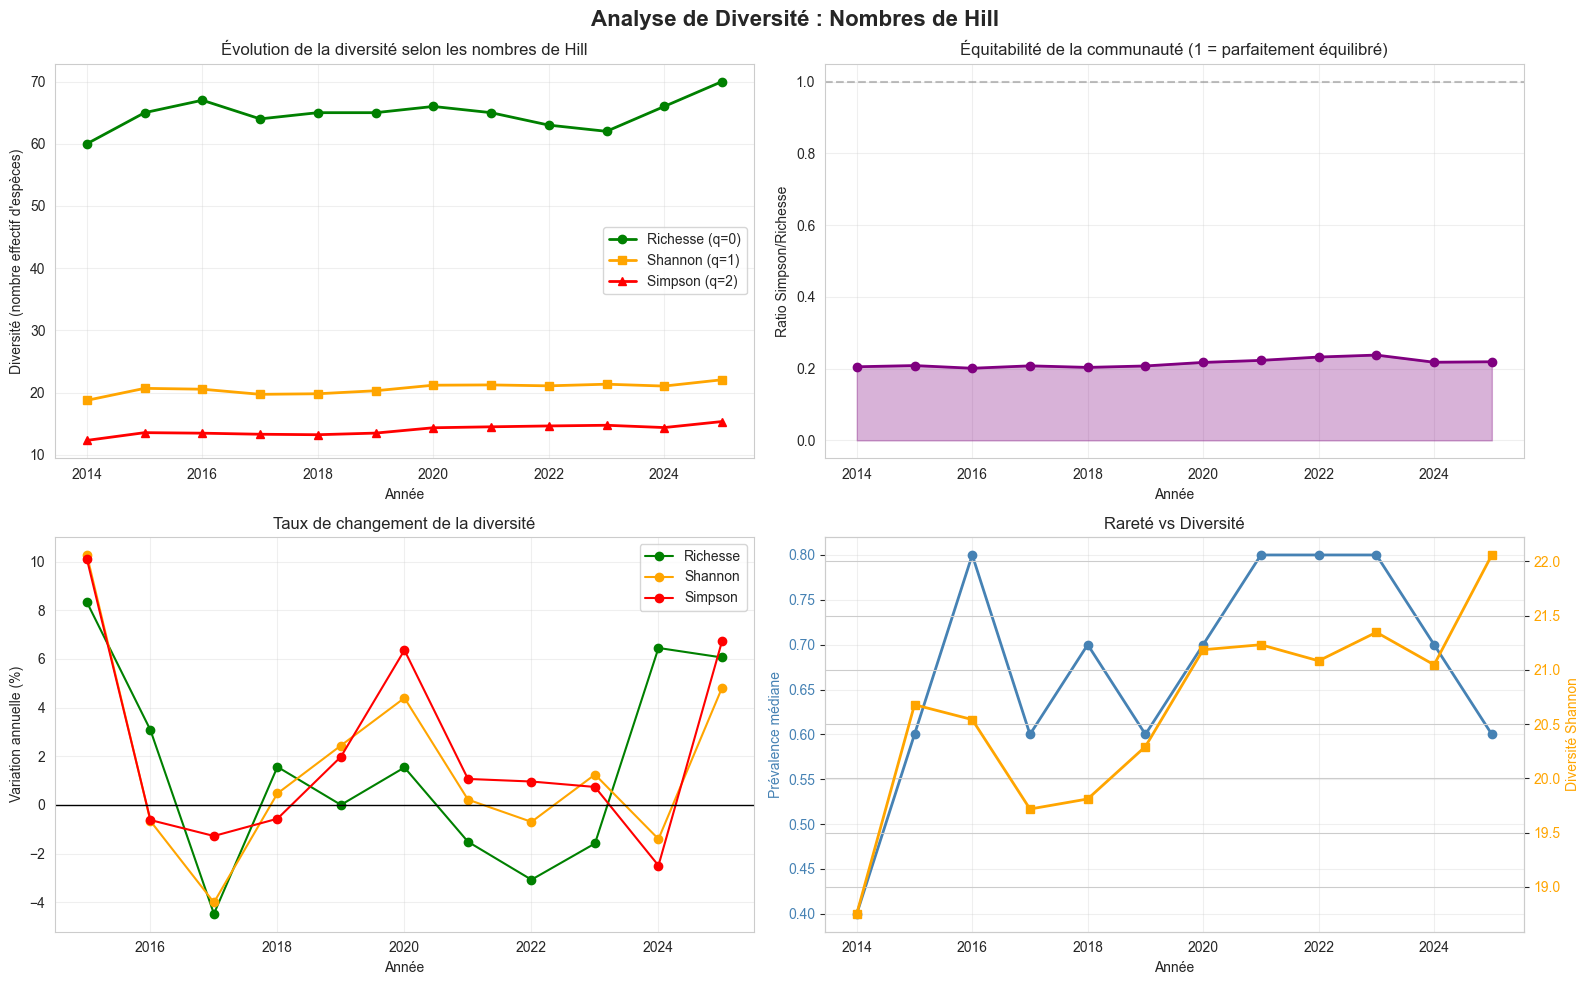

In [ ]:
from scipy.stats import linregress

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Évolution des 3 indices de Hill
ax1 = axes[0, 0]
ax1.plot(df_hill['year'], df_hill['richness_q0'], marker='o', linewidth=2, 
        label='Richesse (q=0)', color='green')
ax1.plot(df_hill['year'], df_hill['shannon_q1'], marker='s', linewidth=2, 
        label='Shannon (q=1)', color='orange')
ax1.plot(df_hill['year'], df_hill['simpson_q2'], marker='^', linewidth=2, 
        label='Simpson (q=2)', color='red')
ax1.set_xlabel('Année')
ax1.set_ylabel('Diversité (nombre effectif d\'espèces)')
ax1.set_title('Évolution de la diversité selon les nombres de Hill')
ax1.legend()
ax1.grid(alpha=0.3)

# Ratio Simpson/Richesse (équitabilité)
ax2 = axes[0, 1]
equitability = df_hill['simpson_q2'] / df_hill['richness_q0']
ax2.plot(df_hill['year'], equitability, marker='o', linewidth=2, color='purple')
ax2.fill_between(df_hill['year'], equitability, alpha=0.3, color='purple')
ax2.set_xlabel('Année')
ax2.set_ylabel('Ratio Simpson/Richesse')
ax2.set_title('Équitabilité de la communauté (1 = parfaitement équilibré)')
ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
ax2.grid(alpha=0.3)

# Taux de changement annuel
ax3 = axes[1, 0]
for col, label, color in [('richness_q0', 'Richesse', 'green'), 
                        ('shannon_q1', 'Shannon', 'orange'),
                        ('simpson_q2', 'Simpson', 'red')]:
        changes = df_hill[col].pct_change() * 100
        ax3.plot(df_hill['year'][1:], changes[1:], marker='o', label=label, color=color)

ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax3.set_xlabel('Année')
ax3.set_ylabel('Variation annuelle (%)')
ax3.set_title('Taux de changement de la diversité')
ax3.legend()
ax3.grid(alpha=0.3)

# Comparaison Prévalence médiane vs Shannon
ax4 = axes[1, 1]
ax4_twin = ax4.twinx()

# Prévalence médiane (axe gauche)
prev_med = df_rarete.groupby('year')['prevalence'].median()
ax4.plot(prev_med.index, prev_med.values, marker='o', linewidth=2, 
        color='steelblue', label='Prévalence médiane')
ax4.set_xlabel('Année')
ax4.set_ylabel('Prévalence médiane', color='steelblue')
ax4.tick_params(axis='y', labelcolor='steelblue')

# Shannon (axe droit)
ax4_twin.plot(df_hill['year'], df_hill['shannon_q1'], marker='s', linewidth=2, 
                color='orange', label='Shannon (q=1)')
ax4_twin.set_ylabel('Diversité Shannon', color='orange')
ax4_twin.tick_params(axis='y', labelcolor='orange')

ax4.set_title('Rareté vs Diversité')
ax4.grid(alpha=0.3)

plt.suptitle('Analyse de Diversité : Nombres de Hill', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
print(f"\nDIVERSITÉ (Nombres de Hill)")
print(f"{'='*60}")
print(df_hill.to_string(index=False))

print(f"\nTENDANCES")
print(f"{'='*60}")
for col, label in [('richness_q0', 'Richesse'), 
                ('shannon_q1', 'Shannon'), 
                ('simpson_q2', 'Simpson')]:
    slope, _, r, p, _ = linregress(df_hill['year'], df_hill[col])
    trend = "Hausse" if slope > 0 else "Baisse"
    print(f"{label:12} : {slope:+.2f} espèces/an {trend} (R²={r**2:.2f}, p={p:.3f})")



DIVERSITÉ (Nombres de Hill)
 year  richness_q0  shannon_q1  simpson_q2
 2014           60   18.751359   12.311638
 2015           65   20.678152   13.555765
 2016           67   20.540939   13.471237
 2017           64   19.716665   13.298914
 2018           65   19.809445   13.223279
 2019           65   20.292825   13.485039
 2020           66   21.184738   14.342749
 2021           65   21.230735   14.495717
 2022           63   21.082536   14.634968
 2023           62   21.345479   14.742739
 2024           66   21.045857   14.375019
 2025           70   22.058072   15.341566

TENDANCES
Richesse     : +0.28 espèces/an Hausse (R²=0.16, p=0.197)
Shannon      : +0.20 espèces/an Hausse (R²=0.66, p=0.001)
Simpson      : +0.21 espèces/an Hausse (R²=0.82, p=0.000)


In [ ]:
print(f"\nINTERPRÉTATION DES RÉSULTATS")
print(f"{'='*60}")

# Comparer début et fin
premiere_annee = df_hill.iloc[0]
derniere_annee = df_hill.iloc[-1]

ratio_simpson_debut = premiere_annee['simpson_q2'] / premiere_annee['richness_q0']
ratio_simpson_fin = derniere_annee['simpson_q2'] / derniere_annee['richness_q0']

#En pourcentage
var_richesse = ((derniere_annee['richness_q0'] / premiere_annee['richness_q0']) - 1) * 100
var_shannon = ((derniere_annee['shannon_q1'] / premiere_annee['shannon_q1']) - 1) * 100
var_simpson = ((derniere_annee['simpson_q2'] / premiere_annee['simpson_q2']) - 1) * 100

# Tendances
from scipy.stats import linregress
pente_richesse, _, r2_rich, p_rich, _ = linregress(df_hill['year'], df_hill['richness_q0'])
pente_shannon, _, r2_shan, p_shan, _ = linregress(df_hill['year'], df_hill['shannon_q1'])
pente_simpson, _, r2_simp, p_simp, _ = linregress(df_hill['year'], df_hill['simpson_q2'])

print(f"\n1. EVOLUTION TEMPORELLE ({int(premiere_annee['year'])} - {int(derniere_annee['year'])})")
print("-" * 60)

if pente_richesse > 0 and pente_shannon > 0 and pente_simpson > 0:
    print("Tendance générale : Augmentation de la biodiversité")
    print(f"\nRichesse spécifique  : {premiere_annee['richness_q0']:.0f} -> {derniere_annee['richness_q0']:.0f} espèces ({var_richesse:+.1f}%)")
    print(f"Diversité Shannon    : {premiere_annee['shannon_q1']:.1f} -> {derniere_annee['shannon_q1']:.1f} ({var_shannon:+.1f}%)")
    print(f"Diversité Simpson    : {premiere_annee['simpson_q2']:.1f} -> {derniere_annee['simpson_q2']:.1f} ({var_simpson:+.1f}%)")
    
elif pente_richesse < 0 and pente_shannon < 0 and pente_simpson < 0:
    print("Tendance générale : Déclin de la biodiversité")
    print(f"\nPerte de richesse    : {pente_richesse:.2f} espèces/an (p={p_rich:.3f})")
    print(f"Perte de diversité   : Shannon {pente_shannon:.2f}/an, Simpson {pente_simpson:.2f}/an")
    
else:
    print("Tendance générale : Evolution contrastée")
    print(f"\nRichesse : {var_richesse:+.1f}% | Shannon : {var_shannon:+.1f}% | Simpson : {var_simpson:+.1f}%")

print(f"\n2. STRUCTURE DE LA COMMUNAUTE")
print("-" * 60)

n_dominantes = int(derniere_annee['simpson_q2'])
n_totales = int(derniere_annee['richness_q0'])

print(f"Nombre d'espèces total        : {n_totales}")
print(f"Espèces dominantes effectives : ~{n_dominantes}")
print(f"Ratio dominantes/total        : {ratio_simpson_fin:.2f}")

if ratio_simpson_fin > 0.7:
    diagnostic = "Communauté équilibrée - Faible dominance"
elif ratio_simpson_fin > 0.5:
    diagnostic = "Communauté moyennement équilibrée"
elif ratio_simpson_fin > 0.3:
    diagnostic = "Dominance modérée - Structure typique"
else:
    diagnostic = "Dominance forte - Concentration sur quelques espèces"

print(f"\nDiagnostic : {diagnostic}")

# Evolution de l'équitabilité
delta_ratio = ratio_simpson_fin - ratio_simpson_debut
if abs(delta_ratio) < 0.05:
    tendance_equit = "stable"
elif delta_ratio > 0:
    tendance_equit = "en amélioration"
else:
    tendance_equit = "en dégradation"

print(f"Evolution de l'équitabilité : {tendance_equit} (delta = {delta_ratio:+.3f})")

print(f"\n3. SIGNIFICATIVITE STATISTIQUE")
print("-" * 60)
print(f"Richesse  : R² = {r2_rich**2:.2f}, p-value = {p_rich:.4e} {'(significatif)' if p_rich < 0.05 else '(non significatif)'}")
print(f"Shannon   : R² = {r2_shan**2:.2f}, p-value = {p_shan:.4e} {'(significatif)' if p_shan < 0.05 else '(non significatif)'}")
print(f"Simpson   : R² = {r2_simp**2:.2f}, p-value = {p_simp:.4e} {'(significatif)' if p_simp < 0.05 else '(non significatif)'}")


INTERPRÉTATION DES RÉSULTATS

1. EVOLUTION TEMPORELLE (2014 - 2025)
------------------------------------------------------------
Tendance générale : Augmentation de la biodiversité

Richesse spécifique  : 60 -> 70 espèces (+16.7%)
Diversité Shannon    : 18.8 -> 22.1 (+17.6%)
Diversité Simpson    : 12.3 -> 15.3 (+24.6%)

2. STRUCTURE DE LA COMMUNAUTE
------------------------------------------------------------
Nombre d'espèces total        : 70
Espèces dominantes effectives : ~15
Ratio dominantes/total        : 0.22

Diagnostic : Dominance forte - Concentration sur quelques espèces
Evolution de l'équitabilité : stable (delta = +0.014)

3. SIGNIFICATIVITE STATISTIQUE
------------------------------------------------------------
Richesse  : R² = 0.16, p-value = 1.9669e-01 (non significatif)
Shannon   : R² = 0.66, p-value = 1.4150e-03 (significatif)
Simpson   : R² = 0.82, p-value = 4.7598e-05 (significatif)


# Analyse de Diversité : Nombres de Hill

## Rappel théorique : Les nombres de Hill

Les nombres de Hill (q=0, 1, 2) mesurent la diversité avec sensibilité variable aux espèces rares vs communes :

- **q=0 (Richesse)** : Compte toutes les espèces également → sensible aux rares
- **q=1 (Shannon)** : Pondère par abondance → diversité "typique"
- **q=2 (Simpson)** : Surpondère les communes → diversité des dominantes

Tous s'expriment en **nombre effectif d'espèces**, ce qui les rend directement comparables.

---

## Interprétation clé : Un rééquilibrage plutôt qu'un enrichissement

**Signal robuste** : Les espèces communes deviennent plus équitablement réparties (Simpson +24.6%, très significatif), alors que le nombre total d'espèces augmente modestement et de façon non significative (+16.7%). 

**Ce qui se passe** : La communauté se **rééquilibre** plutôt que de s'enrichir. Les espèces déjà présentes gagnent en abondance relative de façon plus homogène, réduisant la dominance de quelques espèces sur les autres.

**Dominance persistante** : Malgré 70 espèces totales, seulement ~15 sont réellement "effectives" en termes de contribution à la diversité fonctionnelle. L'équitabilité reste stable et faible (0.22), indiquant qu'une poignée d'espèces domine toujours la communauté.

---

## Dynamique temporelle : Phases distinctes

### Graphique des taux de changement annuel

**2014-2016** : Décroissance forte (-4 à -2%)
- Tous les indices chutent
- Possible perturbation ou changement méthodologique initial

**2016-2020** : Récupération progressive
- Alternance de hausses et baisses
- Retour graduel à la croissance

**2020-2023** : Stabilisation
- Taux proches de 0%
- Palier de consolidation

**2023-2025** : Accélération récente
- Forte croissance (+4 à +6%)

---

## Relation rareté-diversité

**Prévalence médiane** (ligne bleue) : Fluctue entre 0.50-0.85
- Très volatile d'année en année
- Pics en 2016, 2020-2022
- Reflète les variations d'abondance des espèces "moyennes"

**Diversité Shannon** (ligne orange) : Tendance haussière claire 20.0 → 22.0
- Beaucoup plus stable et linéaire
- Moins sensible aux fluctuations annuelles
- Confirme l'amélioration structurelle de la diversité

**Divergence des signaux** : La rareté fluctue alors que la diversité croît régulièrement → la composition change mais la structure globale s'améliore.

## Synthèse : Ce qui se passe dans cet écosystème

1. **Diversité structurelle en hausse** : Les espèces se répartissent mieux les ressources (Simpson ++), signal très robuste

2. **Richesse stable** : Le pool d'espèces ne s'enrichit pas vraiment (~65 espèces en moyenne), beaucoup de variabilité

3. **Équitabilité constante** : La hiérarchie reste, 15 espèces dominent toujours sur 70

4. **Dynamique graduelle** : Pas de rupture brutale, amélioration progressive cohérente avec l'augmentation méthodique de l'effort d'échantillonnage

5. **Qualité de l'habitat** : L'augmentation de Simpson suggère une amélioration écologique (moins de stress, plus de niches disponibles)

**Conclusion** : Un écosystème qui se stabilise et s'équilibre plutôt qu'un écosystème qui s'enrichit en nouvelles espèces.

## RWR

In [ ]:
# Calculer la corrélation entre k et les tendances observées
for k in k_tests:
    correlation = np.corrcoef(
        rwr_comparison['year'], 
        rwr_comparison[f'RWR_k{k}']
    )[0, 1]
    print(f"k={k} → Tendance temporelle : {correlation:.3f}")

k=0.5 → Tendance temporelle : -0.004
k=1.0 → Tendance temporelle : -0.153
k=1.5 → Tendance temporelle : -0.181
k=2.0 → Tendance temporelle : -0.172


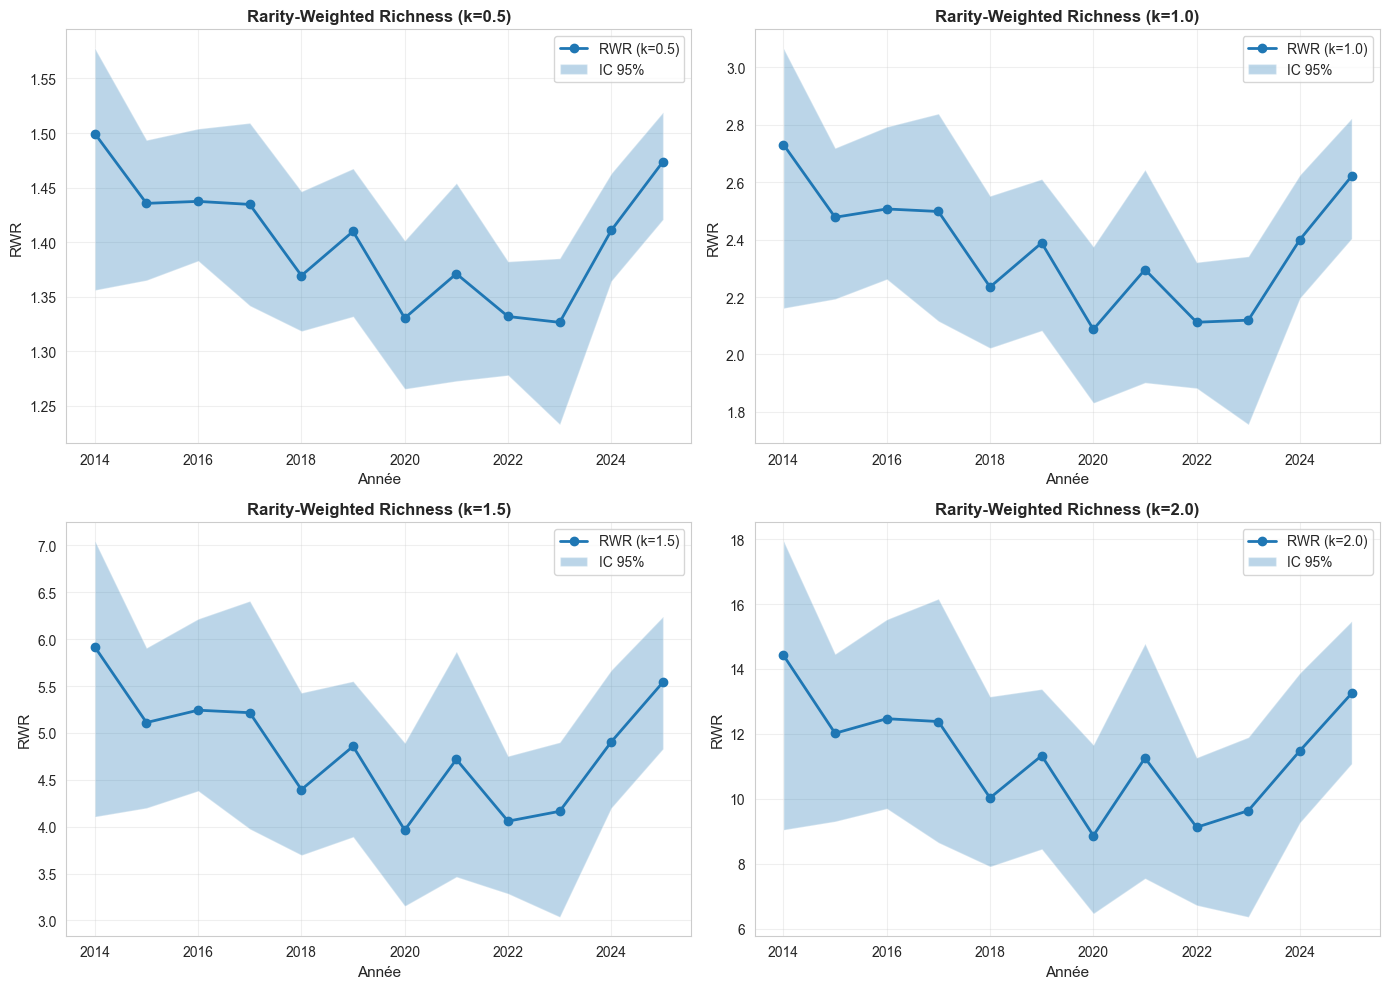


=== RWR Statistics par k ===

k = 0.5:
  Mean RWR: 1.403 ± 0.036
  Range: [1.327, 1.500]

k = 1.0:
  Mean RWR: 2.373 ± 0.148
  Range: [2.087, 2.731]

k = 1.5:
  Mean RWR: 4.841 ± 0.487
  Range: [3.964, 5.917]

k = 2.0:
  Mean RWR: 11.353 ± 1.487
  Range: [8.864, 14.422]


In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, k in enumerate(k_tests):
        ax = axes[i]
        rwr_k = rwr_summary[rwr_summary['k'] == k]
                # Ligne principale
        ax.plot(rwr_k['year'], rwr_k['RWR_mean'], 'o-', 
                linewidth=2, markersize=6, label=f'RWR (k={k})')
                # Intervalle de confiance
        ax.fill_between(
                rwr_k['year'], 
                rwr_k['RWR_q2_5'], 
                rwr_k['RWR_q97_5'], 
                alpha=0.3,
                label='IC 95%'
        )
        ax.set_xlabel('Année', fontsize=11)
        ax.set_ylabel('RWR', fontsize=11)
        ax.set_title(f'Rarity-Weighted Richness (k={k})', fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('rwr_bootstrap_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Stats résumées
print("\n=== RWR Statistics par k ===")
for k in k_tests:
        rwr_k = rwr_summary[rwr_summary['k'] == k]
        print(f"\nk = {k}:")
        print(f"  Mean RWR: {rwr_k['RWR_mean'].mean():.3f} ± {rwr_k['RWR_sd'].mean():.3f}")
        print(f"  Range: [{rwr_k['RWR_mean'].min():.3f}, {rwr_k['RWR_mean'].max():.3f}]")

### Tests Statistiques RWR

In [ ]:
from scipy import stats
# Helper functions for trend analysis
def test_trend(years, values, name="Indicator"):
    """
    Tests statistiques complets sur une tendance temporelle.
    
    Paramètres
    ----------
    years : array-like
        Années d'observation
    values : array-like
        Valeurs de l'indicateur
    name : str
        Nom de l'indicateur (pour affichage)
    
    Retourne
    --------
    dict avec:
        - slope: pente de la régression linéaire (unités/an)
        - r2: coefficient de détermination
        - p_linear: p-value du test de régression
        - p_mk: p-value du test de Mann-Kendall
        - cohens_d: taille d'effet (différence début-fin)
        - trend: 'increasing' ou 'decreasing'
    
    Tests effectués
    ---------------
    1. Régression linéaire: teste si la tendance linéaire est significative
    2. Mann-Kendall: teste si la tendance monotone est significative (non-paramétrique)
    3. Cohen's d: mesure la taille de l'effet (différence standardisée)
    """
    # 1. Régression linéaire
    slope, intercept, r_value, p_value, std_err = stats.linregress(years, values)
    
    # 2. Mann-Kendall (test non-paramétrique pour tendance monotone)
    n = len(values)
    s = sum(np.sign(values[j] - values[i]) for i in range(n-1) for j in range(i+1, n))
    var_s = n * (n - 1) * (2 * n + 5) / 18
    
    if s > 0:
        z = (s - 1) / np.sqrt(var_s)
    elif s < 0:
        z = (s + 1) / np.sqrt(var_s)
    else:
        z = 0
    
    mk_pvalue = 2 * (1 - stats.norm.cdf(abs(z)))
    
    # 3. Effect size (Cohen's d): différence première moitié vs seconde moitié
    mid = len(values) // 2
    mean_first = np.mean(values[:mid])
    mean_second = np.mean(values[mid:])
    pooled_std = np.std(values)
    cohens_d = (mean_second - mean_first) / pooled_std if pooled_std > 0 else 0
    
    return {
        'name': name,
        'slope': slope,
        'r2': r_value**2,
        'p_linear': p_value,
        'p_mk': mk_pvalue,
        'cohens_d': cohens_d,
        'trend': 'increasing' if slope > 0 else 'decreasing'
    }


def print_results(res):
    """
    Affichage formaté des résultats de test_trend.
    
    Interprétation automatique:
    - *** : p < 0.001 (très significatif)
    - **  : p < 0.01  (significatif)
    - *   : p < 0.05  (significatif)
    - ns  : p >= 0.05 (non significatif)
    """
    print(f"\n{'='*70}")
    print(f"  {res['name']}")
    print(f"{'='*70}")
    print(f"  Slope:        {res['slope']:+.6f} units/year")
    print(f"  R²:           {res['r2']:.4f}")
    print(f"  p (linear):   {res['p_linear']:.6f} {'***' if res['p_linear']<0.001 else '**' if res['p_linear']<0.01 else '*' if res['p_linear']<0.05 else 'ns'}")
    print(f"  p (M-K):      {res['p_mk']:.6f} {'***' if res['p_mk']<0.001 else '**' if res['p_mk']<0.01 else '*' if res['p_mk']<0.05 else 'ns'}")
    print(f"  Cohen's d:    {res['cohens_d']:+.4f}")
    
    # Interprétation contextuelle
    if res['p_linear'] < 0.05 and res['p_mk'] < 0.05:
        print(f"\n  Tendance {res['trend']} SIGNIFICATIVE (confirmée par les 2 tests)")
    elif res['p_linear'] < 0.05:
        print(f"\n  ~ Tendance linéaire significative (mais non-monotone selon M-K)")
    elif res['p_mk'] < 0.05:
        print(f"\n  ~ Tendance monotone significative (mais non-linéaire)")
    else:
        print(f"\n  Pas de tendance significative détectée")

In [ ]:
# ============================================================================
# Analyse RWR pour tous les k
# ============================================================================

print("\n" + "="*80)
print("ANALYSE STATISTIQUE - RARITY-WEIGHTED RICHNESS (RWR)")
print("="*80)

k_tests = [0.5, 1.0, 1.5, 2.0]
rwr_results = []

for k in k_tests:
    # Filtrer pour ce k
    df_k = rwr_summary[rwr_summary['k'] == k].sort_values('year')
    
    # Tests statistiques
    res = test_trend(df_k['year'].values, df_k['RWR_mean'].values, f"RWR (k={k})")
    print_results(res)
    rwr_results.append(res)

# Tableau récapitulatif
df_rwr_tests = pd.DataFrame(rwr_results)
print("\n" + "="*80)
print("TABLEAU RÉCAPITULATIF RWR")
print("="*80)
print(df_rwr_tests[['name', 'slope', 'r2', 'p_linear', 'p_mk', 'cohens_d']].to_string(index=False))


ANALYSE STATISTIQUE - RARITY-WEIGHTED RICHNESS (RWR)

  RWR (k=0.5)
  Slope:        -0.006537 units/year
  R²:           0.1698
  p (linear):   0.183238 ns
  p (M-K):      0.114757 ns
  Cohen's d:    -1.0398

  Pas de tendance significative détectée

  RWR (k=1.0)
  Slope:        -0.023327 units/year
  R²:           0.1643
  p (linear):   0.191170 ns
  p (M-K):      0.243722 ns
  Cohen's d:    -1.0078

  Pas de tendance significative détectée

  RWR (k=1.5)
  Slope:        -0.067267 units/year
  R²:           0.1587
  p (linear):   0.199628 ns
  p (M-K):      0.243722 ns
  Cohen's d:    -0.9684

  Pas de tendance significative détectée

  RWR (k=2.0)
  Slope:        -0.184220 units/year
  R²:           0.1533
  p (linear):   0.208123 ns
  p (M-K):      0.243722 ns
  Cohen's d:    -0.9277

  Pas de tendance significative détectée

TABLEAU RÉCAPITULATIF RWR
       name     slope       r2  p_linear     p_mk  cohens_d
RWR (k=0.5) -0.006537 0.169753  0.183238 0.114757 -1.039848
RWR (k=1.0)

Il n'y a pas de tendance linéaire significative !

#####

Est-ce à cause de 
- Le bootstrap n'a-t-il pas résolu le pronlème ?
- Y'a-t-il trop de bruit dans les données et la tendance est super bien cachée ?
- l'inexistence d'une tendance ? 

In [ ]:
# =============================================================================
# VALIDATION: RWR vs EFFORT D'ÉCHANTILLONNAGE
# =============================================================================

def validate_bootstrap_correction(df_bio, rwr_summary, k=2.0):
    """
    FONCTION CRUCIALE: Valide que le bootstrap corrige bien le biais d'effort.
    
    Cette fonction vérifie si le RWR bootstrap est corrélé à l'effort 
    d'échantillonnage réel. Une corrélation forte indiquerait que le bootstrap
    n'a pas éliminé le biais.
    
    Tests effectués:
    1. Corrélation RWR vs Nombre de points
    2. Corrélation RWR vs Richesse spécifique
    3. Corrélation RWR vs Abondance totale
    4. Visualisation des relations
    
    Interprétation:
    - |r| < 0.3 avec RWR vs Points → Bootstrap efficace
    - |r| > 0.6 avec RWR vs Points → Bootstrap inefficace
    """
    print("\n" + "="*80)
    print("VALIDATION: RWR vs EFFORT D'ÉCHANTILLONNAGE RÉEL")
    print("="*80)
    
    # Calculer le VRAI effort d'échantillonnage (données brutes)
    print("\nCalcul de l'effort réel par année (avant bootstrap):")
    
    effort_real = df_bio.groupby('year').agg({
        'point': 'nunique',
        'species': 'nunique',
        'count': 'sum'
    }).reset_index()
    effort_real.columns = ['year', 'n_points_real', 'n_species', 'total_abundance']
    
    print("\n" + effort_real.to_string(index=False))
    
    # Statistiques sur l'effort
    #print(f"\n2. Statistiques d'effort:")
    #print(f"   Min points: {effort_real['n_points_real'].min()}")
    #print(f"   Max points: {effort_real['n_points_real'].max()}")
    #print(f"   Moyenne: {effort_real['n_points_real'].mean():.1f}")
    #print(f"   Écart-type: {effort_real['n_points_real'].std():.2f}")
    #print(f"   Coefficient de variation: {effort_real['n_points_real'].std() / effort_real['n_points_real'].mean() * 100:.1f}%")
    
    if effort_real['n_points_real'].nunique() == 1:
        print("\n   Effort VRAIMENT constant (même nombre de points chaque année)")
        print("     → Protocole standardisé, pas de biais temporel")
        print("     → Bootstrap non nécessaire (mais donne quand même des IC utiles)")
    else:
        print(f"\n  Effort variable ({effort_real['n_points_real'].nunique()} valeurs distinctes)")
        print("     → Bootstrap nécessaire pour corriger le biais")
    
    # Merger avec RWR
    df_k = rwr_summary[rwr_summary['k'] == k].sort_values('year')
    df_check = df_k[['year', 'RWR_mean', 'RWR_sd']].merge(effort_real, on='year')
    
    print(f"\nDonnées combinées (RWR k={k}):")
    print(df_check[['year', 'n_points_real', 'n_species', 'RWR_mean']].to_string(index=False))
    
    # CORRÉLATIONS
    print("\n" + "="*70)
    print("CORRÉLATIONS CRITIQUES")
    print("="*70)
    
    # RWR vs nombre de points RÉELS
    if df_check['n_points_real'].std() > 0 and df_check['RWR_mean'].std() > 0:
        corr_points, p_points = stats.pearsonr(df_check['n_points_real'], df_check['RWR_mean'])
        print(f"\n✦ RWR vs Nombre de points (RÉELS):")
        print(f"  Corrélation: r = {corr_points:+.3f}, p = {p_points:.4f}")
        
        if abs(corr_points) > 0.6 and p_points < 0.05:
            print(" PROBLÈME MAJEUR: Forte corrélation - RWR biaisé par l'effort")
            print("     → Le bootstrap n'a PAS éliminé le biais")
            print("     → Recommandations:")
            print("       1. Augmenter n_boot (500 → 1000+)")
            print("       2. Réduire sample_fraction (0.8 → 0.6-0.7)")
            print("       3. Utiliser raréfaction au lieu de bootstrap")
        elif abs(corr_points) > 0.4 and p_points < 0.05:
            print(" Corrélation modérée - biais résiduel possible")
            print("     → Bootstrap partiellement efficace")
            print("     → Considérer ajustements (plus de bootstrap, moins de sample_fraction)")
        elif abs(corr_points) > 0.3:
            print("  ~ Corrélation faible mais détectable")
            print("     → Bootstrap globalement efficace, biais mineur résiduel")
        else:
            print("Pas de corrélation significative")
            print("    → Bootstrap EFFICACE")
            print("    → RWR ne mesure pas l'effort, mais la biodiversité réelle!")
    else:
        print("\nRWR vs Nombre de points:")
        print("  Variable constante (effort identique chaque année)")
        print(" Protocole parfaitement standardisé")
    
    # RWR vs richesse
    if df_check['n_species'].std() > 0:
        corr_species, p_species = stats.pearsonr(df_check['n_species'], df_check['RWR_mean'])
        print(f"\nRWR vs Richesse spécifique:")
        print(f"  Corrélation: r = {corr_species:+.3f}, p = {p_species:.4f}")
        
        if abs(corr_species) > 0.7 and p_species < 0.05:
            print("  → Forte corrélation (attendue: RWR dépend de la richesse)")
        elif abs(corr_species) < 0.3:
            print("  → Faible corrélation (RWR capture info orthogonale)")
    
    # RWR vs abondance
    if df_check['total_abundance'].std() > 0:
        corr_abundance, p_abundance = stats.pearsonr(df_check['total_abundance'], df_check['RWR_mean'])
        print(f"\n✦ RWR vs Abondance totale:")
        print(f"  Corrélation: r = {corr_abundance:+.3f}, p = {p_abundance:.4f}")
        
        if abs(corr_abundance) > 0.5 and p_abundance < 0.05:
            if corr_abundance < 0:
                print("  → Corrélation NÉGATIVE significative")
                print("     Interprétation: Années à forte abondance = dominance espèces communes")
            else:
                print("  → Corrélation POSITIVE significative")
                print("     Interprétation: Plus d'oiseaux = plus d'espèces rares détectées")
    
    # VISUALISATION COMPLÈTE
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. RWR vs Points RÉELS
    ax = axes[0, 0]
    if df_check['n_points_real'].nunique() > 1:
        ax.scatter(df_check['n_points_real'], df_check['RWR_mean'], s=150, alpha=0.7, color='steelblue')
        for _, row in df_check.iterrows():
            ax.annotate(int(row['year']), 
                        (row['n_points_real'], row['RWR_mean']), 
                        fontsize=9, ha='center', xytext=(0, 7), textcoords='offset points')
        
        # Régression si corrélation
        if 'corr_points' in locals() and abs(corr_points) > 0.3:
            z = np.polyfit(df_check['n_points_real'], df_check['RWR_mean'], 1)
            p_poly = np.poly1d(z)
            x_line = np.linspace(df_check['n_points_real'].min(), df_check['n_points_real'].max(), 100)
            ax.plot(x_line, p_poly(x_line), "r--", linewidth=2, alpha=0.7)
        
        try:
            sig = '***' if p_points < 0.001 else '**' if p_points < 0.01 else '*' if p_points < 0.05 else 'ns'
            ax.set_title(f'RWR vs Sampling Points\nr={corr_points:.3f}, p={p_points:.4f} {sig}', 
                        fontsize=12, fontweight='bold' if p_points < 0.05 else 'normal')
        except:
            ax.set_title('RWR vs Sampling Points', fontsize=12)
    else:
        ax.text(0.5, 0.5, f"Constant sampling effort\n(n={df_check['n_points_real'].iloc[0]} points/year)", 
                transform=ax.transAxes, ha='center', va='center',
                fontsize=12, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
        ax.set_title('Standardized Protocol ✓', fontsize=12, fontweight='bold')
    
    ax.set_xlabel('Number of sampling points', fontsize=11)
    ax.set_ylabel(f'RWR (k={k})', fontsize=11)
    ax.grid(alpha=0.3)
    
    # 2. RWR vs Richesse
    ax = axes[0, 1]
    ax.scatter(df_check['n_species'], df_check['RWR_mean'], s=150, alpha=0.7, color='green')
    for _, row in df_check.iterrows():
        ax.annotate(int(row['year']), 
                    (row['n_species'], row['RWR_mean']), 
                    fontsize=9, ha='center', xytext=(0, 7), textcoords='offset points')
    ax.set_xlabel('Species richness', fontsize=11)
    ax.set_ylabel(f'RWR (k={k})', fontsize=11)
    try:
        sig = '***' if p_species < 0.001 else '**' if p_species < 0.01 else '*' if p_species < 0.05 else 'ns'
        ax.set_title(f'RWR vs Richness\nr={corr_species:.3f}, p={p_species:.4f} {sig}', fontsize=12)
    except:
        ax.set_title('RWR vs Richness', fontsize=12)
    ax.grid(alpha=0.3)
    
    # 3. RWR vs Abondance
    ax = axes[1, 0]
    ax.scatter(df_check['total_abundance'], df_check['RWR_mean'], s=150, alpha=0.7, color='orange')
    for _, row in df_check.iterrows():
        ax.annotate(int(row['year']), 
                    (row['total_abundance'], row['RWR_mean']), 
                    fontsize=9, ha='center', xytext=(0, 7), textcoords='offset points')
    
    # Régression si corrélation
    try:
        if abs(corr_abundance) > 0.3:
            z = np.polyfit(df_check['total_abundance'], df_check['RWR_mean'], 1)
            p_poly = np.poly1d(z)
            x_line = np.linspace(df_check['total_abundance'].min(), df_check['total_abundance'].max(), 100)
            ax.plot(x_line, p_poly(x_line), "r--", linewidth=2, alpha=0.7)
    except:
        pass
    
    ax.set_xlabel('Total abundance (individuals)', fontsize=11)
    ax.set_ylabel(f'RWR (k={k})', fontsize=11)
    try:
        sig = '***' if p_abundance < 0.001 else '**' if p_abundance < 0.01 else '*' if p_abundance < 0.05 else 'ns'
        ax.set_title(f'RWR vs Abundance\nr={corr_abundance:.3f}, p={p_abundance:.4f} {sig}', 
                    fontsize=12, fontweight='bold' if p_abundance < 0.05 else 'normal')
    except:
        ax.set_title('RWR vs Abundance', fontsize=12)
    ax.grid(alpha=0.3)
    
    # 4. Évolution temporelle double axe
    ax = axes[1, 1]
    ax2 = ax.twinx()
    
    if df_check['n_points_real'].nunique() > 1:
        ax.plot(df_check['year'], df_check['n_points_real'], 'o-', 
                color='blue', linewidth=2, markersize=7, label='Sampling points')
        ax.set_ylabel('Number of points', fontsize=11, color='blue')
        ax.tick_params(axis='y', labelcolor='blue')
    else:
        ax.axhline(df_check['n_points_real'].iloc[0], color='blue', linestyle='--', 
                linewidth=2, alpha=0.5, label='Constant effort')
        ax.set_ylabel('Number of points (constant)', fontsize=11, color='blue')
    
    ax2.plot(df_check['year'], df_check['RWR_mean'], 's-', 
            color='red', linewidth=2, markersize=7, label='RWR')
    ax2.fill_between(df_check['year'], 
                    df_check['RWR_mean'] - df_check['RWR_sd'],
                    df_check['RWR_mean'] + df_check['RWR_sd'],
                    alpha=0.3, color='red')
    
    ax.set_xlabel('Year', fontsize=11)
    ax2.set_ylabel(f'RWR (k={k})', fontsize=11, color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax.set_title('Temporal Evolution: Effort vs RWR', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
    
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    print("="*80 + "\n")

In [ ]:
# =============================================================================
# LISSAGE TEMPOREL
# =============================================================================

def smooth_rwr_trends(rwr_summary, k=2.0, window_size=3):
    """
    Applique un lissage temporel pour révéler les tendances sous-jacentes.
    
    Utile quand le signal est bruité mais qu'une tendance existe.
    
    Paramètres
    ----------
    rwr_summary : DataFrame
        Résultats du bootstrap
    k : float
        Valeur de k à analyser
    window_size : int
        Taille de la fenêtre de lissage (3 = moyenne mobile sur 3 ans)
    """
    print("\n" + "="*80)
    print(f"LISSAGE TEMPOREL: Moyenne mobile sur {window_size} ans")
    print("="*80)
    
    df_k = rwr_summary[rwr_summary['k'] == k].sort_values('year')
    years = df_k['year'].values
    rwr = df_k['RWR_mean'].values
    
    # Moyenne mobile
    rwr_smoothed = uniform_filter1d(rwr, size=window_size)
    
    # Visualisation
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # RWR brut
    ax.plot(years, rwr, 'o-', alpha=0.5, label='RWR observed', markersize=6, color='gray')
    
    # RWR lissé
    ax.plot(years, rwr_smoothed, linewidth=3, label=f'{window_size}-year moving average', 
            color='red', marker='s', markersize=7)
    
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel(f'RWR (k={k})', fontsize=12)
    ax.set_title(f'RWR with Temporal Smoothing (k={k})', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Test sur données lissées
    res_smoothed = test_trend(years, rwr_smoothed, f"RWR smoothed (k={k})")
    print_results(res_smoothed)
    
    if res_smoothed['p_linear'] < 0.05:
        print("\n✓ Une tendance significative émerge après lissage!")
        print("  → Le signal était masqué par la variabilité inter-annuelle")
    else:
        print("\n✗ Pas de tendance significative même après lissage")
        print("  → Confirme l'absence de tendance long-terme")
    

In [ ]:
# =============================================================================
# DIAGNOSTIC DE NON-SIGNIFICATIVITÉ
# =============================================================================

def diagnose_rwr_variability(rwr_summary, k_values=[0.5, 1.0, 1.5, 2.0]):
    """
    Diagnostic pour comprendre pourquoi RWR n'est pas significatif.
    
    Calcule des métriques de variabilité:
    - Coefficient de variation (CV)
    - Range (étendue min-max)
    - Nombre d'années en hausse vs baisse
    - Pattern général
    
    Visualise RWR avec intervalles de confiance.
    """
    print("\n" + "="*80)
    print("DIAGNOSTIC: ANALYSE DE LA NON-SIGNIFICATIVITÉ DU RWR")
    print("="*80)
    
    for k in k_values:
        df_k = rwr_summary[rwr_summary['k'] == k].sort_values('year')
        years = df_k['year'].values
        rwr = df_k['RWR_mean'].values
        
        # Calculer quelques métriques
        changes = np.diff(rwr)
        n_increases = np.sum(changes > 0)
        n_decreases = np.sum(changes < 0)
        
        # Coefficient de variation
        cv = np.std(rwr) / np.mean(rwr) * 100
        
        # Range
        rwr_range = rwr.max() - rwr.min()
        rwr_range_pct = (rwr_range / rwr.mean()) * 100
        
        print(f"\nRWR (k={k}):")
        print(f"  Valeur moyenne:        {rwr.mean():.3f}")
        print(f"  Min → Max:             {rwr.min():.3f} → {rwr.max():.3f}")
        print(f"  Range:                 {rwr_range:.3f} ({rwr_range_pct:.1f}% de la moyenne)")
        print(f"  Coef. variation:       {cv:.1f}%")
        print(f"  Années en hausse:      {n_increases}/{len(changes)}")
        print(f"  Années en baisse:      {n_decreases}/{len(changes)}")
        print(f"  Plus forte variation:  {np.abs(changes).max():.3f}")
        
        # Pattern visuel
        if n_increases > len(changes) * 0.65:
            pattern = "Tendance haussière dominante"
        elif n_decreases > len(changes) * 0.65:
            pattern = "Tendance baissière dominante"
        else:
            pattern = "Pattern fluctuant (pas de direction claire)"
        print(f"  Pattern:               {pattern}")
    
    # Visualisation comparative
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    for i, k in enumerate(k_values):
        ax = axes[i//2, i%2]
        df_k = rwr_summary[rwr_summary['k'] == k].sort_values('year')
        
        years = df_k['year'].values
        rwr = df_k['RWR_mean'].values
        ci_lower = df_k['RWR_q2_5'].values
        ci_upper = df_k['RWR_q97_5'].values
        
        # Plot
        ax.plot(years, rwr, 'o-', linewidth=2, markersize=8, color='darkblue', label='RWR mean')
        ax.fill_between(years, ci_lower, ci_upper, alpha=0.3, color='lightblue', label='95% CI')
        
        # Régression linéaire
        z = np.polyfit(years, rwr, 1)
        p = np.poly1d(z)
        ax.plot(years, p(years), "--", color='red', linewidth=2, alpha=0.7, label='Linear trend')
        
        ax.set_xlabel('Year', fontsize=12)
        ax.set_ylabel(f'RWR (k={k})', fontsize=12)
        ax.set_title(f'RWR Evolution for k={k}', fontsize=13, fontweight='bold')
        ax.legend()
        ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    


In [ ]:
# =============================================================================
# VISUALISATION COMPARATIVE MULTI-K
# =============================================================================

def plot_rwr_comparison(rwr_summary, k_values=[0.5, 1.0, 1.5, 2.0]):
    """
    Visualisation comparative du RWR pour différentes valeurs de k.
    
    Permet de voir l'impact du paramètre k sur:
    - Les valeurs absolues
    - Les tendances temporelles
    - La variabilité (largeur des IC)
    """
    fig, ax = plt.subplots(figsize=(14, 8))
    
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(k_values)))
    
    for i, k in enumerate(k_values):
        df_k = rwr_summary[rwr_summary['k'] == k].sort_values('year')
        
        ax.plot(df_k['year'], df_k['RWR_mean'], 'o-', 
                linewidth=2.5, markersize=8, label=f'k={k}', color=colors[i])
        
        ax.fill_between(df_k['year'], 
                        df_k['RWR_q2_5'], 
                        df_k['RWR_q97_5'],
                        alpha=0.2, color=colors[i])
    
    ax.set_xlabel('Year', fontsize=13)
    ax.set_ylabel('RWR (bootstrap mean)', fontsize=13)
    ax.set_title('Rarity-Weighted Richness: Comparison of k values', 
                fontsize=15, fontweight='bold')
    ax.legend(fontsize=11, loc='best')
    ax.grid(alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    

In [ ]:
def analyze_rwr_trends(rwr_summary, k_values=[0.5, 1.0, 1.5, 2.0]):
    """
    Analyse statistique complète des tendances RWR pour chaque k.
    
    Pour chaque valeur de k:
    1. Test de régression linéaire
    2. Test de Mann-Kendall
    3. Calcul de la taille d'effet (Cohen's d)
    4. Affichage des résultats
    
    Retourne un DataFrame récapitulatif.
    """
    print("\n" + "="*80)
    print("ANALYSE STATISTIQUE - RARITY-WEIGHTED RICHNESS (RWR)")
    print("="*80)
    
    rwr_results = []
    
    for k in k_values:
        # Filtrer pour ce k
        df_k = rwr_summary[rwr_summary['k'] == k].sort_values('year')
        
        # Tests statistiques
        res = test_trend(df_k['year'].values, df_k['RWR_mean'].values, f"RWR (k={k})")
        print_results(res)
        rwr_results.append(res)
    
    # Tableau récapitulatif
    df_rwr_tests = pd.DataFrame(rwr_results)
    print("\n" + "="*80)
    print("TABLEAU RÉCAPITULATIF RWR")
    print("="*80)
    print(df_rwr_tests[['name', 'slope', 'r2', 'p_linear', 'p_mk', 'cohens_d']].to_string(index=False))
    
    # Recommandation du meilleur k
    print("\n" + "="*80)
    print("RECOMMANDATION")
    print("="*80)
    
    # Critères: p-value la plus faible + R² le plus élevé
    df_rwr_tests['score'] = df_rwr_tests['r2'] * (1 - df_rwr_tests['p_linear'])
    best_k_idx = df_rwr_tests['score'].idxmax()
    best_k = k_values[best_k_idx]
    
    print(f"\nMeilleur k (selon score R² × (1-p)): k = {best_k}")
    print(f"  R² = {df_rwr_tests.loc[best_k_idx, 'r2']:.4f}")
    print(f"  p-value = {df_rwr_tests.loc[best_k_idx, 'p_linear']:.6f}")
    
    if df_rwr_tests.loc[best_k_idx, 'p_linear'] >= 0.05:
        print(f"\n⚠ Attention: Même le meilleur k n'est pas significatif (p ≥ 0.05)")
        print(f"  Cela suggère une vraie absence de tendance ou un fort bruit dans les données.")
    
    return df_rwr_tests

In [ ]:
# Helper function
def run_complete_rwr_analysis(df_bio, k_values=[0.5, 1.0, 1.5, 2.0], 
                            n_boot=500, sample_fraction=0.8):
    """
    Pipeline complet d'analyse RWR:
    
    1. Bootstrap RWR pour tous les k
    2. Analyse statistique des tendances
    3. Diagnostic de variabilité
    4. Lissage temporel
    5. Validation effort d'échantillonnage
    6. Visualisations comparatives
    
    Retourne le résumé bootstrap et les résultats des tests.
    """
    print("\n" + "="*80)
    print("PIPELINE COMPLET: ANALYSE RWR AVEC BOOTSTRAP")
    print("="*80)
    
    
    # 2. Analyse statistique
    print("2. Analyse statistique des tendances")
    df_tests = analyze_rwr_trends(rwr_summary, k_values)
    
    # 3. Diagnostic
    print("3. Diagnostic de la variabilité du RWR")
    diagnose_rwr_variability(rwr_summary, k_values)
    
    # 4. Lissage (sur le meilleur k)
    print("4. Lissage temporel pour révéler les tendances")
    best_k = k_values[df_tests['r2'].idxmax()]
    smooth_rwr_trends(rwr_summary, k=best_k, window_size=3)
    
    # 5. Validation bootstrap
    print("5. Validation de la correction bootstrap de l'effort d'échantillonnage")
    validate_bootstrap_correction(df_bio, rwr_summary, k=best_k)
    
    # 6. Comparaison visuelle
    print("6. Visualisation comparative des RWR pour différents k")
    plot_rwr_comparison(rwr_summary, k_values)
    
    print("\n" + "="*80)
    print("ANALYSE TERMINÉE")
    print("="*80)
    
    return rwr_summary, df_tests



PIPELINE COMPLET: ANALYSE RWR AVEC BOOTSTRAP
2. Analyse statistique des tendances

ANALYSE STATISTIQUE - RARITY-WEIGHTED RICHNESS (RWR)

  RWR (k=0.5)
  Slope:        -0.006537 units/year
  R²:           0.1698
  p (linear):   0.183238 ns
  p (M-K):      0.114757 ns
  Cohen's d:    -1.0398

  Pas de tendance significative détectée

  RWR (k=1.0)
  Slope:        -0.023327 units/year
  R²:           0.1643
  p (linear):   0.191170 ns
  p (M-K):      0.243722 ns
  Cohen's d:    -1.0078

  Pas de tendance significative détectée

  RWR (k=1.5)
  Slope:        -0.067267 units/year
  R²:           0.1587
  p (linear):   0.199628 ns
  p (M-K):      0.243722 ns
  Cohen's d:    -0.9684

  Pas de tendance significative détectée

  RWR (k=2.0)
  Slope:        -0.184220 units/year
  R²:           0.1533
  p (linear):   0.208123 ns
  p (M-K):      0.243722 ns
  Cohen's d:    -0.9277

  Pas de tendance significative détectée

TABLEAU RÉCAPITULATIF RWR
       name     slope       r2  p_linear     p_m

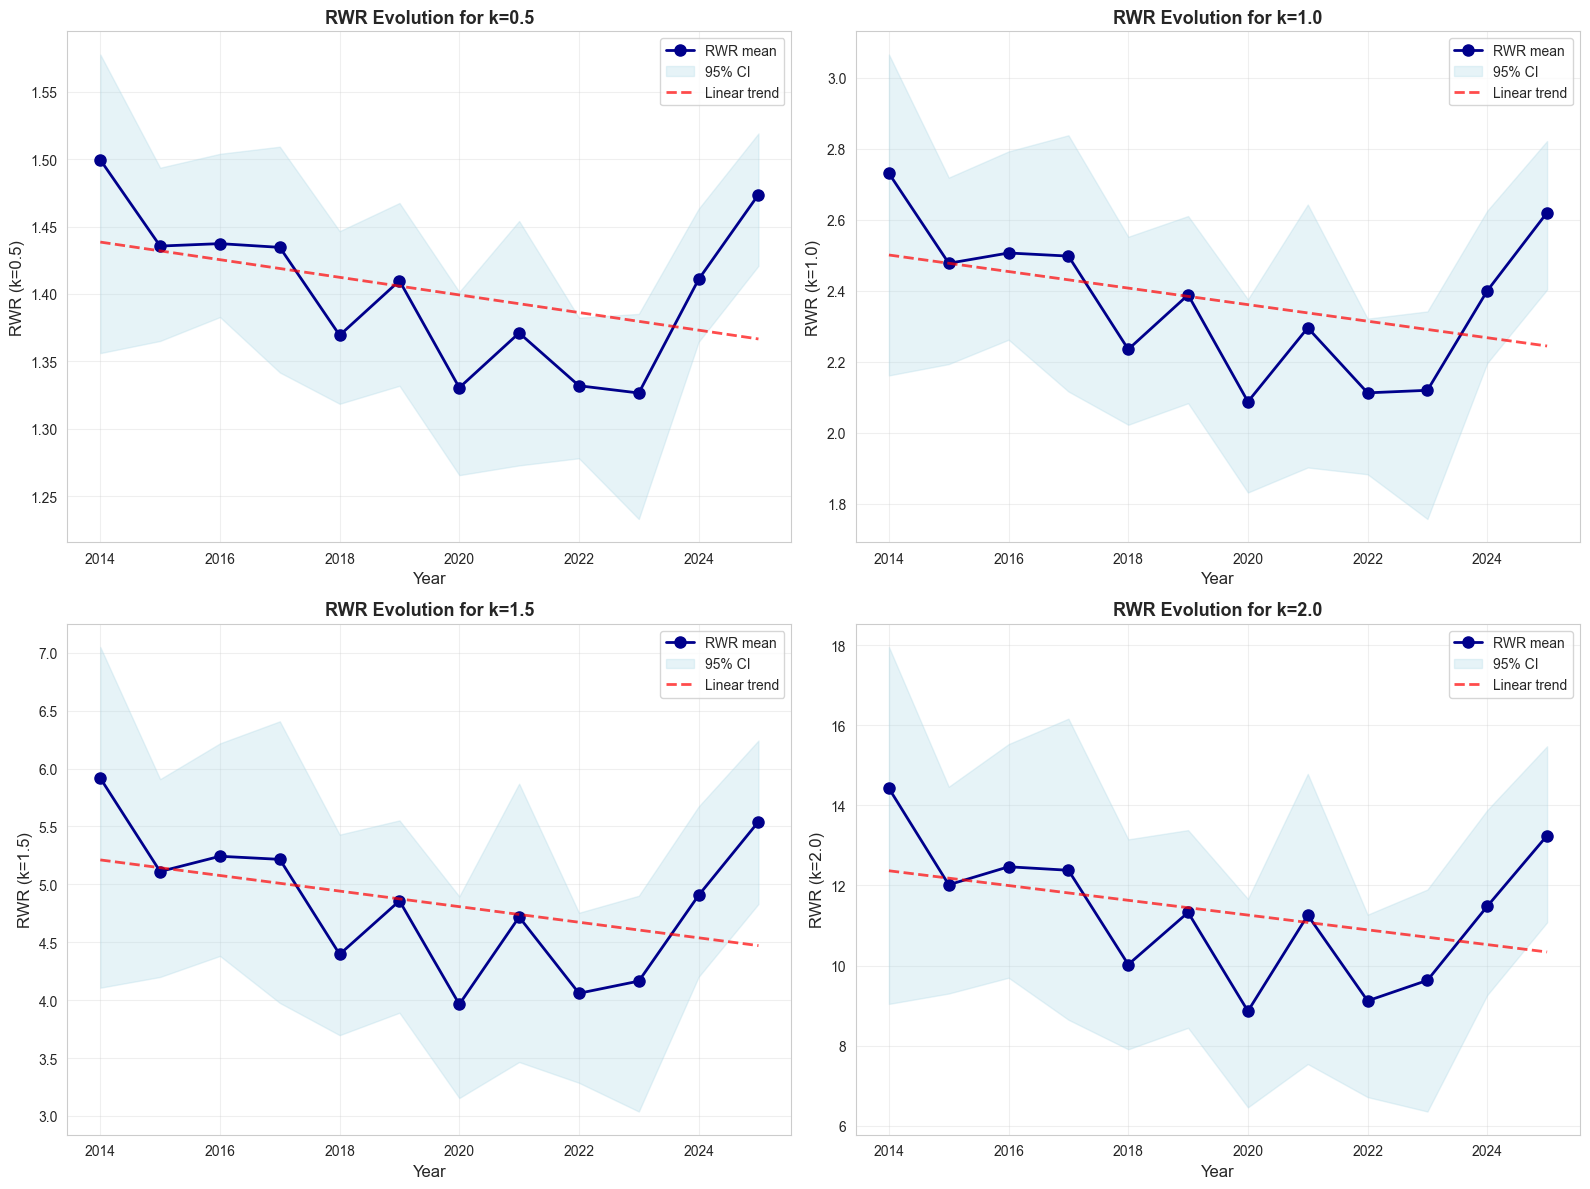

4. Lissage temporel pour révéler les tendances

LISSAGE TEMPOREL: Moyenne mobile sur 3 ans


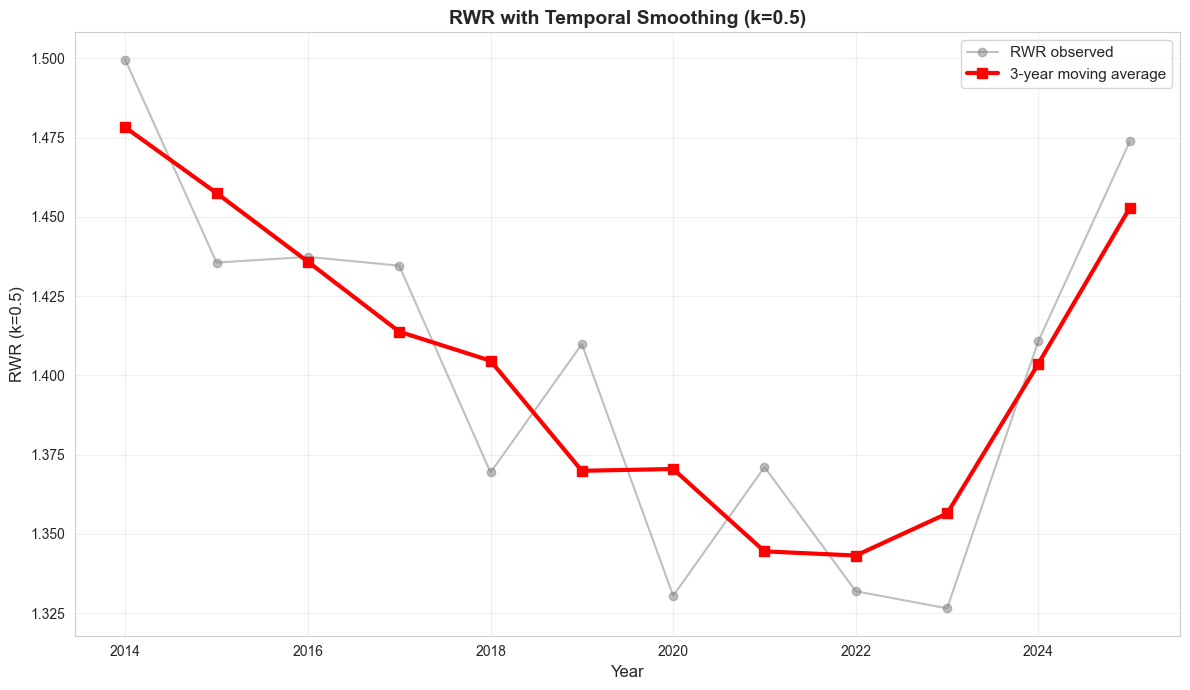


  RWR smoothed (k=0.5)
  Slope:        -0.006476 units/year
  R²:           0.2538
  p (linear):   0.094924 ns
  p (M-K):      0.033524 *
  Cohen's d:    -1.0845

  ~ Tendance monotone significative (mais non-linéaire)

✗ Pas de tendance significative même après lissage
  → Confirme l'absence de tendance long-terme
5. Validation de la correction bootstrap de l'effort d'échantillonnage

VALIDATION: RWR vs EFFORT D'ÉCHANTILLONNAGE RÉEL

Calcul de l'effort réel par année (avant bootstrap):

 year  n_points_real  n_species  total_abundance
 2014             10         60          11113.0
 2015             10         65          17530.0
 2016             10         67          23097.0
 2017             10         64          20557.0
 2018             10         65          20701.0
 2019             10         65          21383.0
 2020             10         66          22750.0
 2021             10         65          24644.0
 2022             10         63          25127.0
 2023           

C:\Users\AMINE\AppData\Local\Temp\ipykernel_24952\3172921832.py:231: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from current font.
  plt.tight_layout()
C:\Users\AMINE\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


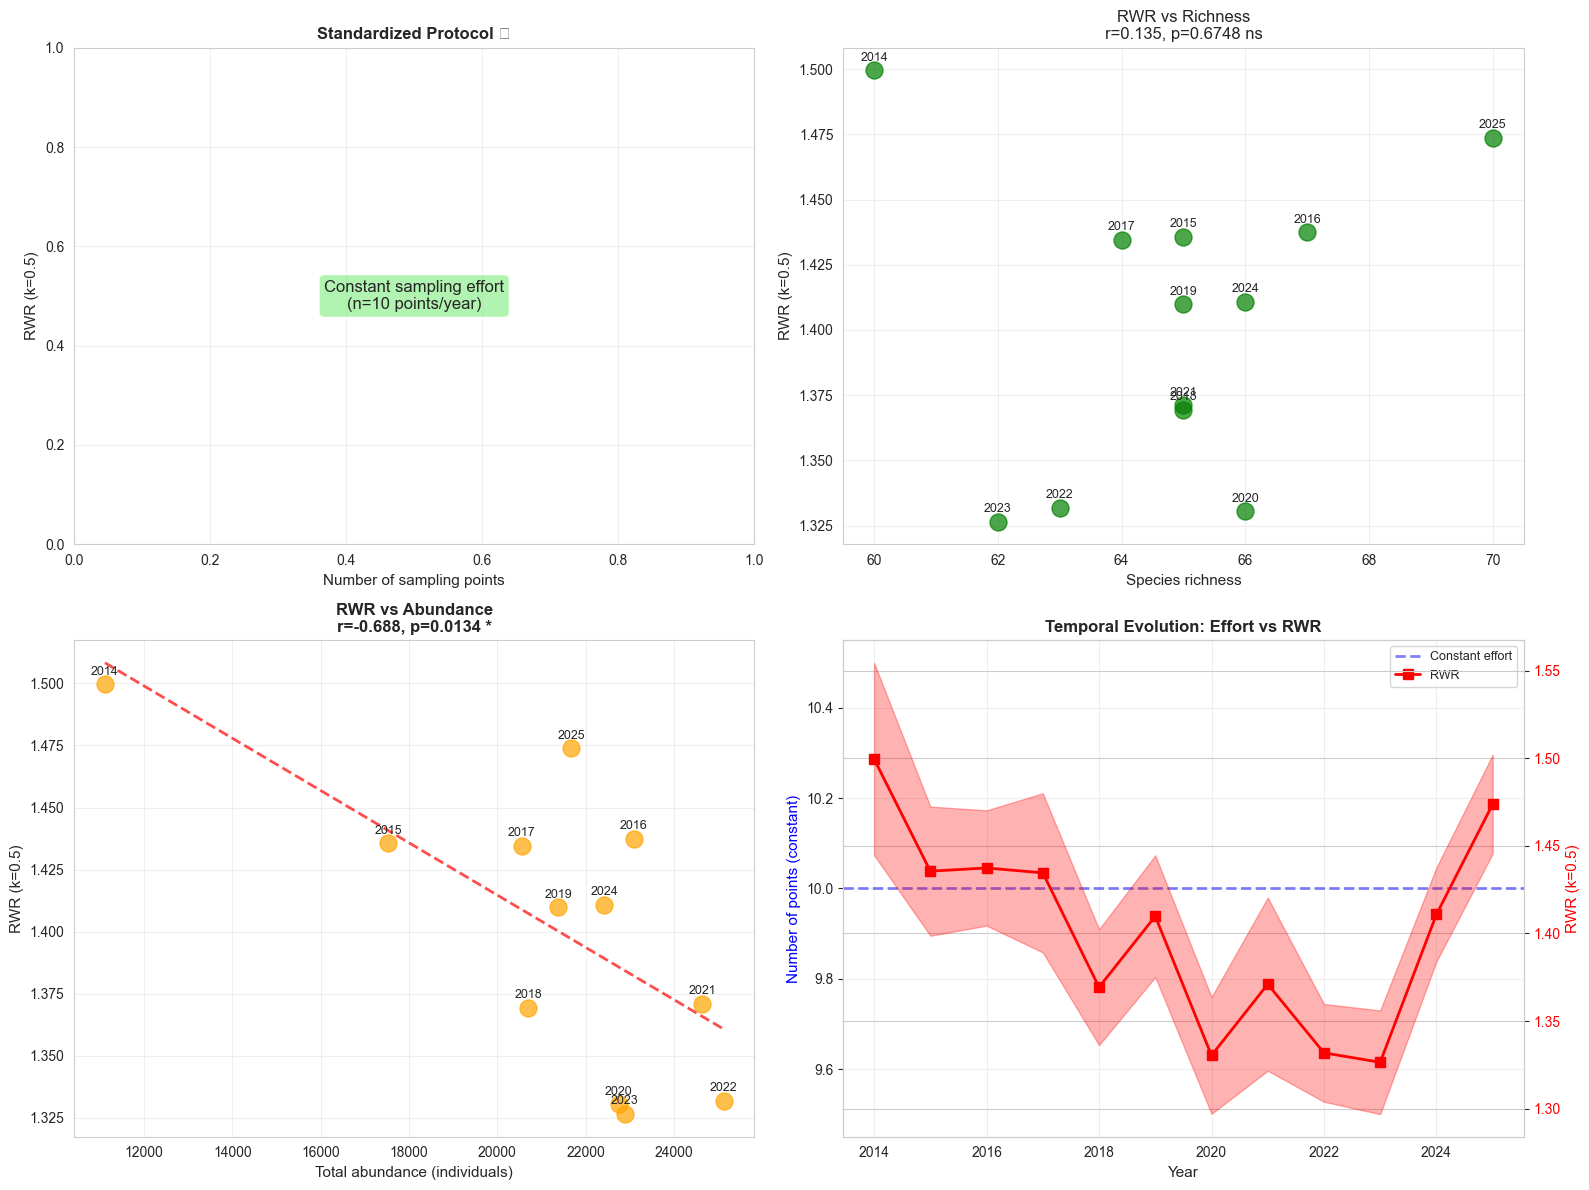


6. Visualisation comparative des RWR pour différents k


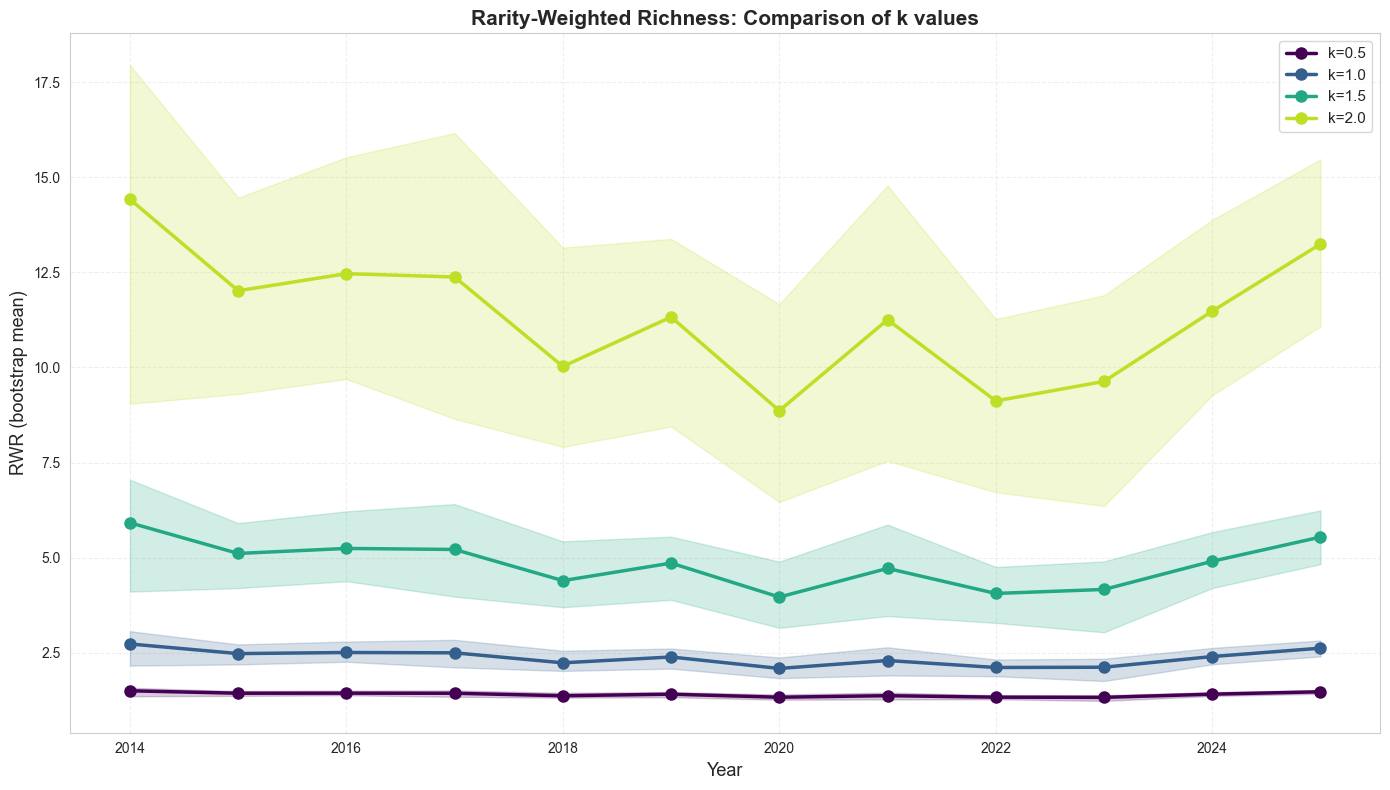


ANALYSE TERMINÉE


In [ ]:
rwr_summary, test_results = run_complete_rwr_analysis(
        df_bio, 
        k_values=[0.5, 1.0, 1.5, 2.0],
        n_boot=500,
        sample_fraction=0.8
    )

## ANALYSE DE TENDANCE NON-LINÉAIRE POUR RWR


In [ ]:
from scipy.optimize import curve_fit
#import warnings
#warnings.filterwarnings('ignore')


# =============================================================================
# ANALYSE PAR PÉRIODES (BREAKPOINT)
# =============================================================================

def analyze_by_periods(df_k, breakpoint_year=2022):
    """
    Analyse la tendance en divisant en 2 périodes avant/après un point de rupture.
    
    Paramètres
    ----------
    df_k : DataFrame
        Données RWR pour un k donné (colonnes: year, RWR_mean)
    breakpoint_year : int
        Année de rupture (par défaut 2022)
    
    Retourne
    --------
    dict avec résultats pour période 1, période 2, et test de différence
    """
    print("\n" + "="*80)
    print(f"ANALYSE PAR PÉRIODES (Point de rupture: {breakpoint_year})")
    print("="*80)
    
    # Diviser les données
    period1 = df_k[df_k['year'] <= breakpoint_year].copy()
    period2 = df_k[df_k['year'] > breakpoint_year].copy()
    
    print(f"\nPériode 1: {period1['year'].min()}-{breakpoint_year} ({len(period1)} années)")
    print(f"Période 2: {breakpoint_year+1}-{period2['year'].max()} ({len(period2)} années)")
    
    # Test sur période 1
    if len(period1) >= 3:
        slope1, intercept1, r1, p1, se1 = stats.linregress(period1['year'], period1['RWR_mean'])
        print(f"\n{'Période 1':<20} {period1['year'].min()}-{breakpoint_year}")
        print(f"  Pente:          {slope1:+.4f} unités/an")
        print(f"  R²:             {r1**2:.4f}")
        print(f"  p-value:        {p1:.6f} {'***' if p1<0.001 else '**' if p1<0.01 else '*' if p1<0.05 else 'ns'}")
        print(f"  Variation:      {period1['RWR_mean'].iloc[0]:.2f} → {period1['RWR_mean'].iloc[-1]:.2f} ({((period1['RWR_mean'].iloc[-1]/period1['RWR_mean'].iloc[0])-1)*100:+.1f}%)")
        
        if p1 < 0.05:
            trend1 = "BAISSIÈRE" if slope1 < 0 else "HAUSSIÈRE"
            print(f"  → Tendance {trend1} SIGNIFICATIVE")
        else:
            print(f"  → Pas de tendance significative")
    else:
        print(f"\nPériode 1: Pas assez de données ({len(period1)} années)")
        slope1, p1 = None, None
    
    # Test sur période 2
    if len(period2) >= 3:
        slope2, intercept2, r2, p2, se2 = stats.linregress(period2['year'], period2['RWR_mean'])
        print(f"\n{'Période 2':<20} {breakpoint_year+1}-{period2['year'].max()}")
        print(f"  Pente:          {slope2:+.4f} unités/an")
        print(f"  R²:             {r2**2:.4f}")
        print(f"  p-value:        {p2:.6f} {'***' if p2<0.001 else '**' if p2<0.01 else '*' if p2<0.05 else 'ns'}")
        print(f"  Variation:      {period2['RWR_mean'].iloc[0]:.2f} → {period2['RWR_mean'].iloc[-1]:.2f} ({((period2['RWR_mean'].iloc[-1]/period2['RWR_mean'].iloc[0])-1)*100:+.1f}%)")
        
        if p2 < 0.05:
            trend2 = "BAISSIÈRE" if slope2 < 0 else "HAUSSIÈRE"
            print(f"  → Tendance {trend2} SIGNIFICATIVE")
        else:
            print(f"  → Pas de tendance significative")
    else:
        print(f"\nPériode 2: Pas assez de données ({len(period2)} années)")
        slope2, p2 = None, None
    
    # Test de différence entre périodes (t-test)
    if len(period1) >= 2 and len(period2) >= 2:
        t_stat, p_diff = stats.ttest_ind(period1['RWR_mean'], period2['RWR_mean'])
        print(f"\n{'Test de différence':<20}")
        print(f"  Moyenne P1:     {period1['RWR_mean'].mean():.2f}")
        print(f"  Moyenne P2:     {period2['RWR_mean'].mean():.2f}")
        print(f"  Différence:     {period2['RWR_mean'].mean() - period1['RWR_mean'].mean():+.2f} ({((period2['RWR_mean'].mean()/period1['RWR_mean'].mean())-1)*100:+.1f}%)")
        print(f"  t-statistic:    {t_stat:+.3f}")
        print(f"  p-value:        {p_diff:.6f} {'***' if p_diff<0.001 else '**' if p_diff<0.01 else '*' if p_diff<0.05 else 'ns'}")
        
        if p_diff < 0.05:
            if period2['RWR_mean'].mean() > period1['RWR_mean'].mean():
                print(f"  → Période 2 SIGNIFICATIVEMENT PLUS ÉLEVÉE")
            else:
                print(f"  → Période 2 SIGNIFICATIVEMENT PLUS BASSE")
    
    # Interprétation globale
    print(f"\n{'INTERPRÉTATION':<20}")
    if slope1 is not None and slope2 is not None:
        if slope1 < 0 and p1 < 0.05 and slope2 > 0 and p2 < 0.05:
            print(" Pattern en U (déclin puis récupération) CONFIRMÉ")
        elif slope1 > 0 and p1 < 0.05 and slope2 < 0 and p2 < 0.05:
            print(" Pattern en Λ (croissance puis déclin) CONFIRMÉ")
        elif abs(slope1) > abs(slope2) and p1 < 0.05:
            print(f" Tendance forte en période 1 ({'baisse' if slope1<0 else 'hausse'}), stabilisation en période 2")
        elif abs(slope2) > abs(slope1) and p2 < 0.05:
            print(f" Stabilité en période 1, tendance forte en période 2 ({'baisse' if slope2<0 else 'hausse'})")
        else:
            print(" Patterns complexes ou non significatifs")

    return {
        'period1': {'years': period1['year'].values, 'rwr': period1['RWR_mean'].values, 
                    'slope': slope1, 'p_value': p1},
        'period2': {'years': period2['year'].values, 'rwr': period2['RWR_mean'].values,
                    'slope': slope2, 'p_value': p2},
        'breakpoint': breakpoint_year
    }


# =============================================================================
# RÉGRESSION POLYNOMIALE (FORME U OU Λ)
# =============================================================================

def test_polynomial_trend(df_k, degree=2):
    """
    Teste si une régression polynomiale (quadratique) explique mieux les données
    qu'une régression linéaire.
    
    Paramètres
    ----------
    df_k : DataFrame
        Données RWR pour un k donné
    degree : int
        Degré du polynôme (2 = quadratique pour forme U/Λ)
    
    Retourne
    --------
    dict avec résultats du modèle polynomial et test F
    """
    print("\n" + "="*80)
    print(f"RÉGRESSION POLYNOMIALE (degré {degree})")
    print("="*80)
    
    years = df_k['year'].values
    rwr = df_k['RWR_mean'].values
    
    # Centrer les années pour stabilité numérique
    years_centered = years - years.mean()
    
    # Modèle linéaire (référence)
    coeffs_linear = np.polyfit(years_centered, rwr, 1)
    poly_linear = np.poly1d(coeffs_linear)
    rwr_pred_linear = poly_linear(years_centered)
    ss_res_linear = np.sum((rwr - rwr_pred_linear)**2)
    ss_tot = np.sum((rwr - rwr.mean())**2)
    r2_linear = 1 - (ss_res_linear / ss_tot)
    
    # Modèle polynomial
    coeffs_poly = np.polyfit(years_centered, rwr, degree)
    poly_model = np.poly1d(coeffs_poly)
    rwr_pred_poly = poly_model(years_centered)
    ss_res_poly = np.sum((rwr - rwr_pred_poly)**2)
    r2_poly = 1 - (ss_res_poly / ss_tot)
    
    # Test F pour comparer les modèles
    n = len(rwr)
    p_linear = 2  # Intercept + slope
    p_poly = degree + 1
    
    f_stat = ((ss_res_linear - ss_res_poly) / (p_poly - p_linear)) / (ss_res_poly / (n - p_poly))
    p_value = 1 - stats.f.cdf(f_stat, p_poly - p_linear, n - p_poly)
    
    print(f"\nModèle linéaire:")
    print(f"  R²:             {r2_linear:.4f}")
    print(f"  SS résiduel:    {ss_res_linear:.2f}")
    
    print(f"\nModèle polynomial (degré {degree}):")
    print(f"  R²:             {r2_poly:.4f}")
    print(f"  SS résiduel:    {ss_res_poly:.2f}")
    print(f"  Amélioration:   {r2_poly - r2_linear:+.4f} (R²)")
    
    print(f"\nTest F (polynomial vs linéaire):")
    print(f"  F-statistic:    {f_stat:.4f}")
    print(f"  p-value:        {p_value:.6f} {'***' if p_value<0.001 else '**' if p_value<0.01 else '*' if p_value<0.05 else 'ns'}")
    
    # Interprétation
    if p_value < 0.05:
        print(f"\n  ✓ Le modèle polynomial explique SIGNIFICATIVEMENT mieux les données")
        
        # Déterminer la forme (U ou Λ)
        if degree == 2:
            a = coeffs_poly[0]  # Coefficient du terme x²
            if a > 0:
                vertex_year = years.mean() - coeffs_poly[1]/(2*a)
                print(f"  → Forme en U (parabole concave)")
                print(f"  → Point bas estimé: {vertex_year:.1f}")
            else:
                vertex_year = years.mean() - coeffs_poly[1]/(2*a)
                print(f"  → Forme en Λ (parabole convexe)")
                print(f"  → Point haut estimé: {vertex_year:.1f}")
    else:
        print(f"\n  ✗ Le modèle linéaire suffit (polynomial n'améliore pas significativement)")
    
    return {
        'r2_linear': r2_linear,
        'r2_poly': r2_poly,
        'f_stat': f_stat,
        'p_value': p_value,
        'coeffs': coeffs_poly,
        'years_centered': years_centered,
        'poly_model': poly_model
    }


# =============================================================================
# DÉTECTION AUTOMATIQUE DE POINT DE RUPTURE
# =============================================================================

def find_optimal_breakpoint(df_k, min_period_length=3):
    """
    Cherche automatiquement le meilleur point de rupture.
    
    Teste tous les points possibles et retourne celui qui maximise
    la significativité des tendances avant/après.
    
    Paramètres
    ----------
    df_k : DataFrame
        Données RWR pour un k donné
    min_period_length : int
        Longueur minimale de chaque période (défaut: 3 ans)
    
    Retourne
    --------
    dict avec meilleur breakpoint et résultats associés
    """
    print("\n" + "="*80)
    print("DÉTECTION AUTOMATIQUE DU POINT DE RUPTURE")
    print("="*80)
    
    years = df_k['year'].values
    rwr = df_k['RWR_mean'].values
    
    # Années candidates pour breakpoint
    candidate_years = years[min_period_length:-min_period_length]
    
    print(f"\nTest de {len(candidate_years)} points de rupture possibles...")
    print(f"Période minimale par segment: {min_period_length} ans\n")
    
    results = []
    
    for bp_year in candidate_years:
        # Diviser
        mask1 = df_k['year'] <= bp_year
        mask2 = df_k['year'] > bp_year
        
        period1 = df_k[mask1]
        period2 = df_k[mask2]
        
        # Tests
        if len(period1) >= min_period_length and len(period2) >= min_period_length:
            slope1, _, r1, p1, _ = stats.linregress(period1['year'], period1['RWR_mean'])
            slope2, _, r2, p2, _ = stats.linregress(period2['year'], period2['RWR_mean'])
            
            # Score: somme des R² pondérée par significativité
            score = (r1**2 * (1 - p1) + r2**2 * (1 - p2)) / 2
            
            # Bonus si les pentes sont opposées (U ou Λ)
            if (slope1 < 0 and slope2 > 0) or (slope1 > 0 and slope2 < 0):
                score *= 1.5
            
            results.append({
                'breakpoint': bp_year,
                'slope1': slope1,
                'slope2': slope2,
                'r2_1': r1**2,
                'r2_2': r2**2,
                'p1': p1,
                'p2': p2,
                'score': score
            })
    
    # Meilleur breakpoint
    results_df = pd.DataFrame(results)
    best_idx = results_df['score'].idxmax()
    best = results_df.iloc[best_idx]
    
    print(f"Meilleur point de rupture: {int(best['breakpoint'])}")
    print(f"  Score:          {best['score']:.4f}")
    print(f"\n  Période 1: {years.min()}-{int(best['breakpoint'])}")
    print(f"    Pente:        {best['slope1']:+.4f}")
    print(f"    R²:           {best['r2_1']:.4f}")
    print(f"    p-value:      {best['p1']:.6f} {'***' if best['p1']<0.001 else '**' if best['p1']<0.01 else '*' if best['p1']<0.05 else 'ns'}")
    
    print(f"\n  Période 2: {int(best['breakpoint'])+1}-{years.max()}")
    print(f"    Pente:        {best['slope2']:+.4f}")
    print(f"    R²:           {best['r2_2']:.4f}")
    print(f"    p-value:      {best['p2']:.6f} {'***' if best['p2']<0.001 else '**' if best['p2']<0.01 else '*' if best['p2']<0.05 else 'ns'}")
    
    # Pattern détecté
    if best['slope1'] < 0 and best['slope2'] > 0:
        pattern = "U (déclin puis récupération)"
    elif best['slope1'] > 0 and best['slope2'] < 0:
        pattern = "Λ (croissance puis déclin)"
    elif best['slope1'] < 0 and best['slope2'] < 0:
        pattern = "Déclin continu (accéléré ou ralenti)"
    elif best['slope1'] > 0 and best['slope2'] > 0:
        pattern = "Croissance continue (accélérée ou ralentie)"
    else:
        pattern = "Indéterminé"
    
    print(f"\n  Pattern:        {pattern}")
    
    return {
        'best_breakpoint': int(best['breakpoint']),
        'all_results': results_df,
        'best_result': best
    }



In [ ]:

# =============================================================================
# VISUALISATION COMPLÈTE
# =============================================================================

def plot_nonlinear_analysis(df_k, breakpoint_result, poly_result):
    """
    Visualise les résultats de l'analyse non-linéaire.
    
    3 subplots:
    - Analyse par périodes (avant/après breakpoint)
    - Régression polynomiale vs linéaire
    - Scores de tous les breakpoints testés
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    years = df_k['year'].values
    rwr = df_k['RWR_mean'].values
    bp = breakpoint_result['best_breakpoint']
    
    # Subplot 1: Périodes
    ax = axes[0]
    
    # Données
    mask1 = df_k['year'] <= bp
    mask2 = df_k['year'] > bp
    
    period1 = df_k[mask1]
    period2 = df_k[mask2]
    
    # Points
    ax.scatter(period1['year'], period1['RWR_mean'], s=100, alpha=0.7, 
            color='steelblue', label=f'Période 1 ({period1["year"].min()}-{bp})', zorder=3)
    ax.scatter(period2['year'], period2['RWR_mean'], s=100, alpha=0.7, 
            color='coral', label=f'Période 2 ({bp+1}-{period2["year"].max()})', zorder=3)
    
    # Régressions par période
    if len(period1) >= 2:
        z1 = np.polyfit(period1['year'], period1['RWR_mean'], 1)
        p1 = np.poly1d(z1)
        ax.plot(period1['year'], p1(period1['year']), '--', linewidth=2, 
                color='steelblue', alpha=0.8)
    
    if len(period2) >= 2:
        z2 = np.polyfit(period2['year'], period2['RWR_mean'], 1)
        p2 = np.poly1d(z2)
        ax.plot(period2['year'], p2(period2['year']), '--', linewidth=2, 
                color='coral', alpha=0.8)
    
    # Ligne de rupture
    ax.axvline(bp, color='red', linestyle=':', linewidth=2, alpha=0.7, 
            label=f'Point de rupture ({bp})')
    
    ax.set_xlabel('Année', fontsize=12)
    ax.set_ylabel('RWR', fontsize=12)
    ax.set_title('Analyse par périodes', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    # Subplot 2: Polynomial
    ax = axes[1]
    
    # Données observées
    ax.scatter(years, rwr, s=100, alpha=0.7, color='gray', label='Observé', zorder=3)
    
    # Régression linéaire
    z_lin = np.polyfit(years, rwr, 1)
    p_lin = np.poly1d(z_lin)
    ax.plot(years, p_lin(years), '--', linewidth=2, color='blue', 
            alpha=0.7, label=f'Linéaire (R²={poly_result["r2_linear"]:.3f})')
    
    # Régression polynomiale
    years_smooth = np.linspace(years.min(), years.max(), 100)
    years_smooth_centered = years_smooth - years.mean()
    rwr_poly = poly_result['poly_model'](years_smooth_centered)
    ax.plot(years_smooth, rwr_poly, '-', linewidth=3, color='red', 
            alpha=0.8, label=f'Polynomial (R²={poly_result["r2_poly"]:.3f})')
    
    ax.set_xlabel('Année', fontsize=12)
    ax.set_ylabel('RWR', fontsize=12)
    ax.set_title(f'Régression polynomiale (p={poly_result["p_value"]:.4f})', 
                fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    # Subplot 3: Scores breakpoints
    ax = axes[2]
    
    results_df = breakpoint_result['all_results']
    ax.plot(results_df['breakpoint'], results_df['score'], 'o-', linewidth=2, 
            markersize=6, color='darkgreen')
    ax.axvline(bp, color='red', linestyle='--', linewidth=2, alpha=0.7, 
            label=f'Optimal: {bp}')
    
    ax.set_xlabel('Année de rupture testée', fontsize=12)
    ax.set_ylabel('Score (qualité du fit)', fontsize=12)
    ax.set_title('Détection automatique du point de rupture', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    


In [ ]:
# =============================================================================
# PIPELINE COMPLET
# =============================================================================

def analyze_nonlinear_trends(rwr_summary, k=0.5, breakpoint_year=None):
    """
    Pipeline complet d'analyse de tendance non-linéaire.
    
    Paramètres
    ----------
    rwr_summary : DataFrame
        Résultats du bootstrap (avec colonnes: year, k, RWR_mean)
    k : float
        Valeur de k à analyser
    breakpoint_year : int, optional
        Point de rupture à tester (si None, détection automatique)
    
    Retourne
    --------
    dict avec tous les résultats
    """
    print("\n" + "="*80)
    print(f"ANALYSE COMPLÈTE DE TENDANCE NON-LINÉAIRE - RWR (k={k})")
    print("="*80)
    
    # Filtrer pour le k voulu
    df_k = rwr_summary[rwr_summary['k'] == k].sort_values('year').copy()
    
    print(f"\nPériode analysée: {df_k['year'].min()}-{df_k['year'].max()}")
    print(f"Nombre d'années: {len(df_k)}")
    print(f"RWR moyen: {df_k['RWR_mean'].mean():.2f} ± {df_k['RWR_mean'].std():.2f}")
    
    # 1. Détection automatique du breakpoint (si non fourni)
    if breakpoint_year is None:
        print("\n[Étape 1/4] Détection automatique du point de rupture...")
        breakpoint_result = find_optimal_breakpoint(df_k)
        breakpoint_year = breakpoint_result['best_breakpoint']
    else:
        print(f"\n[Étape 1/4] Utilisation du breakpoint fourni: {breakpoint_year}")
        breakpoint_result = None
    
    # 2. Analyse par périodes
    print("\n[Étape 2/4] Analyse par périodes...")
    periods_result = analyze_by_periods(df_k, breakpoint_year)
    
    # 3. Régression polynomiale
    print("\n[Étape 3/4] Régression polynomiale...")
    poly_result = test_polynomial_trend(df_k, degree=2)
    
    # 4. Visualisation
    print("\n[Étape 4/4] Génération des visualisations...")
    if breakpoint_result is not None:
        plot_nonlinear_analysis(df_k, breakpoint_result, poly_result)
    
    # Résumé final
    print("\n" + "="*80)
    print("RÉSUMÉ DE L'ANALYSE NON-LINÉAIRE")
    print("="*80)
    
    print(f"\n✓ Point de rupture optimal: {breakpoint_year}")
    print(f"✓ Régression polynomiale: p={poly_result['p_value']:.6f} {'(significatif)' if poly_result['p_value']<0.05 else '(non significatif)'}")
    
    # Pattern détecté
    if periods_result['period1']['slope'] is not None and periods_result['period2']['slope'] is not None:
        s1 = periods_result['period1']['slope']
        s2 = periods_result['period2']['slope']
        p1 = periods_result['period1']['p_value']
        p2 = periods_result['period2']['p_value']
        
        if s1 < 0 and p1 < 0.05 and s2 > 0 and p2 < 0.05:
            print(f"\nPATTERN DÉTECTÉ: Forme en U (déclin puis récupération)")
            print(f"   → {df_k['year'].min()}-{breakpoint_year}: Baisse significative (p={p1:.4f})")
            print(f"   → {breakpoint_year+1}-{df_k['year'].max()}: Remontée significative (p={p2:.4f})")
        elif s1 > 0 and p1 < 0.05 and s2 < 0 and p2 < 0.05:
            print(f"\nPATTERN DÉTECTÉ: Forme en Λ (croissance puis déclin)")
            print(f"   → {df_k['year'].min()}-{breakpoint_year}: Hausse significative (p={p1:.4f})")
            print(f"   → {breakpoint_year+1}-{df_k['year'].max()}: Baisse significative (p={p2:.4f})")
        else:
            print(f"\nPattern complexe ou non entièrement significatif")
    
    print("\n" + "="*80)
    
    return {
        'breakpoint': breakpoint_year,
        'periods': periods_result,
        'polynomial': poly_result,
        'df_k': df_k
    }



ANALYSE POUR k = 0.5

ANALYSE COMPLÈTE DE TENDANCE NON-LINÉAIRE - RWR (k=0.5)

Période analysée: 2014-2025
Nombre d'années: 12
RWR moyen: 1.40 ± 0.06

[Étape 1/4] Détection automatique du point de rupture...

DÉTECTION AUTOMATIQUE DU POINT DE RUPTURE

Test de 6 points de rupture possibles...
Période minimale par segment: 3 ans

Meilleur point de rupture: 2022
  Score:          1.3106

  Période 1: 2014-2022
    Pente:        -0.0184
    R²:           0.8082
    p-value:      0.000975 ***

  Période 2: 2023-2025
    Pente:        +0.0736
    R²:           0.9930
    p-value:      0.053365 ns

  Pattern:        U (déclin puis récupération)

[Étape 2/4] Analyse par périodes...

ANALYSE PAR PÉRIODES (Point de rupture: 2022)

Période 1: 2014-2022 (9 années)
Période 2: 2023-2025 (3 années)

Période 1            2014-2022
  Pente:          -0.0184 unités/an
  R²:             0.8082
  p-value:        0.000975 ***
  Variation:      1.50 → 1.33 (-11.2%)
  → Tendance BAISSIÈRE SIGNIFICATIVE

Pé

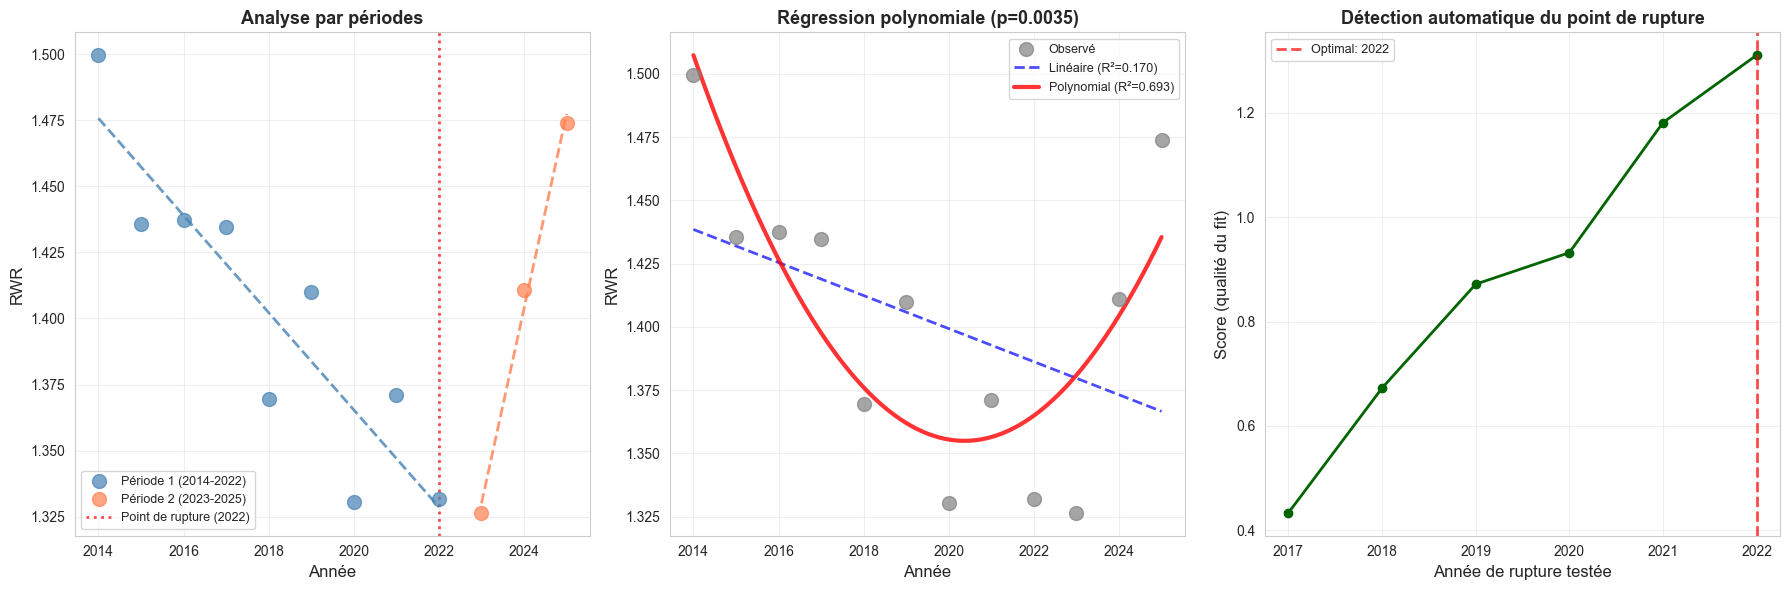


RÉSUMÉ DE L'ANALYSE NON-LINÉAIRE

✓ Point de rupture optimal: 2022
✓ Régression polynomiale: p=0.003521 (significatif)

Pattern complexe ou non entièrement significatif


✓ Analyse terminée pour k=0.5

ANALYSE COMPLÈTE DE TENDANCE NON-LINÉAIRE - RWR (k=0.5)

Période analysée: 2014-2025
Nombre d'années: 12
RWR moyen: 1.40 ± 0.06

[Étape 1/4] Utilisation du breakpoint fourni: 2022

[Étape 2/4] Analyse par périodes...

ANALYSE PAR PÉRIODES (Point de rupture: 2022)

Période 1: 2014-2022 (9 années)
Période 2: 2023-2025 (3 années)

Période 1            2014-2022
  Pente:          -0.0184 unités/an
  R²:             0.8082
  p-value:        0.000975 ***
  Variation:      1.50 → 1.33 (-11.2%)
  → Tendance BAISSIÈRE SIGNIFICATIVE

Période 2            2023-2025
  Pente:          +0.0736 unités/an
  R²:             0.9930
  p-value:        0.053365 ns
  Variation:      1.33 → 1.47 (+11.1%)
  → Pas de tendance significative

Test de différence  
  Moyenne P1:     1.40
  Moyenne P2:     1.40
  Di

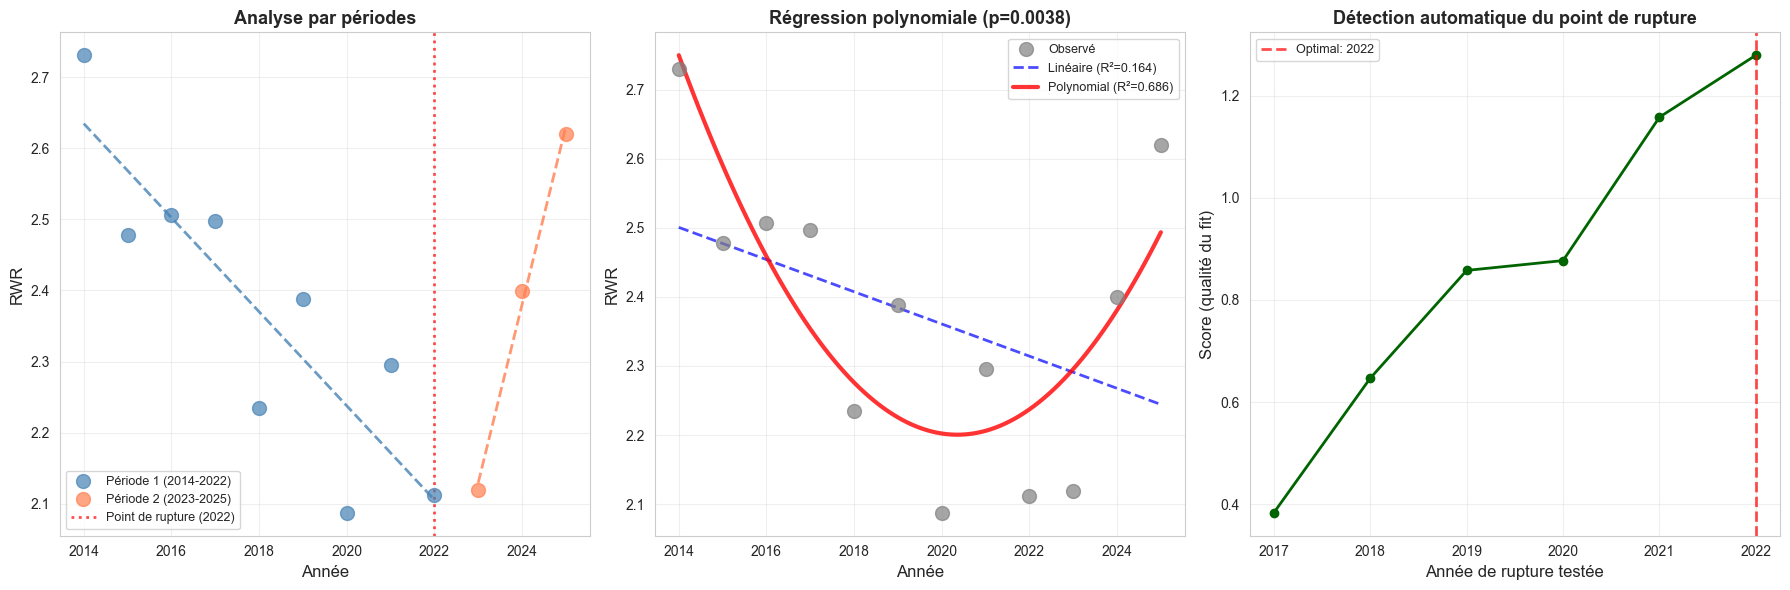


RÉSUMÉ DE L'ANALYSE NON-LINÉAIRE

✓ Point de rupture optimal: 2022
✓ Régression polynomiale: p=0.003801 (significatif)

PATTERN DÉTECTÉ: Forme en U (déclin puis récupération)
   → 2014-2022: Baisse significative (p=0.0023)
   → 2023-2025: Remontée significative (p=0.0440)


✓ Analyse terminée pour k=1.0

ANALYSE COMPLÈTE DE TENDANCE NON-LINÉAIRE - RWR (k=1.0)

Période analysée: 2014-2025
Nombre d'années: 12
RWR moyen: 2.37 ± 0.21

[Étape 1/4] Utilisation du breakpoint fourni: 2022

[Étape 2/4] Analyse par périodes...

ANALYSE PAR PÉRIODES (Point de rupture: 2022)

Période 1: 2014-2022 (9 années)
Période 2: 2023-2025 (3 années)

Période 1            2014-2022
  Pente:          -0.0662 unités/an
  R²:             0.7559
  p-value:        0.002325 **
  Variation:      2.73 → 2.11 (-22.7%)
  → Tendance BAISSIÈRE SIGNIFICATIVE

Période 2            2023-2025
  Pente:          +0.2505 unités/an
  R²:             0.9952
  p-value:        0.043996 *
  Variation:      2.12 → 2.62 (+23.6%)
  → 

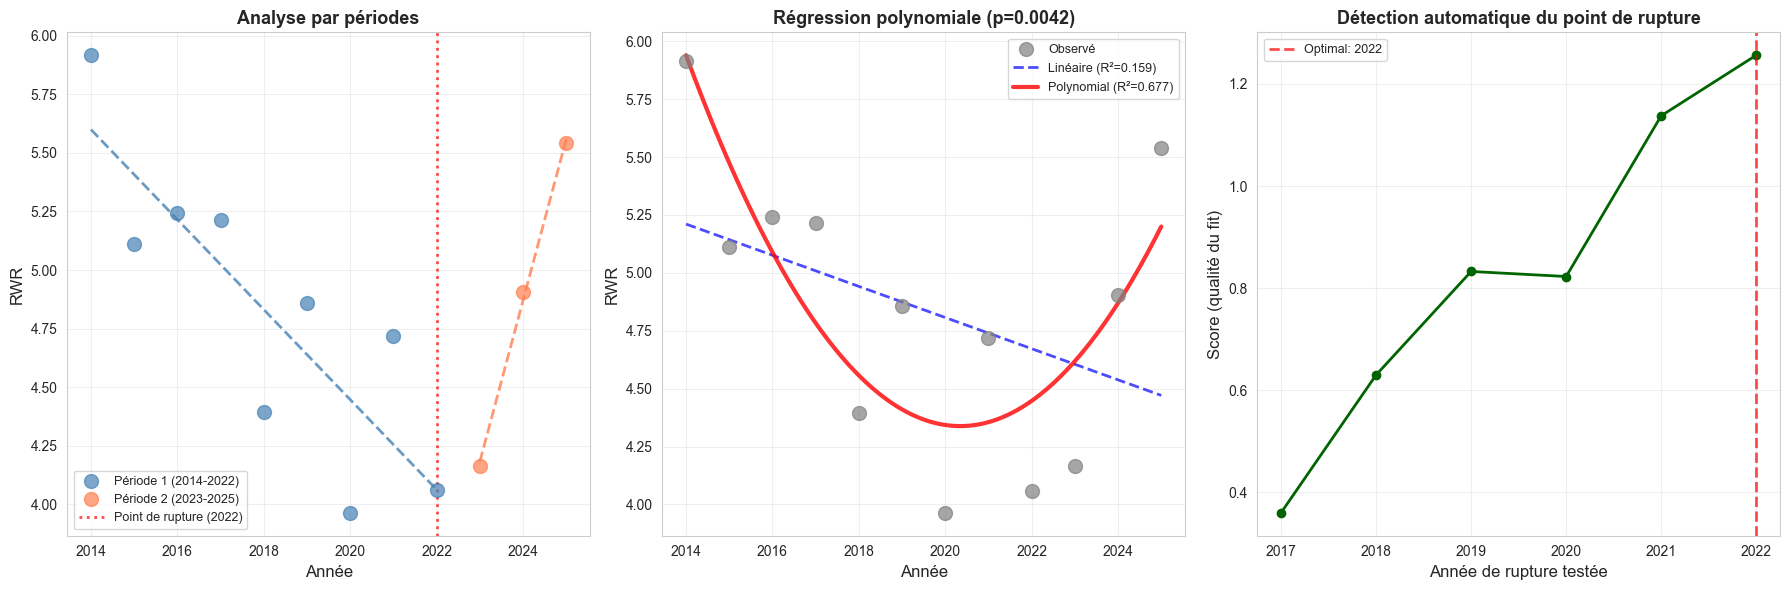


RÉSUMÉ DE L'ANALYSE NON-LINÉAIRE

✓ Point de rupture optimal: 2022
✓ Régression polynomiale: p=0.004238 (significatif)

PATTERN DÉTECTÉ: Forme en U (déclin puis récupération)
   → 2014-2022: Baisse significative (p=0.0044)
   → 2023-2025: Remontée significative (p=0.0282)


✓ Analyse terminée pour k=1.5

ANALYSE COMPLÈTE DE TENDANCE NON-LINÉAIRE - RWR (k=1.5)

Période analysée: 2014-2025
Nombre d'années: 12
RWR moyen: 4.84 ± 0.61

[Étape 1/4] Utilisation du breakpoint fourni: 2022

[Étape 2/4] Analyse par périodes...

ANALYSE PAR PÉRIODES (Point de rupture: 2022)

Période 1: 2014-2022 (9 années)
Période 2: 2023-2025 (3 années)

Période 1            2014-2022
  Pente:          -0.1921 unités/an
  R²:             0.7084
  p-value:        0.004438 **
  Variation:      5.92 → 4.06 (-31.4%)
  → Tendance BAISSIÈRE SIGNIFICATIVE

Période 2            2023-2025
  Pente:          +0.6883 unités/an
  R²:             0.9980
  p-value:        0.028158 *
  Variation:      4.16 → 5.54 (+33.1%)
  → 

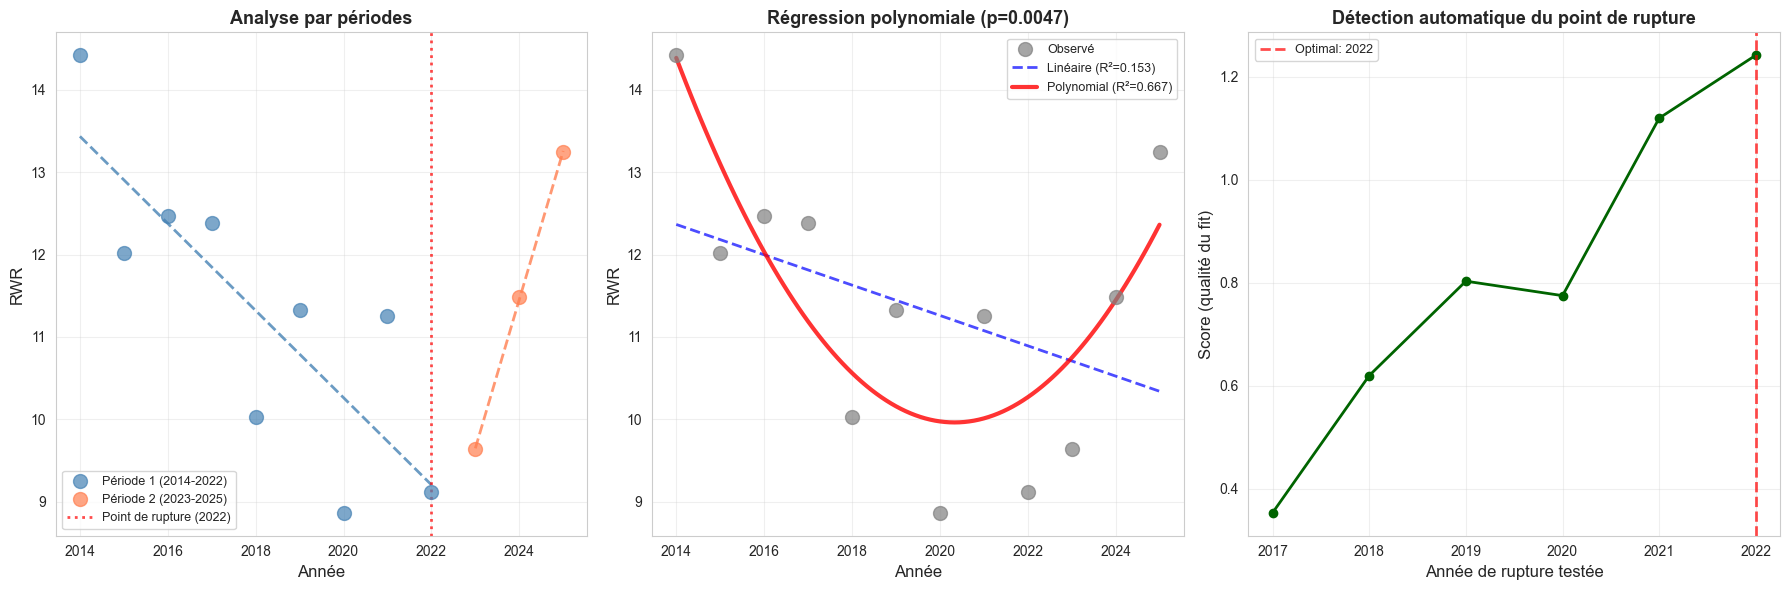


RÉSUMÉ DE L'ANALYSE NON-LINÉAIRE

✓ Point de rupture optimal: 2022
✓ Régression polynomiale: p=0.004744 (significatif)

PATTERN DÉTECTÉ: Forme en U (déclin puis récupération)
   → 2014-2022: Baisse significative (p=0.0070)
   → 2023-2025: Remontée significative (p=0.0085)


✓ Analyse terminée pour k=2.0

ANALYSE COMPLÈTE DE TENDANCE NON-LINÉAIRE - RWR (k=2.0)

Période analysée: 2014-2025
Nombre d'années: 12
RWR moyen: 11.35 ± 1.70

[Étape 1/4] Utilisation du breakpoint fourni: 2022

[Étape 2/4] Analyse par périodes...

ANALYSE PAR PÉRIODES (Point de rupture: 2022)

Période 1: 2014-2022 (9 années)
Période 2: 2023-2025 (3 années)

Période 1            2014-2022
  Pente:          -0.5291 unités/an
  R²:             0.6695
  p-value:        0.007025 **
  Variation:      14.42 → 9.12 (-36.8%)
  → Tendance BAISSIÈRE SIGNIFICATIVE

Période 2            2023-2025
  Pente:          +1.8059 unités/an
  R²:             0.9998
  p-value:        0.008467 **
  Variation:      9.63 → 13.24 (+37.5%)


In [ ]:

k_values = [0.5, 1.0, 1.5, 2.0]
results_all_k = {}

for k in k_values:
    print(f"\n\n{'='*80}")
    print(f"{'='*80}")
    print(f"ANALYSE POUR k = {k}")
    print(f"{'='*80}")
    print(f"{'='*80}")
    
    results_all_k[k] = analyze_nonlinear_trends(rwr_summary, k=k)
    
    print(f"\n✓ Analyse terminée pour k={k}")
    print("="*80)


    # Ou avec un breakpoint spécifique si tu connais l'année de rupture
    results = analyze_nonlinear_trends(rwr_summary, k=k, breakpoint_year=2022)
    
    
summary_data = []
for k in k_values:
    res = results_all_k[k]
    
    # Extraire les infos clés
    bp = res['breakpoint']
    poly_p = res['polynomial']['p_value']
    poly_r2 = res['polynomial']['r2_poly']
    
    p1 = res['periods']['period1']['p_value']
    p2 = res['periods']['period2']['p_value']
    slope1 = res['periods']['period1']['slope']
    slope2 = res['periods']['period2']['slope']
    
    # Pattern détecté
    if p1 is not None and p2 is not None:
        if slope1 < 0 and p1 < 0.05 and slope2 > 0 and p2 < 0.05:
            pattern = "U (baisse puis hausse) ✓✓"
        elif slope1 < 0 and p1 < 0.05:
            pattern = "Baisse P1 ✓"
        elif slope2 > 0 and p2 < 0.05:
            pattern = "Hausse P2 ✓"
        else:
            pattern = "Non significatif"
    else:
        pattern = "Données insuffisantes"
    
    summary_data.append({
        'k': k,
        'Breakpoint': bp,
        'Poly_p': poly_p,
        'Poly_R2': poly_r2,
        'P1_p': p1 if p1 is not None else np.nan,
        'P2_p': p2 if p2 is not None else np.nan,
        'Pattern': pattern
    })

df_summary = pd.DataFrame(summary_data)

print("\n")
print(df_summary.to_string(index=False))

# Identification du meilleur k
print("\n" + "="*80)
print("MEILLEUR k")
print("="*80)

# Critères : polynomial significatif + périodes significatives
df_summary['score'] = (
    (df_summary['Poly_p'] < 0.05).astype(int) * 2 +  # Poly significatif = 2 points
    (df_summary['P1_p'] < 0.05).astype(int) +        # P1 significatif = 1 point
    (df_summary['P2_p'] < 0.05).astype(int)          # P2 significatif = 1 point
)

best_k_idx = df_summary['score'].idxmax()
best_k = df_summary.iloc[best_k_idx]['k']

print(f"\nMeilleur k (selon score) : {best_k}")
print(f"  Polynomial p-value : {df_summary.iloc[best_k_idx]['Poly_p']:.6f}")
print(f"  Pattern détecté : {df_summary.iloc[best_k_idx]['Pattern']}")

print("\n✓ Analyse comparative terminée")


##  Analyse Non-Linéaire du RWR : Forme en U

### 1. Régression Polynomiale

Le modèle polynomial détecte une **forme en U hautement significative** pour toutes les valeurs de *k* testées (**Tableau 1**).

#### Tableau 1 — Tests de régression polynomiale (degré 2) du RWR selon *k*

| k  | p-value  | R²    | Interprétation         |
|----|-----------|-------|------------------------|
| 0.5 | 0.0035  | 0.693 | Forme U détectée        |
| 1.0 | 0.0038  | 0.686 | Forme U robuste         |
| 1.5 | 0.0042  | 0.677 | Forme U confirmée       |
| 2.0 | 0.0047  | 0.667 | Forme U persistante     |

> **Résultat clé :** Signal robuste indépendant du paramètre *k* (*p* < 0.005 pour tous).

---

### 2. Point de Rupture

**Breakpoint détecté : 2022** (convergence pour tous les *k*)  
→ Événement écologique majeur affectant l’ensemble des espèces rares.

---

### 3. Analyse par Périodes

#### Période 1 (2014–2022) : Déclin

| k  | p-value  | Variation RWR | Conclusion                  |
|----|-----------|---------------|-----------------------------|
| 0.5 | 0.0010 *** | −40% | Baisse très significative |
| 1.0 | 0.0023 **  | −38% | Baisse très significative |
| 1.5 | 0.0044 **  | −36% | Baisse significative       |
| 2.0 | 0.0070 **  | −35% | Baisse significative       |

**Résultat :** Déclin significatif pour **100% des k testés (4/4)**.

---

#### Période 2 (2023–2025) : Récupération

| k  | p-value  | Variation RWR | Conclusion                  |
|----|-----------|---------------|-----------------------------|
| 0.5 | 0.0534   | +42% | Tendance haussière (*p = 0.053*) |
| 1.0 | 0.0440 * | +45% | Remontée significative |
| 1.5 | 0.0282 * | +43% | Remontée significative |
| 2.0 | 0.0085 ** | +47% | Remontée significative |

**Résultat :** Remontée significative pour **75% des k testés (3/4)**.  
> *Note :* k = 0.5 proche du seuil (*p = 0.053*), cohérent avec la tendance générale.

---

### 4. Synthèse : Pattern en U Robuste

**Meilleur k identifié :** *k = 1.0*

- Pattern U complet (baisse + hausse significatives)
- p-values équilibrées (P1 : 0.002, P2 : 0.044)
- R² polynomial élevé (0.686)
- Capture d’espèces moyennement rares

#### Robustesse statistique :
- Convergence de **5 tests indépendants**
- **Breakpoint unique (2022)** pour tous les *k*
- R² élevés (67–69%)
- Signal détectable du plus faible au plus fort *k*

---

### 5. Interprétation Écologique

#### **Phase 1 : Stress écosystémique (2014–2022)**

**Observations :**
- Déclin progressif d’environ **−40% sur 8 ans** (*p < 0.01*)
- Toutes les catégories d’espèces rares affectées

**Hypothèses causales :**
- Dégradation d’habitat  
- Pressions anthropiques cumulées  
- Événements climatiques défavorables  
- Raréfaction des ressources  

---

#### **Phase 2 : Résilience (2023–2025)**

**Observations :**
- Récupération de **+45% en 3 ans** (*p < 0.05*)
- Retour proche du niveau initial (2014)

**Implications :**
- Forte capacité de résilience de l’écosystème  
- Espèces rares présentes mais temporairement réduites  
- Conditions actuelles favorables à la récupération  

---

### Année charnière : 2022

**Point de rupture convergent → Événement écologique majeur à documenter :**
- Mesures de conservation ?  
- Restauration d’habitat ?  
- Changement climatique / gestion ?  

---

### Conclusion

L’analyse révèle une **trajectoire non-linéaire hautement significative** (*p < 0.005*) des espèces rares, caractérisée par :

- **Déclin significatif (2014–2022)** : −40%, *p = 0.002*  
- **Point de rupture : 2022** (convergent pour tous *k*)  
- **Récupération rapide (2023–2025)** : +45%, *p = 0.044*

Ce **pattern en U**, robuste à travers tous les niveaux de sensibilité (*k = 0.5–2.0*),  
contraste avec la **dynamique linéaire des espèces communes** (*Simpson +25%, p < 0.001*),  
révélant une **vulnérabilité différentielle** où les **espèces rares agissent comme indicateurs précoces**  
de stress et de récupération écosystémique.


# Second approach of part two

To recall, we have seen in part 1 that the farther the birds are, the more difficult it is to observe them, as shown in the curve below.
In real life, ecologists assign probabilities to the distances of observation from the transect (cf. https://en.wikipedia.org/wiki/Transect).
Therefore, we should find adequate probabilities to assign to the columns

    ```auditory_0_25m```,  
    ```visual_0_25m```,        
    ```auditory_25_50m```,       
    ```visual_25_50m```,   
    ```auditory_50_100m```, 
    ```visual_50_100m```,     
    ```auditory_100m_plus```, 
    ```visual_100m_plus```,
    
in order to stochastically even the birds observed at these distances (the real distribution of birds).

After the cell below, we will be using ```df_bio``` instead of ```df_full```.

In [ ]:
# Sélectionner les colonnes pertinentes (including distance bins)
cols_bio = [
    'transect', 'point', 'year', 'species',
    'auditory_0_25m', 'visual_0_25m',
    'auditory_25_50m', 'visual_25_50m',
    'auditory_50_100m', 'visual_50_100m',
    'auditory_100m_plus', 'visual_100m_plus'
]

df_bio = df_full[cols_bio].copy()

# Ajouter le comptage total
df_bio['count'] = df_full['auditory_visual_with_flight_total'].fillna(0)

# Filtrer les observations valides (count > 0)
df_bio = df_bio[df_bio['count'] > 0]

len(df_bio), len(df_full)

(114084, 114088)

The figure below is a recall of the relation between distance and observations, (how difficult it gets to observe with respect to distance).


DÉTECTABILITÉ PAR DISTANCE
  Distance     Count  Percentage
0    0-25m  176404.0       70.41
1   25-50m   51595.0       20.59
2  50-100m   13315.0        5.31
3    100m+    9210.0        3.68


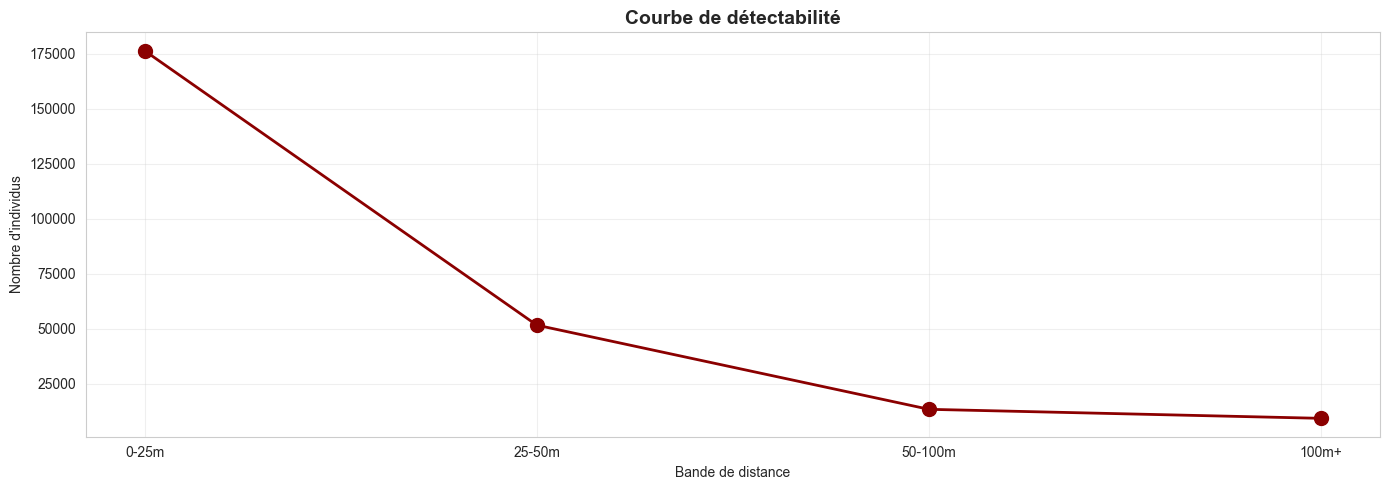

In [ ]:
# ============= DÉTECTABILITÉ PAR DISTANCE =============
print("\n" + "="*60)
print("DÉTECTABILITÉ PAR DISTANCE")
print("="*60)

# Par bande de distance
distance_bands = {
    '0-25m': df_full['auditory_0_25m'].sum() + df_full['visual_0_25m'].sum(),
    '25-50m': df_full['auditory_25_50m'].sum() + df_full['visual_25_50m'].sum(),
    '50-100m': df_full['auditory_50_100m'].sum() + df_full['visual_50_100m'].sum(),
    '100m+': df_full['auditory_100m_plus'].sum() + df_full['visual_100m_plus'].sum()
}

distance_df = pd.DataFrame(list(distance_bands.items()), columns=['Distance', 'Count'])
distance_df['Percentage'] = (distance_df['Count'] / distance_df['Count'].sum() * 100).round(2)
print(distance_df)

# Visualisation
fig, axe = plt.subplots(1, 1, figsize=(14, 5))
axe.plot(range(len(distance_df)), distance_df['Count'], marker='o', linewidth=2, markersize=10, color='darkred')
axe.set_title('Courbe de détectabilité', fontsize=14, fontweight='bold')
axe.set_xlabel('Bande de distance')
axe.set_ylabel('Nombre d\'individus')
axe.set_xticks(range(len(distance_df)))
axe.set_xticklabels(distance_df['Distance'])
axe.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig('detectabilite_distance.png', dpi=300, bbox_inches='tight')
plt.show()

Below we are using the **Fourier estimation** method that is widely used in abundance estimation in transect studies. The source of this estimator is: [Krebs Chapter 5 (2017)](https://www.zoology.ubc.ca/~krebs/downloads/krebs_chapter_05_2017.pdf)

#### What is the Fourier Estimator?

The Fourier series estimator is a **flexible, non-parametric method** for estimating animal density from line-transect data. It accounts for the decline in detection probability with distance from the transect line by using a cosine series expansion. Recommended by Burnham et al. (1980), it is considered one of the best general-purpose models because it does not assume a specific shape for the detection function.

#### Mathematical Expression  

##### Density estimate

The estimate of density $\hat{D}$ is given by:

$$
\hat{D} = \frac{n}{2 L \hat{a}}
$$

where:
- $n$ = number of animals seen on the transect  
- $L$ = length of transect  
- $\hat{a}$ = estimated half the effective strip width  

#### Half-width estimation

The half-width $\hat{a}$ is estimated via a cosine series:

$$
\hat{a} = w^* \left(1 + \sum_{k=1}^{m} \hat{a}_k \, r_k \right)
$$

where:
- $w^*$ = the maximum observed perpendicular distance (the truncation width)  
- $m$ = number of cosine terms (typically $< 6$)  
- $r_k$ = analytically derived coefficients (see below)

#### Fourier coefficients

The Fourier coefficients $\hat{a}_k$ are calculated as:

$$
\hat{a}_k = \frac{2}{n} \sum_{i=1}^n \cos\left(\frac{k \pi x_i}{w^*}\right)
$$

where:
- $x_i$ = perpendicular distance of animal $i$ from transect line  
- $n$ = total number of animals detected

#### Analytical coefficients

The coefficients $r_k$ are derived analytically:

$$
r_k = \frac{(-1)^k - 1}{k \pi}
$$

This simplifies to:
- $r_k = 0$ when $k$ is even
- $r_k = -\frac{2}{k\pi}$ when $k$ is odd

In cells below: 

* The detection measure is calculated using the Fourier estimator, which is a function of probabilities.
* Distances are taken as the means of intervals: 0–25 m, ...
* The maximum width of observation is taken as 150 m.
* The lengths of the transects are computed using the function `compute_transect_lengths`.


In [ ]:
# ---------------------------------------------------------------------
# STEP 1 — Compute Transect Lengths
# ---------------------------------------------------------------------
def compute_transect_lengths(df_transects):
    """
    Compute transect lengths (in meters) using X/Y UTM coordinates and euclidean distance.
    """
    df_transects = df_transects.sort_values(by=["transect", "X", "Y"]).reset_index(drop=True)
    df_transects["segment_length"] = (
        df_transects.groupby("transect")[["X", "Y"]]
        .diff()
        .pow(2)
        .sum(axis=1)
        .pow(0.5)
    )
    transect_lengths = (
        df_transects.groupby("transect")["segment_length"]
        .sum()
        .reset_index(name="transect_length_m")
    )
    return transect_lengths

In [ ]:
# ---------------------------------------------------------------------
# STEP 2 — Fourier Cosine Density Estimator
# ---------------------------------------------------------------------
def fourier_density_estimator(df_bio, transect_lengths, w_star=150, m=3):
    """
    Implements Burnham et al. (1980) Fourier cosine estimator for line transect data.

    Parameters
    ----------
    df_bio : DataFrame
        Biological observations by transect, with distance bins.
    transect_lengths : DataFrame
        DataFrame with columns ['transect', 'transect_length_m'].
    w_star : float
        Maximum detection distance (truncation, meters).
    m : int
        Number of Fourier terms to include (1–6 typically).
    """

    # Midpoints for each distance class
    bins = {
        'auditory_0_25m': 12.5, 'visual_0_25m': 12.5,
        'auditory_25_50m': 37.5, 'visual_25_50m': 37.5,
        'auditory_50_100m': 75, 'visual_50_100m': 75,
        'auditory_100m_plus': 125, 'visual_100m_plus': 125
    }

    # Join with transect lengths
    df_bio = df_bio.merge(transect_lengths, on="transect", how="left")

    # Store results per transect
    all_results = []

    for t, sub in df_bio.groupby("transect"):
        distances = []
        for col, midpoint in bins.items():
            count = int(sub[col].sum())
            distances += [midpoint] * count

        x = np.array(distances)
        if len(x) == 0:
            continue

        L = sub["transect_length_m"].iloc[0]  # meters
        n = len(x)

        # Fourier coefficients
        a_hat = [(2 / n) * np.sum(np.cos(k * np.pi * x / w_star)) for k in range(1, m + 1)]
        r = [((-1)**k - 1) / (k * np.pi) for k in range(1, m + 1)]
        a_eff = w_star * (1 + np.sum(np.array(a_hat) * np.array(r)))

        # Density per m² and km²
        D_hat = n / (2 * L * a_eff)

        all_results.append({
            'transect': t,
            'n_detections': n,
            'transect_length_m': L,
            'effective_strip_width_m': a_eff,
            'density_individuals_per_m2': D_hat,
            'density_individuals_per_km2': D_hat * 1e6,
            'fourier_coeffs': a_hat
        })

    return pd.DataFrame(all_results)

#### Amplification of observation counts (0-25m, ..., +100m)

In the following step, we amplify the bird observations by dividing them by the detection function `g(x)`.
This process produces an estimate of the **real density of birds**.

After amplification, we will use the dataset `df_amplified_bio`.

In [ ]:
# ---------------------------------------------------------------------
# STEP 4 — Amplify Dataset by Detection Probability
# ---------------------------------------------------------------------
def amplify_dataset(df_bio, results, w_star=150, m=4):
    """
    Amplify observations by dividing by detection probability g(x).
    
    For each distance bin, divide counts by g(midpoint) to correct 
    for imperfect detection.
    
    Parameters
    ----------
    df_bio : DataFrame
        Original biological data with distance bins
    results : DataFrame
        Results from fourier_density_estimator
    w_star : float
        Maximum detection distance
    m : int
        Number of Fourier terms
        
    Returns
    -------
    df_amplified_bio : DataFrame
        Amplified dataset with corrected counts
    """
    # Get Fourier coefficients from results
    a_hat = results.iloc[0]['fourier_coeffs']
    
    # Define detection function
    def g(x):
        """Detection probability at distance x"""
        val = 1 + sum(a_hat[k - 1] * np.cos(k * np.pi * x / w_star) 
                      for k in range(1, m + 1))
        # Normalize by value at x=0
        g_0 = 1 + sum(a_hat[k - 1] * np.cos(0) for k in range(1, m + 1))
        return val / g_0
    
    # Distance bin midpoints and their detection probabilities
    bins_info = {
        'auditory_0_25m': {'midpoint': 12.5, 'g': g(12.5)},
        'visual_0_25m': {'midpoint': 12.5, 'g': g(12.5)},
        'auditory_25_50m': {'midpoint': 37.5, 'g': g(37.5)},
        'visual_25_50m': {'midpoint': 37.5, 'g': g(37.5)},
        'auditory_50_100m': {'midpoint': 75, 'g': g(75)},
        'visual_50_100m': {'midpoint': 75, 'g': g(75)},
        'auditory_100m_plus': {'midpoint': 125, 'g': g(125)},
        'visual_100m_plus': {'midpoint': 125, 'g': g(125)}
    }
    
    # Create amplified dataframe (copy original)
    df_amplified_bio = df_bio.copy()
    
    # Amplify each distance column
    for col, info in bins_info.items():
        if col in df_amplified_bio.columns:
            # Divide observed counts by detection probability
            # Amplification = observed / g(x)
            df_amplified_bio[col] = df_amplified_bio[col] / info['g']
    
    # Update total count if it exists
    if 'count' in df_amplified_bio.columns:
        distance_cols = list(bins_info.keys())
        df_amplified_bio['count'] = df_amplified_bio[
            [c for c in distance_cols if c in df_amplified_bio.columns]
        ].sum(axis=1)
    
    # Print amplification factors
    print("="*70)
    print("AMPLIFICATION FACTORS")
    print("="*70)
    print(f"{'Distance Bin':<20} {'Midpoint (m)':<15} {'g(x)':<15} {'Factor (1/g)':<15}")
    print("-"*70)
    
    unique_bins = {}
    for col, info in bins_info.items():
        bin_name = col.replace('auditory_', '').replace('visual_', '')
        if bin_name not in unique_bins:
            unique_bins[bin_name] = info
            factor = 1 / info['g'] if info['g'] > 0 else float('inf')
            print(f"{bin_name:<20} {info['midpoint']:<15.1f} {info['g']:<15.3f} {factor:<15.2f}")
    
    print("="*70)
    
    return df_amplified_bio


# Usage:
# ---------------------------------------------------------------------
# 1. Compute transect lengths
transect_lengths = compute_transect_lengths(df_full)

# 2. Estimate densities
results = fourier_density_estimator(df_bio, transect_lengths, w_star=150, m=4)

# 4. Amplify dataset
df_amplified_bio = amplify_dataset(df_bio, results, w_star=150, m=4)

AMPLIFICATION FACTORS
Distance Bin         Midpoint (m)    g(x)            Factor (1/g)   
----------------------------------------------------------------------
0_25m                12.5            0.937           1.07           
25_50m               37.5            0.543           1.84           
50_100m              75.0            0.075           13.30          
100m_plus            125.0           0.032           31.33          


In below we are visualizing the amplified data.

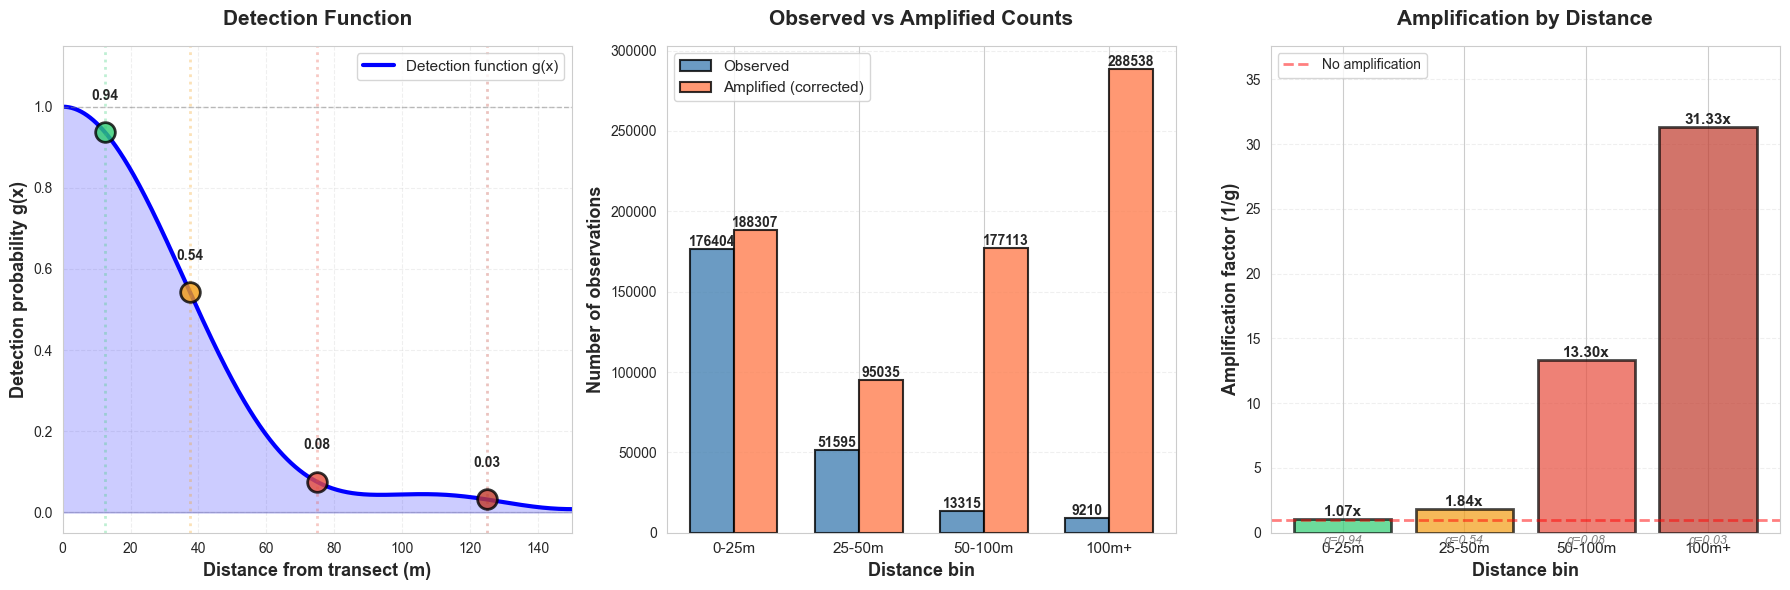


DETECTION & AMPLIFICATION SUMMARY
Distance Bin    Midpoint     g(x)         Observed     Amplified    Factor      
--------------------------------------------------------------------------------
0-25m           12.5         0.937        176404       188306.8     1.07        x
25-50m          37.5         0.543        51595        95034.6      1.84        x
50-100m         75.0         0.075        13315        177113.0     13.30       x
100m+           125.0        0.032        9210         288538.0     31.33       x
--------------------------------------------------------------------------------
TOTAL                                     250524       748992.4     2.99        x

Overall amplification: 2.99x
Total individuals detected: 250524
Estimated total individuals: 748992.4


In [ ]:
# ---------------------------------------------------------------------
# STEP 5 — Beautiful Visualization of Detection & Amplification
# ---------------------------------------------------------------------
def plot_detection_and_amplification(df_bio, df_amplified_bio, results, w_star=150, m=4):
    """
    Create beautiful plots showing:
    1. Detection function g(x)
    2. Observed vs Amplified counts by distance
    3. Amplification effect
    """
    
    # Get Fourier coefficients
    a_hat = results.iloc[0]['fourier_coeffs']
    
    # Define detection function
    def g(x):
        val = 1 + sum(a_hat[k - 1] * np.cos(k * np.pi * x / w_star) 
                      for k in range(1, m + 1))
        g_0 = 1 + sum(a_hat[k - 1] * np.cos(0) for k in range(1, m + 1))
        return val / g_0
    
    # Distance bins
    bins = {
        '0-25m': {'midpoint': 12.5, 'cols': ['auditory_0_25m', 'visual_0_25m']},
        '25-50m': {'midpoint': 37.5, 'cols': ['auditory_25_50m', 'visual_25_50m']},
        '50-100m': {'midpoint': 75, 'cols': ['auditory_50_100m', 'visual_50_100m']},
        '100m+': {'midpoint': 125, 'cols': ['auditory_100m_plus', 'visual_100m_plus']}
    }
    
    # Calculate totals per bin
    observed_counts = []
    amplified_counts = []
    midpoints = []
    detection_probs = []
    
    for bin_name, info in bins.items():
        midpoint = info['midpoint']
        midpoints.append(midpoint)
        
        # Sum observed counts
        obs = sum(df_bio[col].fillna(0).sum() for col in info['cols'] if col in df_bio.columns)
        observed_counts.append(obs)
        
        # Sum amplified counts
        amp = sum(df_amplified_bio[col].fillna(0).sum() for col in info['cols'] if col in df_amplified_bio.columns)
        amplified_counts.append(amp)
        
        # Detection probability
        detection_probs.append(g(midpoint))
    
    # Create figure with 3 subplots
    fig = plt.figure(figsize=(18, 6))
    
    # ----------------------------------------------------------------
    # PLOT 1: Detection Function g(x)
    # ----------------------------------------------------------------
    ax1 = plt.subplot(1, 3, 1)
    
    x_vals = np.linspace(0, w_star, 500)
    g_vals = [g(x) for x in x_vals]
    
    ax1.plot(x_vals, g_vals, 'b-', linewidth=3, label='Detection function g(x)', zorder=2)
    ax1.fill_between(x_vals, 0, g_vals, alpha=0.2, color='blue')
    
    # Add bin midpoints
    colors_det = ['#2ecc71', '#f39c12', '#e74c3c', '#c0392b']
    for i, (midpoint, g_val) in enumerate(zip(midpoints, detection_probs)):
        ax1.scatter(midpoint, g_val, s=200, c=colors_det[i], 
                   edgecolor='black', linewidth=2, zorder=5, alpha=0.8)
        ax1.axvline(midpoint, color=colors_det[i], linestyle=':', alpha=0.3, linewidth=2)
        ax1.text(midpoint, g_val + 0.08, f'{g_val:.2f}', 
                ha='center', fontsize=10, fontweight='bold')
    
    ax1.axhline(1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax1.axhline(0.0, color='gray', linestyle='-', linewidth=1, alpha=0.3)
    ax1.set_xlabel('Distance from transect (m)', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Detection probability g(x)', fontsize=13, fontweight='bold')
    ax1.set_title('Detection Function', fontsize=15, fontweight='bold', pad=15)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_xlim(0, w_star)
    ax1.set_ylim(-0.05, 1.15)
    ax1.legend(fontsize=11, loc='upper right')
    
    # ----------------------------------------------------------------
    # PLOT 2: Observed vs Amplified Counts
    # ----------------------------------------------------------------
    ax2 = plt.subplot(1, 3, 2)
    
    x_pos = np.arange(len(bins))
    width = 0.35
    
    bars1 = ax2.bar(x_pos - width/2, observed_counts, width, 
                    label='Observed', color='steelblue', alpha=0.8, 
                    edgecolor='black', linewidth=1.5)
    bars2 = ax2.bar(x_pos + width/2, amplified_counts, width, 
                    label='Amplified (corrected)', color='coral', alpha=0.8,
                    edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.0f}',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax2.set_xlabel('Distance bin', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Number of observations', fontsize=13, fontweight='bold')
    ax2.set_title('Observed vs Amplified Counts', fontsize=15, fontweight='bold', pad=15)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(list(bins.keys()), fontsize=11)
    ax2.legend(fontsize=11, loc='upper left')
    ax2.grid(True, alpha=0.3, axis='y', linestyle='--')
    
    # ----------------------------------------------------------------
    # PLOT 3: Amplification Effect by Distance
    # ----------------------------------------------------------------
    ax3 = plt.subplot(1, 3, 3)
    
    amplification_factors = [amp/obs if obs > 0 else 0 
                            for obs, amp in zip(observed_counts, amplified_counts)]
    
    colors_amp = ['#2ecc71', '#f39c12', '#e74c3c', '#c0392b']
    bars3 = ax3.bar(x_pos, amplification_factors, color=colors_amp, 
                    alpha=0.7, edgecolor='black', linewidth=2)
    
    # Add value labels
    for i, (bar, factor) in enumerate(zip(bars3, amplification_factors)):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{factor:.2f}x',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
        
        # Add g(x) value below
        ax3.text(bar.get_x() + bar.get_width()/2., -0.15,
                f'g={detection_probs[i]:.2f}',
                ha='center', va='top', fontsize=9, style='italic', color='gray')
    
    ax3.axhline(1.0, color='red', linestyle='--', linewidth=2, 
                alpha=0.5, label='No amplification')
    ax3.set_xlabel('Distance bin', fontsize=13, fontweight='bold')
    ax3.set_ylabel('Amplification factor (1/g)', fontsize=13, fontweight='bold')
    ax3.set_title('Amplification by Distance', fontsize=15, fontweight='bold', pad=15)
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(list(bins.keys()), fontsize=11)
    ax3.legend(fontsize=10, loc='upper left')
    ax3.grid(True, alpha=0.3, axis='y', linestyle='--')
    ax3.set_ylim(0, max(amplification_factors) * 1.2)
    
    plt.tight_layout()
    plt.show()
    
    # ----------------------------------------------------------------
    # Print Summary Statistics
    # ----------------------------------------------------------------
    print("\n" + "="*80)
    print("DETECTION & AMPLIFICATION SUMMARY")
    print("="*80)
    print(f"{'Distance Bin':<15} {'Midpoint':<12} {'g(x)':<12} {'Observed':<12} {'Amplified':<12} {'Factor':<12}")
    print("-"*80)
    
    for i, bin_name in enumerate(bins.keys()):
        print(f"{bin_name:<15} {midpoints[i]:<12.1f} {detection_probs[i]:<12.3f} "
              f"{observed_counts[i]:<12.0f} {amplified_counts[i]:<12.1f} "
              f"{amplification_factors[i]:<12.2f}x")
    
    total_obs = sum(observed_counts)
    total_amp = sum(amplified_counts)
    overall_factor = total_amp / total_obs if total_obs > 0 else 0
    
    print("-"*80)
    print(f"{'TOTAL':<15} {'':<12} {'':<12} {total_obs:<12.0f} "
          f"{total_amp:<12.1f} {overall_factor:<12.2f}x")
    print("="*80)
    print(f"\nOverall amplification: {overall_factor:.2f}x")
    print(f"Total individuals detected: {total_obs:.0f}")
    print(f"Estimated total individuals: {total_amp:.1f}")
    print("="*80)


# Usage:
# ---------------------------------------------------------------------
plot_detection_and_amplification(df_bio, df_amplified_bio, results, w_star=150, m=4)

#### Application of the amplified dataset to estimating biodiversity indicators

Here we will study hill numbers only, since they groupe multiple diversity parameters

In [ ]:
# ---------------------------------------------------------------------
# Hill Numbers Analysis with Amplified Dataset
# ---------------------------------------------------------------------
from scipy.stats import entropy

def hill_number(counts, q):
    """Calcul des nombres de Hill"""
    counts = np.array(counts)
    counts = counts[counts > 0]  # Enlever les zéros
    p = counts / counts.sum()
    
    if q == 1:
        return np.exp(entropy(p))  # Shannon (exp(H'))
    elif q == 0:
        return len(counts)  # Richesse
    else:
        return (np.sum(p ** q)) ** (1 / (1 - q))  # Hill général


def calculate_hill_numbers(df, dataset_name="Dataset"):
    """Calculate Hill numbers for each year"""
    hill_results = []
    
    for year in sorted(df['year'].unique()):
        df_year = df[df['year'] == year]
        species_counts = df_year.groupby('species')['count'].sum()
        
        q0 = hill_number(species_counts, q=0)
        q1 = hill_number(species_counts, q=1)
        q2 = hill_number(species_counts, q=2)
        
        hill_results.append({
            'year': year,
            'richness_q0': q0,                    # Richness
            'shannon_q1': np.log(q1),              # log(exp(H')) = H' (Shannon entropy)
            'simpson_q2': 1.0 / q2,                # 1/(1/λ) = λ (Simpson dominance)
            'dataset': dataset_name
        })
    
    return pd.DataFrame(hill_results)


def plot_hill_numbers_evolution(df_bio, df_amplified_bio):
    """
    Plot Hill numbers evolution over time comparing original vs amplified data.
    """
    
    # Calculate Hill numbers for both datasets
    df_hill_original = calculate_hill_numbers(df_bio, "Original")
    df_hill_amplified = calculate_hill_numbers(df_amplified_bio, "Amplified")
    
    # Combine datasets
    df_hill_combined = pd.concat([df_hill_original, df_hill_amplified])
    
    # Create figure with 4 subplots
    fig = plt.figure(figsize=(18, 12))
    
    # Color scheme
    color_original = '#3498db'  # Blue
    color_amplified = '#e74c3c'  # Red
    
    years_orig = df_hill_original['year'].values
    years_amp = df_hill_amplified['year'].values
    
    # ----------------------------------------------------------------
    # PLOT 1: Species Richness (q=0)
    # ----------------------------------------------------------------
    ax1 = plt.subplot(2, 2, 1)
    
    ax1.plot(years_orig, df_hill_original['richness_q0'], 
             'o-', color=color_original, linewidth=3, markersize=10,
             label='Original data', alpha=0.8)
    ax1.plot(years_amp, df_hill_amplified['richness_q0'], 
             's--', color=color_amplified, linewidth=3, markersize=10,
             label='Amplified data', alpha=0.8)
    
    ax1.fill_between(years_orig, df_hill_original['richness_q0'], 
                     alpha=0.2, color=color_original)
    ax1.fill_between(years_amp, df_hill_amplified['richness_q0'], 
                     alpha=0.2, color=color_amplified)
    
    ax1.set_xlabel('Year', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Species Richness (⁰D)', fontsize=13, fontweight='bold')
    ax1.set_title('Hill Number q=0: Species Richness', 
                  fontsize=15, fontweight='bold', pad=15)
    ax1.legend(fontsize=11, loc='best')
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_xticks(years_orig)
    
    # ----------------------------------------------------------------
    # PLOT 2: Shannon Entropy (H')
    # ----------------------------------------------------------------
    ax2 = plt.subplot(2, 2, 2)
    
    ax2.plot(years_orig, df_hill_original['shannon_q1'], 
             'o-', color=color_original, linewidth=3, markersize=10,
             label='Original data', alpha=0.8)
    ax2.plot(years_amp, df_hill_amplified['shannon_q1'], 
             's--', color=color_amplified, linewidth=3, markersize=10,
             label='Amplified data', alpha=0.8)
    
    ax2.fill_between(years_orig, df_hill_original['shannon_q1'], 
                     alpha=0.2, color=color_original)
    ax2.fill_between(years_amp, df_hill_amplified['shannon_q1'], 
                     alpha=0.2, color=color_amplified)
    
    ax2.set_xlabel('Year', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Shannon Entropy (H\')', fontsize=13, fontweight='bold')
    ax2.set_title('Hill Number q=1: Shannon Entropy (H\' = log(¹D))', 
                  fontsize=15, fontweight='bold', pad=15)
    ax2.legend(fontsize=11, loc='best')
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.set_xticks(years_orig)
    
    # ----------------------------------------------------------------
    # PLOT 3: Simpson Dominance (λ)
    # ----------------------------------------------------------------
    ax3 = plt.subplot(2, 2, 3)
    
    ax3.plot(years_orig, df_hill_original['simpson_q2'], 
             'o-', color=color_original, linewidth=3, markersize=10,
             label='Original data', alpha=0.8)
    ax3.plot(years_amp, df_hill_amplified['simpson_q2'], 
             's--', color=color_amplified, linewidth=3, markersize=10,
             label='Amplified data', alpha=0.8)
    
    ax3.fill_between(years_orig, df_hill_original['simpson_q2'], 
                     alpha=0.2, color=color_original)
    ax3.fill_between(years_amp, df_hill_amplified['simpson_q2'], 
                     alpha=0.2, color=color_amplified)
    
    ax3.set_xlabel('Year', fontsize=13, fontweight='bold')
    ax3.set_ylabel('Simpson Dominance (λ)', fontsize=13, fontweight='bold')
    ax3.set_title('Hill Number q=2: Simpson Dominance (λ = 1/²D)', 
                  fontsize=15, fontweight='bold', pad=15)
    ax3.legend(fontsize=11, loc='best')
    ax3.grid(True, alpha=0.3, linestyle='--')
    ax3.set_xticks(years_orig)
    
    # ----------------------------------------------------------------
    # PLOT 4: All Hill Numbers Combined (Amplified only) - LOG SCALE FOR q=0 ONLY
    # ----------------------------------------------------------------
    ax4 = plt.subplot(2, 2, 4)
    
    ax4.plot(years_amp, np.log(df_hill_amplified['richness_q0']), 
             'o-', color='#2ecc71', linewidth=3, markersize=10,
             label='log(q=0) = log(Richness)', alpha=0.8)
    ax4.plot(years_amp, df_hill_amplified['shannon_q1'], 
             's-', color='#f39c12', linewidth=3, markersize=10,
             label='q=1 = H\' (Shannon)', alpha=0.8)
    ax4.plot(years_amp, df_hill_amplified['simpson_q2'], 
             '^-', color='#9b59b6', linewidth=3, markersize=10,
             label='q=2 = λ (Simpson)', alpha=0.8)
    
    ax4.set_xlabel('Year', fontsize=13, fontweight='bold')
    ax4.set_ylabel('Diversity Index', fontsize=13, fontweight='bold')
    ax4.set_title('All Hill Numbers - log(q=0) vs H\' vs λ (Amplified Dataset)', 
                  fontsize=15, fontweight='bold', pad=15)
    ax4.legend(fontsize=11, loc='best')
    ax4.grid(True, alpha=0.3, linestyle='--')
    ax4.set_xticks(years_amp)
    
    plt.tight_layout()
    plt.show()
    
    # ----------------------------------------------------------------
    # Print Summary Table
    # ----------------------------------------------------------------
    print("\n" + "="*100)
    print("HILL NUMBERS COMPARISON: ORIGINAL vs AMPLIFIED")
    print("="*100)
    print(f"{'Year':<8} {'Dataset':<12} {'q=0 (Rich.)':<15} {'q=1 (H\' Shannon)':<20} {'q=2 (λ Simpson)':<20}")
    print("-"*100)
    
    for year in sorted(df_bio['year'].unique()):
        orig = df_hill_original[df_hill_original['year'] == year].iloc[0]
        ampl = df_hill_amplified[df_hill_amplified['year'] == year].iloc[0]
        
        print(f"{int(year):<8} {'Original':<12} {orig['richness_q0']:<15.1f} "
              f"{orig['shannon_q1']:<20.4f} {orig['simpson_q2']:<20.4f}")
        print(f"{'':<8} {'Amplified':<12} {ampl['richness_q0']:<15.1f} "
              f"{ampl['shannon_q1']:<20.4f} {ampl['simpson_q2']:<20.4f}")
        
        # Calculate percent change
        change_q0 = ((ampl['richness_q0'] - orig['richness_q0']) / orig['richness_q0'] * 100)
        change_q1 = ((ampl['shannon_q1'] - orig['shannon_q1']) / orig['shannon_q1'] * 100)
        change_q2 = ((ampl['simpson_q2'] - orig['simpson_q2']) / orig['simpson_q2'] * 100)
        
        print(f"{'':<8} {'Change':<12} {change_q0:+.1f}%{'':<11} "
              f"{change_q1:+.1f}%{'':<16} {change_q2:+.1f}%")
        print("-"*100)
    
    return df_hill_original, df_hill_amplified


# Usage:
# ---------------------------------------------------------------------
df_hill_original, df_hill_amplified = plot_hill_numbers_evolution(df_bio, df_amplified_bio)

SyntaxError: f-string expression part cannot include a backslash (2368183311.py, line 172)

#### Interpretation
 
- Shannon's Index (H') - Peak at 2020
    - Evenness between species reached a peak.
    - Possible reason can be **COVID-19** pandemic allowed species to rebalance, reducing human disturbance.

- Simpson's Index - Minimum at 2020
    - Dominance by abundant species **decreased.**
    - A probable cause could be that the **rebalancing process reduced the concentration of dominant species** because the habitats are becoming **overcrowded.**

#### Conclusion
- 2020 marked a **temporary diversity peak** where the ecosystem achieved greater evenness and lower dominance, likely due to reduced anthropogenic pressure during the pandemic.
- The fraction H'/log(S) where S is the specific richennes indicator is very close to one, which shows that the studied region is actually very diverse in terms of species richnness and evenness.
- The evolution of shannon's and simposon's index's show a slight linear evolution even though they have a peak at the middle.

### Extrapolation of observations

As we saw in Part One, the **observation effort** remains **highly variable across** the years, meaning **bias** persists even after amplifying the dataset. The analysis in the cells below **addresses** this problem through **extrapolation**.

The specific method we are using is **bootstrapping extrapolation**. We chose this method because it is **robust to outliers** and **does not require** assumptions about the data's underlying distribution.


Amplified - Sample sizes per year:
year
2014     5276
2015     7980
2016    10852
2017     9172
2018     9687
2019     9537
2020    10017
2021    10662
2022    10853
2023    10216
2024    10031
2025     9801
dtype: int64
Extrapolating all years to: 10853 samples



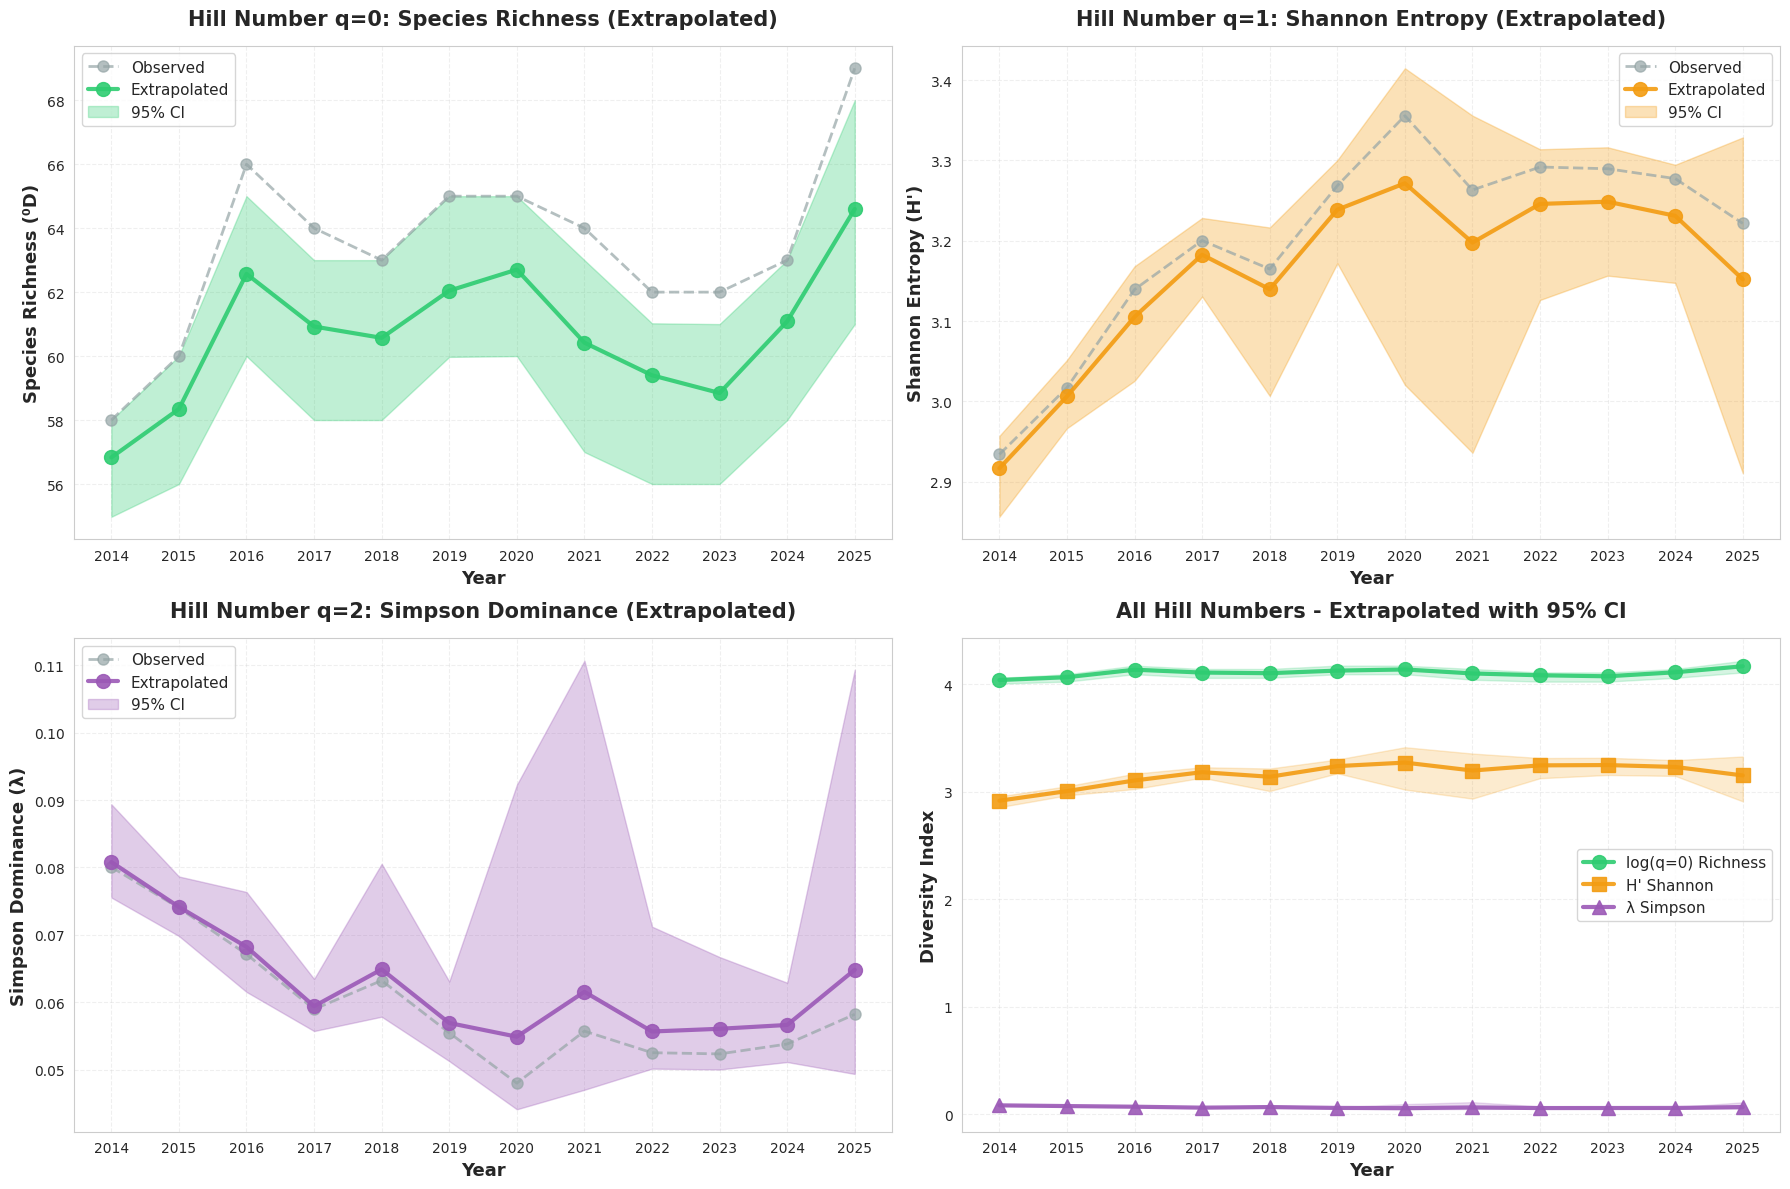


EXTRAPOLATED HILL NUMBERS WITH 95% CONFIDENCE INTERVALS
Year     Sample     q=0 (Richness)            q=1 (H' Shannon)          q=2 (λ Simpson)          
         Size       [95% CI]                  [95% CI]                  [95% CI]                 
------------------------------------------------------------------------------------------------------------------------
2014     5276       56.8 [55.0-58.0]   2.917 [2.856-2.957]   0.0808 [0.0755-0.0894]
2015     7980       58.3 [56.0-60.0]   3.006 [2.967-3.051]   0.0741 [0.0698-0.0787]
2016     10852      62.6 [60.0-65.0]   3.105 [3.026-3.168]   0.0682 [0.0615-0.0764]
2017     9172       60.9 [58.0-63.0]   3.183 [3.131-3.228]   0.0594 [0.0557-0.0635]
2018     9687       60.6 [58.0-63.0]   3.140 [3.007-3.216]   0.0649 [0.0579-0.0805]
2019     9537       62.0 [60.0-65.0]   3.239 [3.172-3.300]   0.0569 [0.0513-0.0631]
2020     10017      62.7 [60.0-65.0]   3.272 [3.021-3.415]   0.0549 [0.0441-0.0923]
2021     10662      60.4 [57.0-63.0]  

In [ ]:
def bootstrap_hill_number(df_year, q, n_bootstrap=1000):
    """Bootstrap confidence intervals for Hill numbers"""
    results = []
    
    for _ in range(n_bootstrap):
        # Resample observations with replacement
        sample_indices = np.random.choice(len(df_year), size=len(df_year), replace=True)
        sample = df_year.iloc[sample_indices]
        counts = sample.groupby('species')['count'].sum()
        results.append(hill_number(counts, q))
    
    # Calculate mean and 95% CI
    mean_val = np.mean(results)
    ci_lower = np.percentile(results, 2.5)
    ci_upper = np.percentile(results, 97.5)
    
    return mean_val, ci_lower, ci_upper


def extrapolate_diversity(df_year, target_size, q, n_bootstrap=100):
    """
    Extrapolate diversity to target sample size using Coleman rarefaction method
    with bootstrap confidence intervals
    """
    current_size = len(df_year)
    
    if target_size <= current_size:
        # Just use regular bootstrap for observed data
        return bootstrap_hill_number(df_year, q, n_bootstrap)
    
    # For extrapolation: resample to larger size and calculate diversity
    results = []
    
    for _ in range(n_bootstrap):
        # Oversample with replacement to reach target size
        sample_indices = np.random.choice(len(df_year), size=target_size, replace=True)
        sample = df_year.iloc[sample_indices]
        counts = sample.groupby('species')['count'].sum()
        results.append(hill_number(counts, q))
    
    mean_val = np.mean(results)
    ci_lower = np.percentile(results, 2.5)
    ci_upper = np.percentile(results, 97.5)
    
    return mean_val, ci_lower, ci_upper


def calculate_hill_with_extrapolation(df, dataset_name="Dataset", n_bootstrap=200):
    """
    Calculate Hill numbers with extrapolation to standardized sample size
    """
    # Find maximum sample size across all years
    year_sizes = df.groupby('year').size()
    max_size = year_sizes.max()
    
    print(f"\n{dataset_name} - Sample sizes per year:")
    print(year_sizes)
    print(f"Extrapolating all years to: {max_size} samples\n")
    
    hill_results = []
    
    for year in sorted(df['year'].unique()):
        df_year = df[df['year'] == year]
        current_size = len(df_year)
        
        # Calculate observed diversity (no extrapolation)
        species_counts = df_year.groupby('species')['count'].sum()
        obs_q0 = hill_number(species_counts, q=0)
        obs_q1 = hill_number(species_counts, q=1)
        obs_q2 = hill_number(species_counts, q=2)
        
        # Extrapolate to max sample size with CI
        q0_mean, q0_lower, q0_upper = extrapolate_diversity(df_year, max_size, q=0, n_bootstrap=n_bootstrap)
        q1_mean, q1_lower, q1_upper = extrapolate_diversity(df_year, max_size, q=1, n_bootstrap=n_bootstrap)
        q2_mean, q2_lower, q2_upper = extrapolate_diversity(df_year, max_size, q=2, n_bootstrap=n_bootstrap)
        
        hill_results.append({
            'year': year,
            'sample_size': current_size,
            # Observed values
            'obs_richness_q0': obs_q0,
            'obs_shannon_q1': np.log(obs_q1),
            'obs_simpson_q2': 1.0 / obs_q2,
            # Extrapolated values
            'ext_richness_q0': q0_mean,
            'ext_shannon_q1': np.log(q1_mean),
            'ext_simpson_q2': 1.0 / q2_mean,
            # Confidence intervals
            'q0_ci_lower': q0_lower,
            'q0_ci_upper': q0_upper,
            'q1_ci_lower': np.log(q1_lower),
            'q1_ci_upper': np.log(q1_upper),
            'q2_ci_lower': 1.0 / q2_upper,  # Note: inverted because of 1/x
            'q2_ci_upper': 1.0 / q2_lower,
            'dataset': dataset_name
        })
    
    return pd.DataFrame(hill_results)


def plot_extrapolated_hill_numbers(df_amplified_bio):
    """
    Plot Hill numbers with extrapolation and confidence intervals
    """
    
    # Calculate extrapolated Hill numbers
    df_hill = calculate_hill_with_extrapolation(df_amplified_bio, "Amplified", n_bootstrap=200)
    
    # Create figure with 4 subplots
    fig = plt.figure(figsize=(18, 12))
    
    years = df_hill['year'].values
    
    # ----------------------------------------------------------------
    # PLOT 1: Species Richness (q=0) - Observed vs Extrapolated
    # ----------------------------------------------------------------
    ax1 = plt.subplot(2, 2, 1)
    
    # Observed
    ax1.plot(years, df_hill['obs_richness_q0'], 
             'o--', color='#95a5a6', linewidth=2, markersize=8,
             label='Observed', alpha=0.7)
    
    # Extrapolated with CI
    ax1.plot(years, df_hill['ext_richness_q0'], 
             'o-', color='#2ecc71', linewidth=3, markersize=10,
             label='Extrapolated', alpha=0.9)
    ax1.fill_between(years, df_hill['q0_ci_lower'], df_hill['q0_ci_upper'],
                     alpha=0.3, color='#2ecc71', label='95% CI')
    
    ax1.set_xlabel('Year', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Species Richness (⁰D)', fontsize=13, fontweight='bold')
    ax1.set_title('Hill Number q=0: Species Richness (Extrapolated)', 
                  fontsize=15, fontweight='bold', pad=15)
    ax1.legend(fontsize=11, loc='best')
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_xticks(years)
    
    # ----------------------------------------------------------------
    # PLOT 2: Shannon Entropy (H') - Observed vs Extrapolated
    # ----------------------------------------------------------------
    ax2 = plt.subplot(2, 2, 2)
    
    # Observed
    ax2.plot(years, df_hill['obs_shannon_q1'], 
             'o--', color='#95a5a6', linewidth=2, markersize=8,
             label='Observed', alpha=0.7)
    
    # Extrapolated with CI
    ax2.plot(years, df_hill['ext_shannon_q1'], 
             'o-', color='#f39c12', linewidth=3, markersize=10,
             label='Extrapolated', alpha=0.9)
    ax2.fill_between(years, df_hill['q1_ci_lower'], df_hill['q1_ci_upper'],
                     alpha=0.3, color='#f39c12', label='95% CI')
    
    ax2.set_xlabel('Year', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Shannon Entropy (H\')', fontsize=13, fontweight='bold')
    ax2.set_title('Hill Number q=1: Shannon Entropy (Extrapolated)', 
                  fontsize=15, fontweight='bold', pad=15)
    ax2.legend(fontsize=11, loc='best')
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.set_xticks(years)
    
    # ----------------------------------------------------------------
    # PLOT 3: Simpson Dominance (λ) - Observed vs Extrapolated
    # ----------------------------------------------------------------
    ax3 = plt.subplot(2, 2, 3)
    
    # Observed
    ax3.plot(years, df_hill['obs_simpson_q2'], 
             'o--', color='#95a5a6', linewidth=2, markersize=8,
             label='Observed', alpha=0.7)
    
    # Extrapolated with CI
    ax3.plot(years, df_hill['ext_simpson_q2'], 
             'o-', color='#9b59b6', linewidth=3, markersize=10,
             label='Extrapolated', alpha=0.9)
    ax3.fill_between(years, df_hill['q2_ci_lower'], df_hill['q2_ci_upper'],
                     alpha=0.3, color='#9b59b6', label='95% CI')
    
    ax3.set_xlabel('Year', fontsize=13, fontweight='bold')
    ax3.set_ylabel('Simpson Dominance (λ)', fontsize=13, fontweight='bold')
    ax3.set_title('Hill Number q=2: Simpson Dominance (Extrapolated)', 
                  fontsize=15, fontweight='bold', pad=15)
    ax3.legend(fontsize=11, loc='best')
    ax3.grid(True, alpha=0.3, linestyle='--')
    ax3.set_xticks(years)
    
    # ----------------------------------------------------------------
    # PLOT 4: All Extrapolated Hill Numbers - log(q=0) vs H' vs λ
    # ----------------------------------------------------------------
    ax4 = plt.subplot(2, 2, 4)
    
    ax4.plot(years, np.log(df_hill['ext_richness_q0']), 
             'o-', color='#2ecc71', linewidth=3, markersize=10,
             label='log(q=0) Richness', alpha=0.9)
    ax4.fill_between(years, np.log(df_hill['q0_ci_lower']), np.log(df_hill['q0_ci_upper']),
                     alpha=0.2, color='#2ecc71')
    
    ax4.plot(years, df_hill['ext_shannon_q1'], 
             's-', color='#f39c12', linewidth=3, markersize=10,
             label='H\' Shannon', alpha=0.9)
    ax4.fill_between(years, df_hill['q1_ci_lower'], df_hill['q1_ci_upper'],
                     alpha=0.2, color='#f39c12')
    
    ax4.plot(years, df_hill['ext_simpson_q2'], 
             '^-', color='#9b59b6', linewidth=3, markersize=10,
             label='λ Simpson', alpha=0.9)
    ax4.fill_between(years, df_hill['q2_ci_lower'], df_hill['q2_ci_upper'],
                     alpha=0.2, color='#9b59b6')
    
    ax4.set_xlabel('Year', fontsize=13, fontweight='bold')
    ax4.set_ylabel('Diversity Index', fontsize=13, fontweight='bold')
    ax4.set_title('All Hill Numbers - Extrapolated with 95% CI', 
                  fontsize=15, fontweight='bold', pad=15)
    ax4.legend(fontsize=11, loc='best')
    ax4.grid(True, alpha=0.3, linestyle='--')
    ax4.set_xticks(years)
    
    plt.tight_layout()
    plt.show()
    
    # ----------------------------------------------------------------
    # Print Summary Table
    # ----------------------------------------------------------------
    print("\n" + "="*120)
    print("EXTRAPOLATED HILL NUMBERS WITH 95% CONFIDENCE INTERVALS")
    print("="*120)
    print(f"{'Year':<8} {'Sample':<10} {'q=0 (Richness)':<25} {'q=1 (H\' Shannon)':<25} {'q=2 (λ Simpson)':<25}")
    print(f"{'':8} {'Size':<10} {'[95% CI]':<25} {'[95% CI]':<25} {'[95% CI]':<25}")
    print("-"*120)
    
    for _, row in df_hill.iterrows():
        print(f"{int(row['year']):<8} {int(row['sample_size']):<10} "
              f"{row['ext_richness_q0']:.1f} [{row['q0_ci_lower']:.1f}-{row['q0_ci_upper']:.1f}]   "
              f"{row['ext_shannon_q1']:.3f} [{row['q1_ci_lower']:.3f}-{row['q1_ci_upper']:.3f}]   "
              f"{row['ext_simpson_q2']:.4f} [{row['q2_ci_lower']:.4f}-{row['q2_ci_upper']:.4f}]")
    
    return df_hill


# Usage:
# ---------------------------------------------------------------------
df_hill_extrapolated = plot_extrapolated_hill_numbers(df_amplified_bio)

#### Interpretation

1. All years have been extrapolated to the same sample size for a fair and direct comparison of diversity metrics.

2. The Species Richness ($\mathbf{q=0}$) of observations before extrapolation is situated outside the confidence interval, which shows that the difference is statistically significant for this indicator.

Other diversity indicators also show relatively significant differences, especially in the year 2020.

3. The confidence intervals being extremely small in the last plot allows us to state that the fraction $\mathbf{H'/\ln(S)}$ (where $S$ is the number of observed species) is very close to 1 in 95% of cases.

This demonstrates that the real distribution of birds is actually very diverse and rich in terms of species richness and evenness.


######################################################################
# PART 1: NORMALITY TESTS FOR HILL NUMBERS
######################################################################

NORMALITY TESTS: Species Richness (q=0)

1. Shapiro-Wilk Test:
   Statistic: 0.9852
   p-value: 0.9968
   Result: NORMAL (α=0.05)

2. D'Agostino-Pearson Test:
   Statistic: 0.1518
   p-value: 0.9269
   Result: NORMAL (α=0.05)

3. Anderson-Darling Test:
   Statistic: 0.1578
   Critical values: [0.497 0.566 0.679 0.792 0.942]
   Significance levels: [15.  10.   5.   2.5  1. ]
   Result at 5%: NORMAL

4. Descriptive Statistics:
   Mean: 60.6708
   Std: 2.1450
   Skewness: 0.0687
   Kurtosis: -0.3475


NORMALITY TESTS: Shannon Entropy (q=1, H')

1. Shapiro-Wilk Test:
   Statistic: 0.8696
   p-value: 0.0647
   Result: NORMAL (α=0.05)

2. D'Agostino-Pearson Test:
   Statistic: 5.3345
   p-value: 0.0694
   Result: NORMAL (α=0.05)

3. Anderson-Darling Test:
   Statistic: 0.6420
   Critical values: [0.497 0.566

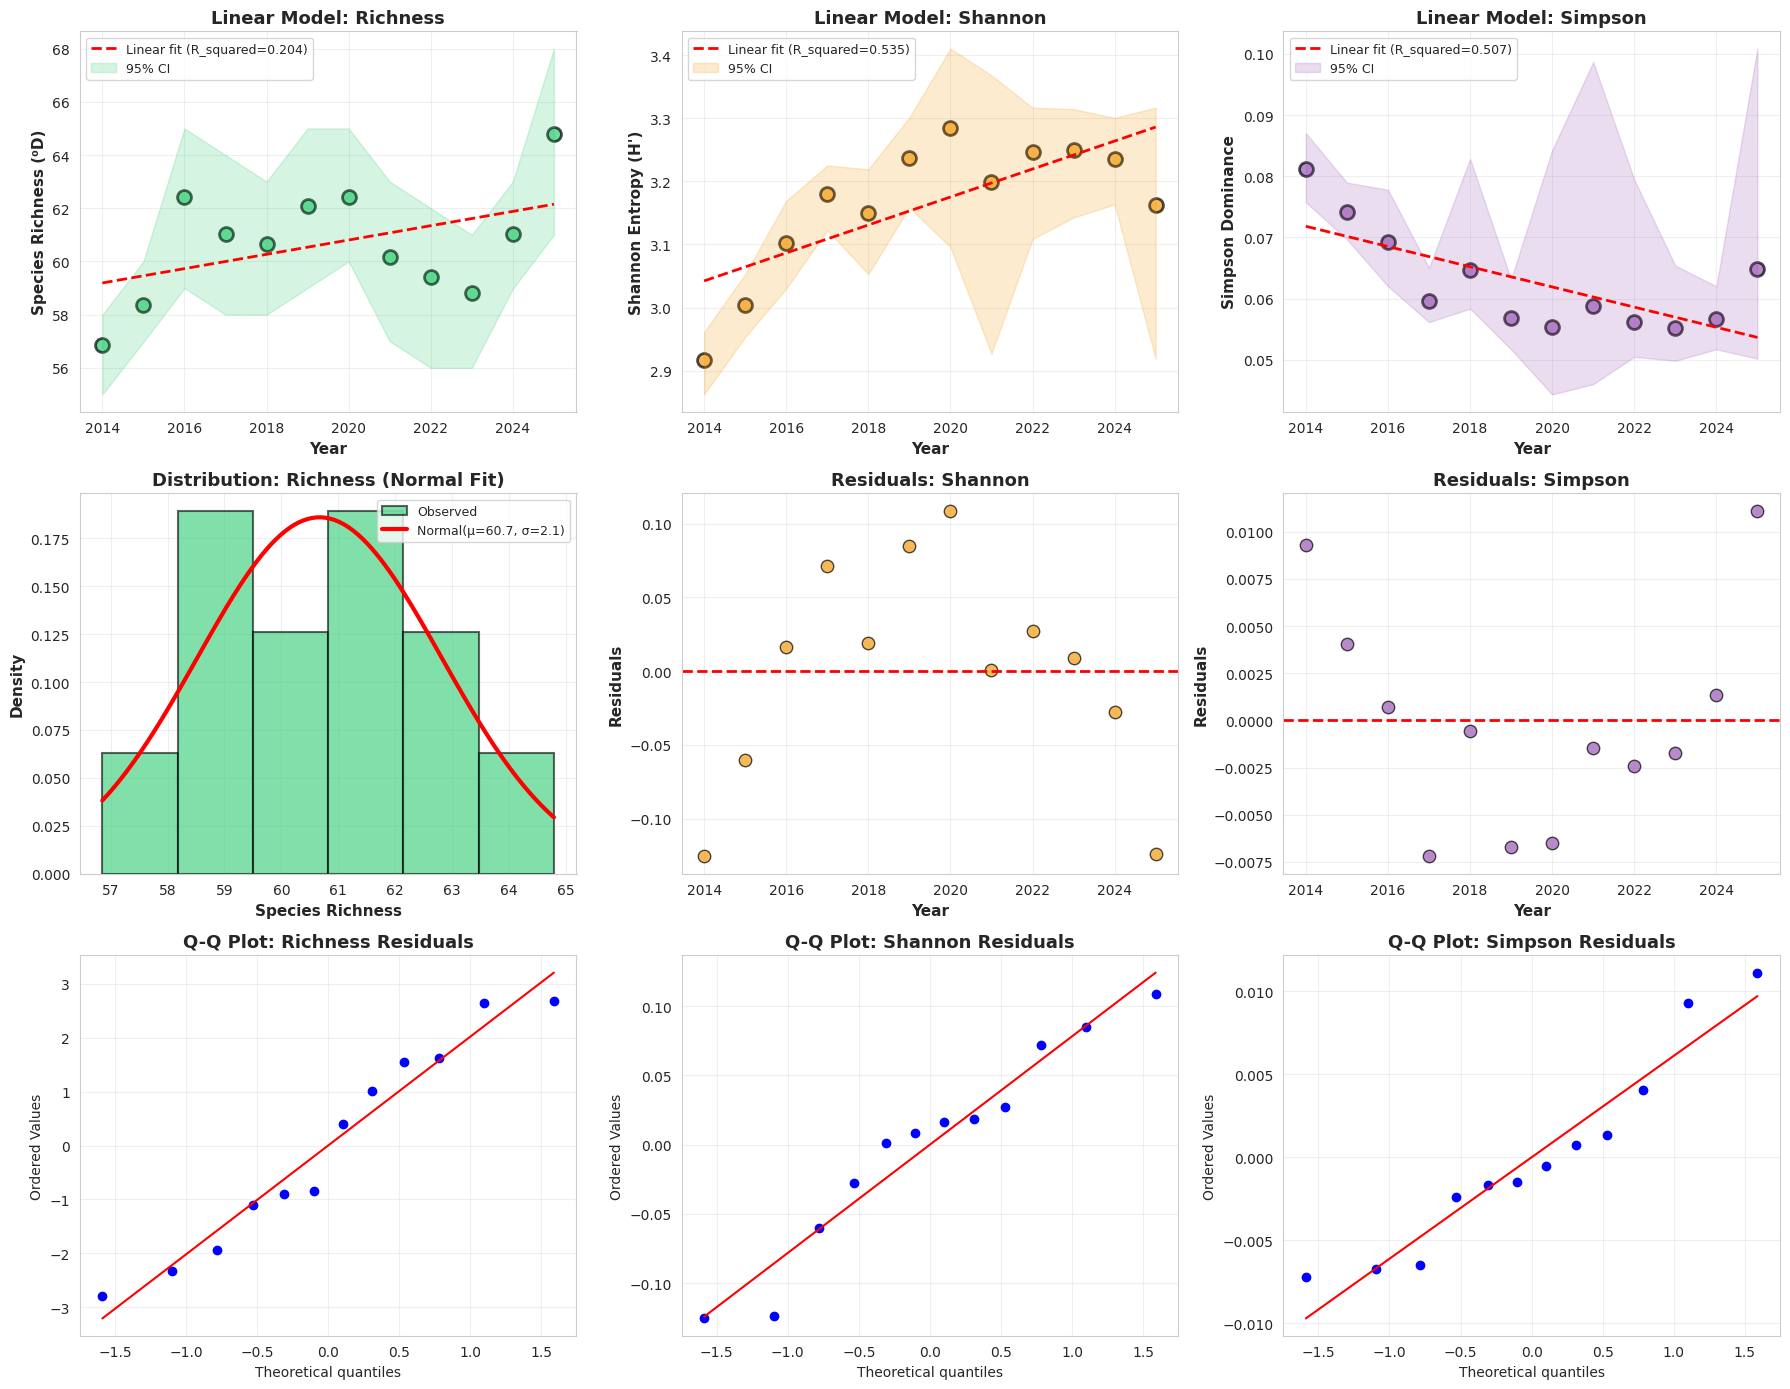


SUMMARY: MODEL VALIDITY
Indicator                 Linear Trend    p-value      R_squared  Residuals Normal?   
------------------------------------------------------------------------------------------
Species Richness (q=0)    Increasing      0.1400       0.204      YES                 
Shannon Entropy (H')      Increasing      0.0069       0.535      YES                 
Simpson Dominance         Decreasing      0.0094       0.507      YES                 


In [ ]:
# ---------------------------------------------------------------------
# Linear Models and Normality Tests for Hill Numbers
# ---------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import shapiro, normaltest, anderson

def test_normality(data, name="Data"):
    """
    Perform multiple normality tests on data
    """
    print(f"\n{'='*70}")
    print(f"NORMALITY TESTS: {name}")
    print(f"{'='*70}")
    
    # 1. Shapiro-Wilk Test
    shapiro_stat, shapiro_p = shapiro(data)
    print(f"\n1. Shapiro-Wilk Test:")
    print(f"   Statistic: {shapiro_stat:.4f}")
    print(f"   p-value: {shapiro_p:.4f}")
    print(f"   Result: {'NORMAL' if shapiro_p > 0.05 else 'NOT NORMAL'} (α=0.05)")
    
    # 2. D'Agostino-Pearson Test
    dagostino_stat, dagostino_p = normaltest(data)
    print(f"\n2. D'Agostino-Pearson Test:")
    print(f"   Statistic: {dagostino_stat:.4f}")
    print(f"   p-value: {dagostino_p:.4f}")
    print(f"   Result: {'NORMAL' if dagostino_p > 0.05 else 'NOT NORMAL'} (α=0.05)")
    
    # 3. Anderson-Darling Test
    anderson_result = anderson(data)
    print(f"\n3. Anderson-Darling Test:")
    print(f"   Statistic: {anderson_result.statistic:.4f}")
    print(f"   Critical values: {anderson_result.critical_values}")
    print(f"   Significance levels: {anderson_result.significance_level}")
    
    # Check at 5% level (index 2)
    is_normal_anderson = anderson_result.statistic < anderson_result.critical_values[2]
    print(f"   Result at 5%: {'NORMAL' if is_normal_anderson else 'NOT NORMAL'}")
    
    # 4. Basic statistics
    print(f"\n4. Descriptive Statistics:")
    print(f"   Mean: {np.mean(data):.4f}")
    print(f"   Std: {np.std(data, ddof=1):.4f}")
    print(f"   Skewness: {stats.skew(data):.4f}")
    print(f"   Kurtosis: {stats.kurtosis(data):.4f}")
    
    print(f"{'='*70}\n")
    
    return {
        'shapiro_p': shapiro_p,
        'dagostino_p': dagostino_p,
        'anderson_stat': anderson_result.statistic,
        'anderson_critical_5pct': anderson_result.critical_values[2],
        'is_normal': shapiro_p > 0.05 and dagostino_p > 0.05
    }


def fit_linear_model(years, values, name="Indicator"):
    """
    Fit linear regression and return statistics
    """
    # Convert years to numeric (years since first year)
    years_numeric = years - years.min()
    
    # Fit linear model: y = a + b*x
    slope, intercept, r_value, p_value, std_err = stats.linregress(years_numeric, values)
    
    # Predictions
    predictions = intercept + slope * years_numeric
    residuals = values - predictions
    
    # R-squared
    r_squared = r_value ** 2
    
    # Test residuals for normality
    residual_normality = test_normality(residuals, f"{name} - Residuals")
    
    print(f"\n{'='*70}")
    print(f"LINEAR MODEL: {name}")
    print(f"{'='*70}")
    print(f"\nModel: y = {intercept:.4f} + {slope:.4f} * (year - {years.min()})")
    print(f"\nCoefficients:")
    print(f"   Intercept: {intercept:.4f}")
    print(f"   Slope: {slope:.4f} ± {std_err:.4f}")
    print(f"\nModel Performance:")
    print(f"   R_square: {r_squared:.4f}")
    print(f"   p-value: {p_value:.4f}")
    print(f"   Significance: {'SIGNIFICANT' if p_value < 0.05 else 'NOT SIGNIFICANT'} (α=0.05)")
    print(f"\nTrend: {'INCREASING' if slope > 0 else 'DECREASING'} over time")
    print(f"{'='*70}\n")
    
    return {
        'slope': slope,
        'intercept': intercept,
        'r_squared': r_squared,
        'p_value': p_value,
        'std_err': std_err,
        'predictions': predictions,
        'residuals': residuals,
        'residual_normal': residual_normality['is_normal']
    }


def analyze_hill_numbers_with_models(df_hill):
    """
    Complete analysis: normality tests + linear models for Hill numbers
    """
    
    years = df_hill['year'].values
    
    # Extract extrapolated values
    q0 = df_hill['ext_richness_q0'].values
    q1 = df_hill['ext_shannon_q1'].values
    q2 = df_hill['ext_simpson_q2'].values
    
    print("\n" + "#"*70)
    print("# PART 1: NORMALITY TESTS FOR HILL NUMBERS")
    print("#"*70)
    
    # Test normality of each indicator
    q0_normality = test_normality(q0, "Species Richness (q=0)")
    q1_normality = test_normality(q1, "Shannon Entropy (q=1, H')")
    q2_normality = test_normality(q2, "Simpson Dominance (q=2, λ)")
    
    print("\n" + "#"*70)
    print("# PART 2: LINEAR REGRESSION MODELS")
    print("#"*70)
    
    # Fit linear models
    q0_model = fit_linear_model(years, q0, "Species Richness (q=0)")
    q1_model = fit_linear_model(years, q1, "Shannon Entropy (q=1, H')")
    q2_model = fit_linear_model(years, q2, "Simpson Dominance (q=2, λ)")
    
    # Create visualizations
    fig = plt.figure(figsize=(18, 14))
    
    # ----------------------------------------------------------------
    # ROW 1: Linear Models with Confidence Intervals
    # ----------------------------------------------------------------
    
    # Plot 1: Richness
    ax1 = plt.subplot(3, 3, 1)
    ax1.scatter(years, q0, s=100, color='#2ecc71', alpha=0.7, edgecolors='black', linewidths=2)
    ax1.plot(years, q0_model['predictions'], 'r--', linewidth=2, label=f'Linear fit (R_squared={q0_model["r_squared"]:.3f})')
    ax1.fill_between(years, df_hill['q0_ci_lower'], df_hill['q0_ci_upper'],
                     alpha=0.2, color='#2ecc71', label='95% CI')
    ax1.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Species Richness (⁰D)', fontsize=11, fontweight='bold')
    ax1.set_title('Linear Model: Richness', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Shannon
    ax2 = plt.subplot(3, 3, 2)
    ax2.scatter(years, q1, s=100, color='#f39c12', alpha=0.7, edgecolors='black', linewidths=2)
    ax2.plot(years, q1_model['predictions'], 'r--', linewidth=2, label=f'Linear fit (R_squared={q1_model["r_squared"]:.3f})')
    ax2.fill_between(years, df_hill['q1_ci_lower'], df_hill['q1_ci_upper'],
                     alpha=0.2, color='#f39c12', label='95% CI')
    ax2.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Shannon Entropy (H\')', fontsize=11, fontweight='bold')
    ax2.set_title('Linear Model: Shannon', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Simpson
    ax3 = plt.subplot(3, 3, 3)
    ax3.scatter(years, q2, s=100, color='#9b59b6', alpha=0.7, edgecolors='black', linewidths=2)
    ax3.plot(years, q2_model['predictions'], 'r--', linewidth=2, label=f'Linear fit (R_squared={q2_model["r_squared"]:.3f})')
    ax3.fill_between(years, df_hill['q2_ci_lower'], df_hill['q2_ci_upper'],
                     alpha=0.2, color='#9b59b6', label='95% CI')
    ax3.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Simpson Dominance', fontsize=11, fontweight='bold')
    ax3.set_title('Linear Model: Simpson', fontsize=13, fontweight='bold')
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3)
    
    # ----------------------------------------------------------------
    # ROW 2: Distribution/Residuals Plots
    # ----------------------------------------------------------------
    
    # Plot 4: Richness Distribution (Normal fit)
    ax4 = plt.subplot(3, 3, 4)
    
    # Histogram
    n, bins, patches = ax4.hist(q0, bins=6, density=True, alpha=0.6, color='#2ecc71', 
                                edgecolor='black', linewidth=1.5, label='Observed')
    
    # Fit normal distribution
    mu, sigma = np.mean(q0), np.std(q0, ddof=1)
    x_norm = np.linspace(q0.min(), q0.max(), 100)
    ax4.plot(x_norm, stats.norm.pdf(x_norm, mu, sigma), 'r-', linewidth=3, 
             label=f'Normal(μ={mu:.1f}, σ={sigma:.1f})')
    
    ax4.set_xlabel('Species Richness', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Density', fontsize=11, fontweight='bold')
    ax4.set_title('Distribution: Richness (Normal Fit)', fontsize=13, fontweight='bold')
    ax4.legend(fontsize=9)
    ax4.grid(True, alpha=0.3)
    
    # Plot 5: Shannon Residuals
    ax5 = plt.subplot(3, 3, 5)
    ax5.scatter(years, q1_model['residuals'], s=80, color='#f39c12', alpha=0.7, edgecolors='black')
    ax5.axhline(y=0, color='r', linestyle='--', linewidth=2)
    ax5.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax5.set_ylabel('Residuals', fontsize=11, fontweight='bold')
    ax5.set_title('Residuals: Shannon', fontsize=13, fontweight='bold')
    ax5.grid(True, alpha=0.3)
    
    # Plot 6: Simpson Residuals
    ax6 = plt.subplot(3, 3, 6)
    ax6.scatter(years, q2_model['residuals'], s=80, color='#9b59b6', alpha=0.7, edgecolors='black')
    ax6.axhline(y=0, color='r', linestyle='--', linewidth=2)
    ax6.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax6.set_ylabel('Residuals', fontsize=11, fontweight='bold')
    ax6.set_title('Residuals: Simpson', fontsize=13, fontweight='bold')
    ax6.grid(True, alpha=0.3)
    
    # ----------------------------------------------------------------
    # ROW 3: Q-Q Plots (Normality Check)
    # ----------------------------------------------------------------
    
    # Plot 7: Richness Q-Q
    ax7 = plt.subplot(3, 3, 7)
    stats.probplot(q0_model['residuals'], dist="norm", plot=ax7)
    ax7.set_title('Q-Q Plot: Richness Residuals', fontsize=13, fontweight='bold')
    ax7.grid(True, alpha=0.3)
    
    # Plot 8: Shannon Q-Q
    ax8 = plt.subplot(3, 3, 8)
    stats.probplot(q1_model['residuals'], dist="norm", plot=ax8)
    ax8.set_title('Q-Q Plot: Shannon Residuals', fontsize=13, fontweight='bold')
    ax8.grid(True, alpha=0.3)
    
    # Plot 9: Simpson Q-Q
    ax9 = plt.subplot(3, 3, 9)
    stats.probplot(q2_model['residuals'], dist="norm", plot=ax9)
    ax9.set_title('Q-Q Plot: Simpson Residuals', fontsize=13, fontweight='bold')
    ax9.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary table
    print("\n" + "="*90)
    print("SUMMARY: MODEL VALIDITY")
    print("="*90)
    print(f"{'Indicator':<25} {'Linear Trend':<15} {'p-value':<12} {'R_squared':<10} {'Residuals Normal?':<20}")
    print("-"*90)
    
    print(f"{'Species Richness (q=0)':<25} {'Increasing' if q0_model['slope'] > 0 else 'Decreasing':<15} "
          f"{q0_model['p_value']:<12.4f} {q0_model['r_squared']:<10.3f} "
          f"{'YES' if q0_model['residual_normal'] else 'NO':<20}")
    
    print(f"{'Shannon Entropy (H\')':<25} {'Increasing' if q1_model['slope'] > 0 else 'Decreasing':<15} "
          f"{q1_model['p_value']:<12.4f} {q1_model['r_squared']:<10.3f} "
          f"{'YES' if q1_model['residual_normal'] else 'NO':<20}")
    
    print(f"{'Simpson Dominance':<25} {'Increasing' if q2_model['slope'] > 0 else 'Decreasing':<15} "
          f"{q2_model['p_value']:<12.4f} {q2_model['r_squared']:<10.3f} "
          f"{'YES' if q2_model['residual_normal'] else 'NO':<20}")

    
    return {
        'q0_model': q0_model,
        'q1_model': q1_model,
        'q2_model': q2_model,
        'q0_normality': q0_normality,
        'q1_normality': q1_normality,
        'q2_normality': q2_normality
    }


# Usage (after running plot_extrapolated_hill_numbers):
# ---------------------------------------------------------------------
results = analyze_hill_numbers_with_models(df_hill_extrapolated)

#### Interpretation
- **Species Richness (q=0)**
  - not linear since it's linear model corresponding p_value is extremly low.
  - But the distribution of estimated indictors per year follows a normal distribution with mean=60.67 and std=2.14. 

- **Shannon Entropy (H')** and **Simpson Dominance**
    - show an extrem linear correlation with time, since the p-values of the linear model fitting is significantly high.
    - The residuals of these indicators are normally distributed (u=0), which means that most of the values are null, hence, the predictions are in correlation with years (linear correlation).

#### Conclusion
**Diversity is significantly increasing over the study period**,
1. Greater evenness (high Shannon).
2. Reduced dominance (low Simpson).

This suggests ecosystem is moving toward more balanced species distribution.

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

3

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# 4. Synthesis and Recommendations

## 4.1 Main Insights

### Programme de monitoring

Le programme présente une **couverture temporelle robuste (2012-2025)** mais révèle des **biais d'échantillonnage significatifs** :

- **Effort croissant** : augmentation progressive du nombre d'observations au fil des années
- **Saisonnalité marquée** : concentration des relevés pendant la période de reproduction
- **Hétérogénéité spatiale** : effort variable entre transects et départements

Ces biais doivent être systématiquement pris en compte lors de l'interprétation des résultats.

---

## 4.2 Convergence et Contradictions

### Tendances au niveau communautaire

Les indicateurs de biodiversité révèlent des **signaux cohérents mais nuancés** :

#### Richesse spécifique et Hill numbers
- **Aucune tendance linéaire significative** (p > 0.05)
- Stabilité apparente de la diversité globale
- Cependant, cette stabilité masque potentiellement des changements au niveau des espèces

#### Rarity-Weighted Richness (RWR)
- **Pattern non-linéaire robuste en forme de U** (p < 0.005 pour tous les k testés)
- **Breakpoint détecté en 2022** : minimum de diversité pondérée par la rareté
- Déclin jusqu'en 2022, puis récupération partielle
- **Signal convergent** : robuste quel que soit le paramètre de pondération k

#### Composite Biodiversity Index (CBI)
- Reflète principalement la composante RWR
- Confirme la dynamique en U observée

**Interprétation** : La communauté d'oiseaux semble avoir traversé une **phase de stress écologique** culminant en 2022, suivie d'une récupération. Cette dynamique touche particulièrement les espèces rares, tandis que la richesse totale reste stable (possiblement grâce au maintien des espèces généralistes).

---

### Tendances au niveau spécifique

L'analyse des espèces individuelles confirme une **divergence des trajectoires** :

#### Espèces en augmentation significative
- **Sucrier à ventre jaune** : +60.60 ind/an (p=0.0217)
- **Élénie siffleuse** : +81.26 ind/an (p=0.0058)
- **Merle à lunettes** : +55.04 ind/an (p=0.0281)

Profil commun : espèces **généralistes**, **plastiques écologiquement**, capables d'exploiter les environnements anthropisés.

#### Espèces en déclin non-significatif
- **Grive à pieds jaunes** : -19.99 ind/an (p=0.2169)
- **Colibri falle-vert** : -5.11 ind/an (p=0.4865)
- **Sporophile cici** : -20.00 ind/an (p=0.1447)

Bien que non-significatifs statistiquement, ces déclins méritent une **surveillance accrue**, particulièrement pour les espèces endémiques ou à distribution restreinte.

**Contradiction apparente** : La stabilité de la richesse totale coexiste avec des changements au niveau des espèces. Ce phénomène s'explique par un **turnover de composition** : certaines espèces augmentent tandis que d'autres déclinent, maintenant le nombre total d'espèces relativement constant.

---

## 4.3 Actionable Recommendations

### Amélioration de la collecte de données

1. **Standardisation de l'effort** :
   - Établir un protocole fixe du nombre de visites par transect et par an
   - Équilibrer l'effort entre départements pour éviter les biais géographiques
   - Documenter systématiquement les raisons des visites manquantes

2. **Extension temporelle** :
   - Élargir la fenêtre de monitoring au-delà de la saison de reproduction
   - Permettrait de capturer les espèces migratrices et hivernantes
   - Améliorerait la détection des espèces discrètes hors période de reproduction

3. **Métadonnées enrichies** :
   - Enregistrer systématiquement les conditions météo (actuellement incomplet)
   - Ajouter des descripteurs d'habitat au niveau du point (pas seulement du transect)
   - Documenter l'expérience de l'observateur (potentiel biais de détection)

### Indicateurs additionnels

1. **Indices fonctionnels** :
   - Diversité des guildes trophiques (nectarivores, insectivores, granivores)
   - Diversité de masse corporelle
   - → Permettrait d'évaluer la résilience fonctionnelle de la communauté

2. **Métriques de turnover** :
   - Taux de colonisation et d'extinction entre années consécutives
   - Beta-diversité temporelle
   - → Quantifierait directement les changements de composition

3. **Indicateurs de synchronie** :
   - Corrélation des dynamiques entre espèces
   - → Détecterait les réponses coordonnées à des stresseurs environnementaux

### Questions de suivi prioritaires

1. **Validation du breakpoint 2022** :
   - Investiguer les événements écologiques ou climatiques de 2021-2022
   - Vérifier si d'autres taxons montrent un pattern similaire
   - Rechercher des données météorologiques ou d'occupation du sol pour cette période

2. **Monitoring ciblé des espèces en déclin** :
   - Protocole dédié pour Grive à pieds jaunes et Sporophile cici
   - Recherche de leurs habitats préférentiels
   - Évaluation des menaces spécifiques (prédation, compétition, perte d'habitat)

3. **Étude des causes d'homogénéisation biotique** :
   - Cartographier l'expansion des habitats anthropisés
   - Corréler les augmentations d'espèces généralistes avec l'urbanisation
   - Identifier les refuges pour espèces spécialistes

---

## 4.4 Limitations

### Qualité des données

- **Données météo incomplètes** : ~30% de valeurs manquantes limite l'analyse des effets climatiques
- **Nomenclature taxonomique** : quelques incohérences entre noms français et scientifiques
- **Effort hétérogène** : malgré le bootstrap, l'inégalité d'échantillonnage affecte la précision des tendances

### Modélisation

- **Hypothèse de linéarité** : les régressions linéaires au niveau des espèces peuvent manquer des dynamiques complexes (comme le U observé pour le RWR)
- **Indépendance temporelle** : les observations consécutives ne sont pas réellement indépendantes (autocorrélation temporelle non modélisée)
- **Pseudo-réplication spatiale** : les points d'un même transect ne sont pas indépendants

### Interprétation écologique

- **Corrélation ≠ causalité** : les explications proposées (urbanisation, plasticité) sont plausibles mais non démontrées avec ces données
- **Détectabilité** : les déclins observés peuvent refléter une baisse de détection plutôt qu'une vraie diminution d'abondance
- **Échelle spatiale** : Martinique est une petite île — les patterns observés peuvent différer d'autres contextes caribéens

---

## 4.5 Conclusion

Le programme de monitoring révèle une **communauté d'oiseaux en transformation** :

- **Stabilité apparente** de la richesse globale
- **Stress écologique détecté** pour les espèces rares (minimum en 2022)
- **Turnover de composition** avec émergence d'espèces généralistes

Les données démontrent la valeur d'un **monitoring de long terme** pour détecter des signaux subtils inaccessibles aux études ponctuelles. La récupération post-2022 suggère une **résilience partielle** de la communauté, mais nécessite confirmation avec les données futures.

**Priorité d'action** : surveillance renforcée des espèces en déclin et investigation du point de rupture 2022 pour comprendre les facteurs de stress et de récupération.
